In [ ]:
# ==========================================
# 0. MOUNT GOOGLE DRIVE
# ==========================================
from google.colab import drive
import os

print("Mounting Google Drive...")
drive.mount('/content/drive')

Mounting Google Drive...
Mounted at /content/drive


## PIPELINE 1

In [ ]:
# ========================================================
# 1. IMPORTS & CONFIGURATION
# ========================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import vgg19, VGG19_Weights # Diubah ke VGG19
from torchvision import transforms
from datasets import load_dataset
import numpy as np
import random

# --- Konfigurasi Environment ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

# --- Konfigurasi Model & Data ---
MODEL_PATH = "/content/drive/MyDrive//Eksperimen_Alzheimer_VGG19/best_vgg19_aug_sampler_full_tuning_adamw_reduce_lr.pth"
TARGET_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
NUM_CLASSES = len(TARGET_NAMES)
SAMPLES_PER_CLASS = 15
CONFIDENCE_THRESHOLD = 0.8

# Set Seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ========================================================
# 2. MODEL INITIALIZATION
# ========================================================
print(f"[*] Inisialisasi model di device: {DEVICE}")

# Load VGG19 Base
model = vgg19(weights=VGG19_Weights.DEFAULT)

# ⚠️ Modifikasi classifier sesuai dengan arsitektur saat training
# Checkpoint menunjukkan classifier.3 diubah menjadi output 1024
model.classifier[3] = nn.Linear(4096, 1024)

# Checkpoint menunjukkan classifier.6 menerima 1024 dan output ke NUM_CLASSES (4)
model.classifier[6] = nn.Linear(1024, NUM_CLASSES)

# Load Weights
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

# Matikan inplace dengan cara Pythonic & efisien
for module in model.modules():
    if hasattr(module, 'inplace'):
        module.inplace = False

model = model.to(DEVICE)
model.eval()
# ========================================================
# 3. DATA PREPARATION
# ========================================================
print("[*] Mempersiapkan dataset...")
dataset = load_dataset("Falah/Alzheimer_MRI")
test_data = dataset["test"]

class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, item["label"]

transform = transforms.Compose([
    transforms.Resize((224, 224)), # VGG19 sangat bergantung pada ukuran 224x224
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset_obj = AlzheimerDataset(test_data, transform)

def unnormalize(img_tensor):
    mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
    img = img_tensor.permute(1, 2, 0).detach().cpu().numpy()
    img = std * img + mean
    return np.clip(img, 0, 1)

print(f"Total data test yang siap dievaluasi: {len(dataset_obj)} gambar")

# ========================================================
# 4. PIPELINE 1: STRATIFIED CONFIDENCE SAMPLING
# ========================================================
print("\n[*] Tahap 1: Melakukan inferensi pada seluruh data test...")
test_loader = DataLoader(dataset_obj, batch_size=32, shuffle=False)
all_preds, all_labels, all_probs, all_indices = [], [], [], []

with torch.no_grad():
    for i, (imgs, labels) in enumerate(test_loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        probs = F.softmax(outputs, dim=1)
        max_probs, preds = torch.max(probs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(max_probs.cpu().numpy())

        start_idx = i * 32
        all_indices.extend(list(range(start_idx, start_idx + len(labels))))

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_indices = np.array(all_indices)

# Proses Sampling 4 Kuadran
fixed_indices_dict = {name: [] for name in TARGET_NAMES}
explanation_log = []

print("[*] Tahap 2: Menganalisis kuadran dan memilih sampel...")
for c_idx, c_name in enumerate(TARGET_NAMES):
    class_mask = (all_labels == c_idx)
    class_indices = all_indices[class_mask]

    explanation_log.append(f"\n--- KELAS: {c_name} ---")

    # Ambil semua jika data minoritas (Misal Kelas ModerateDemented)
    if len(class_indices) <= SAMPLES_PER_CLASS:
        for idx in class_indices:
            pred_stat = "BENAR" if all_preds[idx] == all_labels[idx] else f"SALAH (Tebak: {TARGET_NAMES[all_preds[idx]]})"
            explanation_log.append(f"Index {idx:4d} | {pred_stat:25} | Prob: {all_probs[idx]:.4f} | (Otomatis diambil semua)")
            fixed_indices_dict[c_name].append(int(idx))
        continue

    # Pembagian 4 Kuadran
    correct_mask = (all_preds[class_indices] == all_labels[class_indices])
    incorrect_mask = ~correct_mask
    high_conf = (all_probs[class_indices] > CONFIDENCE_THRESHOLD)
    low_conf = ~high_conf

    # Assign ke masing-masing kuadran dan acak
    quadrants = [
        (list(class_indices[correct_mask & high_conf]), "High-Conf Correct"),
        (list(class_indices[correct_mask & low_conf]), "Low-Conf Correct"),
        (list(class_indices[incorrect_mask & high_conf]), "High-Conf Incorrect"),
        (list(class_indices[incorrect_mask & low_conf]), "Low-Conf Incorrect")
    ]
    for q_list, _ in quadrants:
        random.shuffle(q_list)

    # Round-robin sampling
    selected = []
    while len(selected) < SAMPLES_PER_CLASS and any(len(q[0]) > 0 for q in quadrants):
        for q_list, q_name in quadrants:
            if len(selected) >= SAMPLES_PER_CLASS: break
            if len(q_list) > 0:
                idx = q_list.pop(0)
                selected.append((idx, q_name))
                fixed_indices_dict[c_name].append(int(idx))

    # Logging hasil sampel kelas ini
    for idx, q_name in selected:
        pred_stat = "BENAR" if all_preds[idx] == all_labels[idx] else f"SALAH (Tebak: {TARGET_NAMES[all_preds[idx]]})"
        explanation_log.append(f"Index {idx:4d} | {pred_stat:25} | Prob: {all_probs[idx]:.4f} | Kuadran: {q_name}")

print("\n=== LOG PENJELASAN SAMPEL ===")
for line in explanation_log:
    print(line)

print("\n\n=== ⬇️ COPY DICTIONARY INI KE PIPELINE 2 ⬇️ ===")
print("fixed_indices_dict = {")
for i, (cls, indices) in enumerate(fixed_indices_dict.items()):
    comma = "," if i < len(fixed_indices_dict) - 1 else ""
    print(f'    "{cls}": {indices}{comma}')
print("}")

[*] Inisialisasi model di device: cuda
[*] Mempersiapkan dataset...


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…): reconstructing file:   0%|          |  0.00B / 22.6MB            

data/train-00000-of-00001-c08a401c53fe53(…): downloading bytes:           |  0.00B            

data/test-00000-of-00001-44110b9df98c558(…): reconstructing file:   0%|          |  0.00B / 5.65MB            

data/test-00000-of-00001-44110b9df98c558(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

Total data test yang siap dievaluasi: 1280 gambar

[*] Tahap 1: Melakukan inferensi pada seluruh data test...
[*] Tahap 2: Menganalisis kuadran dan memilih sampel...

=== LOG PENJELASAN SAMPEL ===

--- KELAS: MildDemented ---
Index  127 | BENAR                     | Prob: 1.0000 | Kuadran: High-Conf Correct
Index  406 | SALAH (Tebak: VeryMildDemented) | Prob: 0.9048 | Kuadran: High-Conf Incorrect
Index  711 | SALAH (Tebak: VeryMildDemented) | Prob: 0.5600 | Kuadran: Low-Conf Incorrect
Index  604 | BENAR                     | Prob: 0.9989 | Kuadran: High-Conf Correct
Index  460 | SALAH (Tebak: VeryMildDemented) | Prob: 0.9783 | Kuadran: High-Conf Incorrect
Index  709 | BENAR                     | Prob: 1.0000 | Kuadran: High-Conf Correct
Index  124 | SALAH (Tebak: VeryMildDemented) | Prob: 0.9875 | Kuadran: High-Conf Incorrect
Index  366 | BENAR                     | Prob: 1.0000 | Kuadran: High-Conf Correct
Index   59 | SALAH (Tebak: VeryMildDemented) | Prob: 0.9081 | Kuadran: High-Con

## ini nyari treshold

[*] Inisialisasi model di device: cuda
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:06<00:00, 93.9MB/s]


[*] Mempersiapkan dataset...


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…): reconstructing file:   0%|          |  0.00B / 22.6MB            

...

data/test-00000-of-00001-44110b9df98c558(…): reconstructing file:   0%|          |  0.00B / 5.65MB            

data/test-00000-of-00001-44110b9df98c558(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

Total data test yang siap dievaluasi: 1280 gambar

[*] Tahap 1: Melakukan inferensi pada seluruh data test...

[*] Tahap 2: Menganalisis Distribusi Confidence dan Mencari Threshold...
--> Threshold hasil Otsu: 0.8216
--> Threshold hasil KMeans: 0.8282
[*] MENGGUNAKAN THRESHOLD: 0.8216 untuk pembagian kuadran.
[*] Grafik histogram telah disimpan sebagai 'histogram_confidence_vgg19.png'

[*] Tahap 3: Memilih sampel berdasarkan 4 Kuadran...

=== LOG PENJELASAN SAMPEL ===

--- KELAS: MildDemented ---
Index  127 | BENAR                     | Prob: 1.0000 | Kuadran: High-Conf Correct
Index  406 | SALAH (Tebak: VeryMildDemented) | Prob: 0.9048 | Kuadran: High-Conf Incorrect
Index  711 | SALAH (Tebak: VeryMildDemented) | Prob: 0.5600 | Kuadran: Low-Conf Incorrect
Index  604 | BENAR                     | Prob: 0.9989 | Kuadran: High-Conf Correct
Index  460 | SALAH (Tebak: VeryMildDemented) | Prob: 0.9783 | Kuadran: High-Conf Incorrect
Index  709 | BENAR                     | Prob: 1.0000 | Kuad

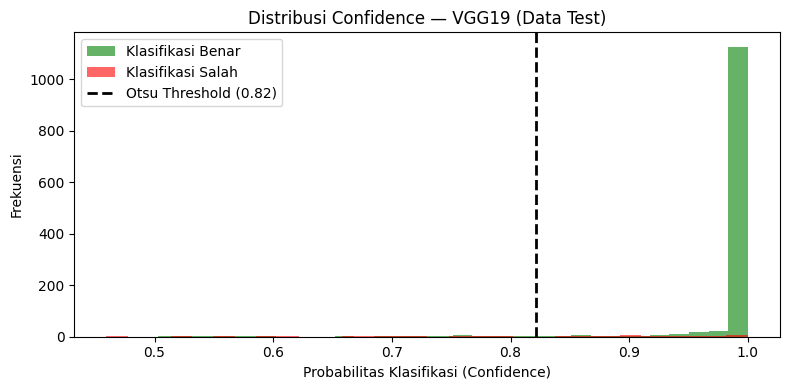

In [ ]:
# ========================================================
# 1. IMPORTS & CONFIGURATION
# ========================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import vgg19, VGG19_Weights
from torchvision import transforms
from datasets import load_dataset
import numpy as np
import random
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from sklearn.cluster import KMeans

# --- Konfigurasi Environment ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

# --- Konfigurasi Model & Data ---
# Ganti path ini sesuai dengan lokasi modelmu
MODEL_PATH = "/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/best_vgg19_aug_sampler_full_tuning_adamw_reduce_lr.pth"
TARGET_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
NUM_CLASSES = len(TARGET_NAMES)
SAMPLES_PER_CLASS = 15

# Set Seeds untuk reproduksibilitas
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ========================================================
# 2. MODEL INITIALIZATION
# ========================================================
print(f"[*] Inisialisasi model di device: {DEVICE}")

# Load VGG19 Base
model = vgg19(weights=VGG19_Weights.DEFAULT)

# Modifikasi classifier sesuai dengan arsitektur saat training
model.classifier[3] = nn.Linear(4096, 1024)
model.classifier[6] = nn.Linear(1024, NUM_CLASSES)

# Load Weights
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

# Matikan inplace dengan cara Pythonic & efisien
for module in model.modules():
    if hasattr(module, 'inplace'):
        module.inplace = False

model = model.to(DEVICE)
model.eval()

# ========================================================
# 3. DATA PREPARATION
# ========================================================
print("[*] Mempersiapkan dataset...")
dataset = load_dataset("Falah/Alzheimer_MRI")
test_data = dataset["test"]

class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, item["label"]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset_obj = AlzheimerDataset(test_data, transform)
print(f"Total data test yang siap dievaluasi: {len(dataset_obj)} gambar\n")

# ========================================================
# 4. TAHAP 1: INFERENSI PADA SELURUH DATA UJI
# ========================================================
print("[*] Tahap 1: Melakukan inferensi pada seluruh data test...")
test_loader = DataLoader(dataset_obj, batch_size=32, shuffle=False)
all_preds, all_labels, all_probs, all_indices = [], [], [], []

with torch.no_grad():
    for i, (imgs, labels) in enumerate(test_loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        probs = F.softmax(outputs, dim=1)
        max_probs, preds = torch.max(probs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(max_probs.cpu().numpy())

        start_idx = i * 32
        all_indices.extend(list(range(start_idx, start_idx + len(labels))))

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_indices = np.array(all_indices)

# ========================================================
# 5. TAHAP 2: PENCARIAN THRESHOLD DINAMIS & VISUALISASI
# ========================================================
print("\n[*] Tahap 2: Menganalisis Distribusi Confidence dan Mencari Threshold...")

# Pisahkan probabilitas yang benar dan salah
correct_mask = (all_preds == all_labels)
probs_correct = all_probs[correct_mask]
probs_incorrect = all_probs[~correct_mask]

# 1. Hitung threshold via Otsu
threshold_otsu_val = threshold_otsu(all_probs)
print(f"--> Threshold hasil Otsu: {threshold_otsu_val:.4f}")

# 2. Hitung threshold via KMeans (Sebagai pembanding/opsional)
probs_reshaped = all_probs.reshape(-1, 1)
kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=10).fit(probs_reshaped)
centers = sorted(kmeans.cluster_centers_.flatten())
threshold_kmeans = (centers[0] + centers[1]) / 2
print(f"--> Threshold hasil KMeans: {threshold_kmeans:.4f}")

# TETAPKAN THRESHOLD (Di sini kita gunakan Otsu karena sangat cocok untuk klasifikasi bimodal)
CONFIDENCE_THRESHOLD = threshold_otsu_val
print(f"[*] MENGGUNAKAN THRESHOLD: {CONFIDENCE_THRESHOLD:.4f} untuk pembagian kuadran.")

# Visualisasi Histogram
plt.figure(figsize=(8, 4))
plt.hist(probs_correct, bins=30, alpha=0.6, label="Klasifikasi Benar", color="green")
plt.hist(probs_incorrect, bins=30, alpha=0.6, label="Klasifikasi Salah", color="red")
plt.axvline(CONFIDENCE_THRESHOLD, color="black", linestyle="--", linewidth=2, label=f"Otsu Threshold ({CONFIDENCE_THRESHOLD:.2f})")
plt.xlabel("Probabilitas Klasifikasi (Confidence)")
plt.ylabel("Frekuensi")
plt.title(f"Distribusi Confidence — VGG19 (Data Test)")
plt.legend()
plt.tight_layout()
plt.savefig("histogram_confidence_vgg19.png", dpi=300)
print("[*] Grafik histogram telah disimpan sebagai 'histogram_confidence_vgg19.png'\n")


# ========================================================
# 6. TAHAP 3: STRATIFIED CONFIDENCE SAMPLING
# ========================================================
print("[*] Tahap 3: Memilih sampel berdasarkan 4 Kuadran...")
fixed_indices_dict = {name: [] for name in TARGET_NAMES}
explanation_log = []

for c_idx, c_name in enumerate(TARGET_NAMES):
    class_mask = (all_labels == c_idx)
    class_indices = all_indices[class_mask]

    explanation_log.append(f"\n--- KELAS: {c_name} ---")

    # Kasus Khusus: Jika data minoritas (misal ModerateDemented), ambil semua
    if len(class_indices) <= SAMPLES_PER_CLASS:
        for idx in class_indices:
            pred_stat = "BENAR" if all_preds[idx] == all_labels[idx] else f"SALAH (Tebak: {TARGET_NAMES[all_preds[idx]]})"
            explanation_log.append(f"Index {idx:4d} | {pred_stat:25} | Prob: {all_probs[idx]:.4f} | (Otomatis diambil semua)")
            fixed_indices_dict[c_name].append(int(idx))
        continue

    # Pembagian 4 Kuadran menggunakan dinamis threshold
    c_correct_mask = (all_preds[class_indices] == all_labels[class_indices])
    c_incorrect_mask = ~c_correct_mask
    c_high_conf = (all_probs[class_indices] > CONFIDENCE_THRESHOLD)
    c_low_conf = ~c_high_conf

    quadrants = [
        (list(class_indices[c_correct_mask & c_high_conf]), "High-Conf Correct"),
        (list(class_indices[c_correct_mask & c_low_conf]), "Low-Conf Correct"),
        (list(class_indices[c_incorrect_mask & c_high_conf]), "High-Conf Incorrect"),
        (list(class_indices[c_incorrect_mask & c_low_conf]), "Low-Conf Incorrect")
    ]

    for q_list, _ in quadrants:
        random.shuffle(q_list)

    # Round-robin sampling
    selected = []
    while len(selected) < SAMPLES_PER_CLASS and any(len(q[0]) > 0 for q in quadrants):
        for q_list, q_name in quadrants:
            if len(selected) >= SAMPLES_PER_CLASS: break
            if len(q_list) > 0:
                idx = q_list.pop(0)
                selected.append((idx, q_name))
                fixed_indices_dict[c_name].append(int(idx))

    # Logging hasil sampel kelas ini
    for idx, q_name in selected:
        pred_stat = "BENAR" if all_preds[idx] == all_labels[idx] else f"SALAH (Tebak: {TARGET_NAMES[all_preds[idx]]})"
        explanation_log.append(f"Index {idx:4d} | {pred_stat:25} | Prob: {all_probs[idx]:.4f} | Kuadran: {q_name}")

# ========================================================
# 7. OUTPUT & LOGGING
# ========================================================
print("\n=== LOG PENJELASAN SAMPEL ===")
for line in explanation_log:
    print(line)

print("\n\n=== ⬇️ COPY DICTIONARY INI KE PIPELINE VISUALISASI ⬇️ ===")
print("fixed_indices_dict = {")
for i, (cls, indices) in enumerate(fixed_indices_dict.items()):
    comma = "," if i < len(fixed_indices_dict) - 1 else ""
    print(f'    "{cls}": {indices}{comma}')
print("}")

## INI COBA COBA

In [ ]:
# ========================================================
# 1. IMPORTS & CONFIGURATION
# ========================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import vgg19, VGG19_Weights # Diubah ke VGG19
from torchvision import transforms
from datasets import load_dataset
import numpy as np
import random

# --- Konfigurasi Environment ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

# --- Konfigurasi Model & Data ---
MODEL_PATH = "/content/drive/MyDrive//Eksperimen_Alzheimer_VGG19/best_vgg19_aug_sampler_full_tuning_adamw_reduce_lr.pth"
TARGET_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
NUM_CLASSES = len(TARGET_NAMES)
SAMPLES_PER_CLASS = 15
CONFIDENCE_THRESHOLD = 0.8

# Set Seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ========================================================
# 2. MODEL INITIALIZATION
# ========================================================
print(f"[*] Inisialisasi model di device: {DEVICE}")

# Load VGG19 Base
model = vgg19(weights=VGG19_Weights.DEFAULT)

# ⚠️ Modifikasi classifier sesuai dengan arsitektur saat training
# Checkpoint menunjukkan classifier.3 diubah menjadi output 1024
model.classifier[3] = nn.Linear(4096, 1024)

# Checkpoint menunjukkan classifier.6 menerima 1024 dan output ke NUM_CLASSES (4)
model.classifier[6] = nn.Linear(1024, NUM_CLASSES)

# Load Weights
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

# Matikan inplace dengan cara Pythonic & efisien
for module in model.modules():
    if hasattr(module, 'inplace'):
        module.inplace = False

model = model.to(DEVICE)
model.eval()
# ========================================================
# 3. DATA PREPARATION
# ========================================================
print("[*] Mempersiapkan dataset...")
dataset = load_dataset("Falah/Alzheimer_MRI")
test_data = dataset["test"]

class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, item["label"]

transform = transforms.Compose([
    transforms.Resize((224, 224)), # VGG19 sangat bergantung pada ukuran 224x224
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset_obj = AlzheimerDataset(test_data, transform)

def unnormalize(img_tensor):
    mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
    img = img_tensor.permute(1, 2, 0).detach().cpu().numpy()
    img = std * img + mean
    return np.clip(img, 0, 1)

print(f"Total data test yang siap dievaluasi: {len(dataset_obj)} gambar")

# ========================================================
# 4. PIPELINE 1: STRATIFIED CONFIDENCE SAMPLING
# ========================================================
print("\n[*] Tahap 1: Melakukan inferensi pada seluruh data test...")
test_loader = DataLoader(dataset_obj, batch_size=32, shuffle=False)
all_preds, all_labels, all_probs, all_indices = [], [], [], []

with torch.no_grad():
    for i, (imgs, labels) in enumerate(test_loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        probs = F.softmax(outputs, dim=1)
        max_probs, preds = torch.max(probs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(max_probs.cpu().numpy())

        start_idx = i * 32
        all_indices.extend(list(range(start_idx, start_idx + len(labels))))

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_indices = np.array(all_indices)

# Proses Sampling 4 Kuadran
fixed_indices_dict = {name: [] for name in TARGET_NAMES}
explanation_log = []

print("[*] Tahap 2: Menganalisis kuadran dan memilih sampel...")
for c_idx, c_name in enumerate(TARGET_NAMES):
    class_mask = (all_labels == c_idx)
    class_indices = all_indices[class_mask]

    explanation_log.append(f"\n--- KELAS: {c_name} ---")

    # Ambil semua jika data minoritas (Misal Kelas ModerateDemented)
    if len(class_indices) <= SAMPLES_PER_CLASS:
        for idx in class_indices:
            pred_stat = "BENAR" if all_preds[idx] == all_labels[idx] else f"SALAH (Tebak: {TARGET_NAMES[all_preds[idx]]})"
            explanation_log.append(f"Index {idx:4d} | {pred_stat:25} | Prob: {all_probs[idx]:.4f} | (Otomatis diambil semua)")
            fixed_indices_dict[c_name].append(int(idx))
        continue

    # Pembagian 4 Kuadran
    correct_mask = (all_preds[class_indices] == all_labels[class_indices])
    incorrect_mask = ~correct_mask
    high_conf = (all_probs[class_indices] > CONFIDENCE_THRESHOLD)
    low_conf = ~high_conf

    # Assign ke masing-masing kuadran dan acak
    quadrants = [
        (list(class_indices[correct_mask & high_conf]), "High-Conf Correct"),
        (list(class_indices[correct_mask & low_conf]), "Low-Conf Correct"),
        (list(class_indices[incorrect_mask & high_conf]), "High-Conf Incorrect"),
        (list(class_indices[incorrect_mask & low_conf]), "Low-Conf Incorrect")
    ]
    for q_list, _ in quadrants:
        random.shuffle(q_list)

    # Round-robin sampling
    selected = []
    while len(selected) < SAMPLES_PER_CLASS and any(len(q[0]) > 0 for q in quadrants):
        for q_list, q_name in quadrants:
            if len(selected) >= SAMPLES_PER_CLASS: break
            if len(q_list) > 0:
                idx = q_list.pop(0)
                selected.append((idx, q_name))
                fixed_indices_dict[c_name].append(int(idx))

    # Logging hasil sampel kelas ini
    for idx, q_name in selected:
        pred_stat = "BENAR" if all_preds[idx] == all_labels[idx] else f"SALAH (Tebak: {TARGET_NAMES[all_preds[idx]]})"
        explanation_log.append(f"Index {idx:4d} | {pred_stat:25} | Prob: {all_probs[idx]:.4f} | Kuadran: {q_name}")

print("\n=== LOG PENJELASAN SAMPEL ===")
for line in explanation_log:
    print(line)

print("\n\n=== ⬇️ COPY DICTIONARY INI KE PIPELINE 2 ⬇️ ===")
print("fixed_indices_dict = {")
for i, (cls, indices) in enumerate(fixed_indices_dict.items()):
    comma = "," if i < len(fixed_indices_dict) - 1 else ""
    print(f'    "{cls}": {indices}{comma}')
print("}")

[*] Inisialisasi model di device: cuda
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 79.5MB/s]


[*] Mempersiapkan dataset...


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…): reconstructing file:   0%|          |  0.00B / 22.6MB            

...

data/test-00000-of-00001-44110b9df98c558(…): reconstructing file:   0%|          |  0.00B / 5.65MB            

data/test-00000-of-00001-44110b9df98c558(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

Total data test yang siap dievaluasi: 1280 gambar

[*] Tahap 1: Melakukan inferensi pada seluruh data test...
[*] Tahap 2: Menganalisis kuadran dan memilih sampel...

=== LOG PENJELASAN SAMPEL ===

--- KELAS: MildDemented ---
Index  127 | BENAR                     | Prob: 1.0000 | Kuadran: High-Conf Correct
Index  406 | SALAH (Tebak: VeryMildDemented) | Prob: 0.9048 | Kuadran: High-Conf Incorrect
Index  711 | SALAH (Tebak: VeryMildDemented) | Prob: 0.5600 | Kuadran: Low-Conf Incorrect
Index  604 | BENAR                     | Prob: 0.9989 | Kuadran: High-Conf Correct
Index  460 | SALAH (Tebak: VeryMildDemented) | Prob: 0.9783 | Kuadran: High-Conf Incorrect
Index  709 | BENAR                     | Prob: 1.0000 | Kuadran: High-Conf Correct
Index  124 | SALAH (Tebak: VeryMildDemented) | Prob: 0.9875 | Kuadran: High-Conf Incorrect
Index  366 | BENAR                     | Prob: 1.0000 | Kuadran: High-Conf Correct
Index   59 | SALAH (Tebak: VeryMildDemented) | Prob: 0.9081 | Kuadran: High-Con

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=5a1cbce957d5a63538543dcc4186934a1569df675b9110ce446d459cf1538f9c
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


## INI VISUALISASI


💡 PROCESSING INDEX : 645
GT Label        : NonDemented
Predicted       : NonDemented
Status          : TP (Tebakan Benar)
Mengeksekusi Skenario LIME...


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

Mengeksekusi Skenario SHAP...


  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/1998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:25, 25.04s/it]               


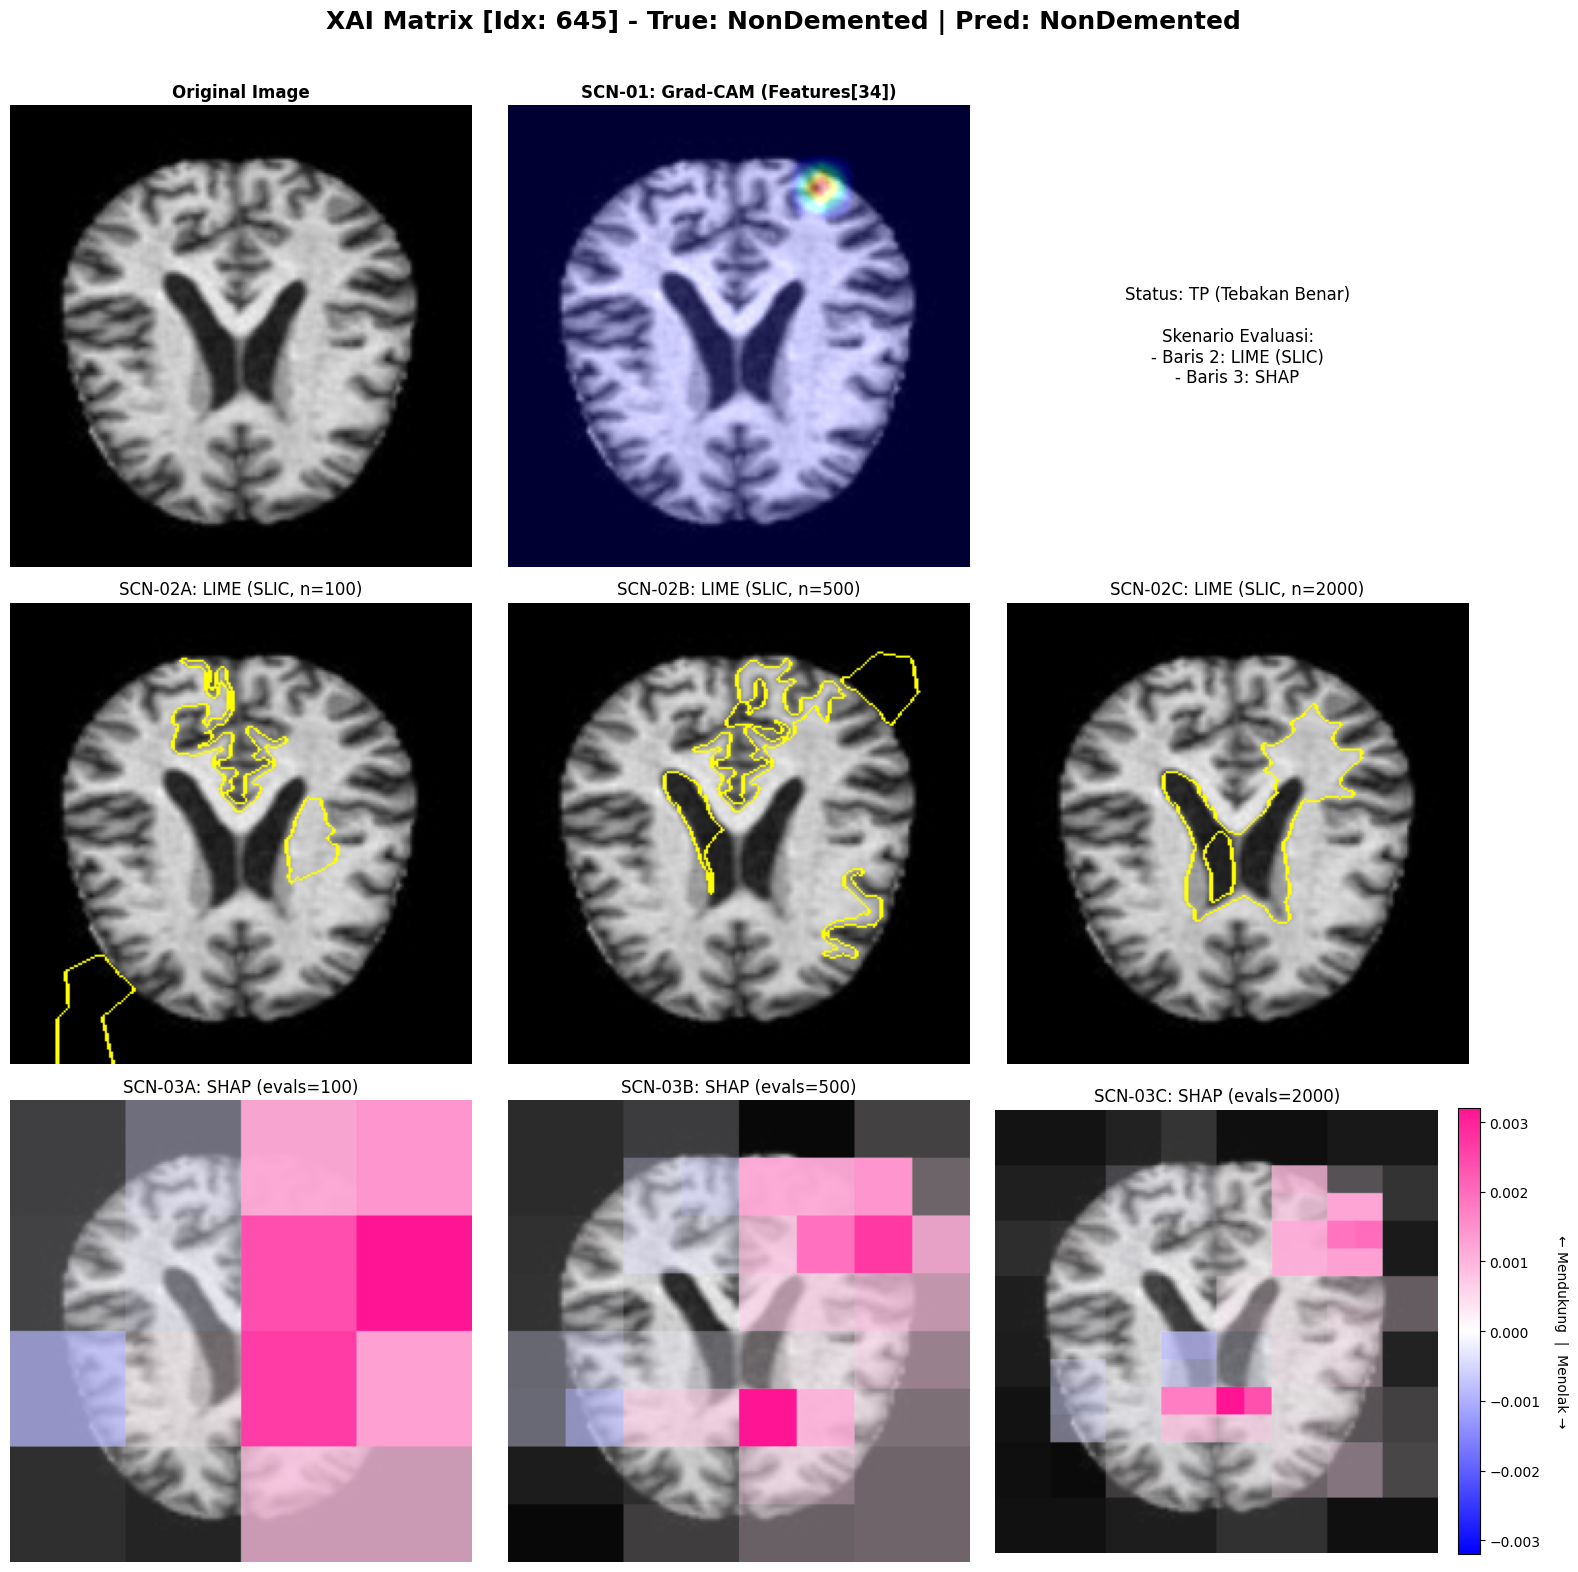

In [ ]:
# ========================================================
# PIPELINE 2: XAI EXPLAINERS & VISUALIZATION ENGINE (VGG19)
# ========================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cv2
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from lime.wrappers.scikit_image import SegmentationAlgorithm

# --- 1. CONFIGURATION & TARGET SAMPLES ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🔥 UBAH PENGATURAN DI BAWAH INI
EXECUTION_MODE = "single"           # Pilih: "single", "class", atau "all"
CUSTOM_INDEX = 645                # Berlaku jika mode "single"
CUSTOM_CLASS = "MildDemented"  # Berlaku jika mode "class"

TARGET_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

# Paste hasil dari Pipeline 1 di sini:
FIXED_INDICES_DICT = {
    "MildDemented": [127, 406, 711, 604, 460, 709, 124, 366, 59, 662, 122, 944, 1110, 1069, 1009],
    "ModerateDemented": [70, 139, 209, 250, 306, 435, 476, 496, 502, 840, 929, 1133, 1136, 1215, 1216],
    "NonDemented": [1149, 430, 20, 257, 409, 421, 955, 27, 91, 794, 338, 1162, 155, 645, 689],
    "VeryMildDemented": [494, 888, 827, 988, 89, 84, 606, 1125, 1006, 364, 189, 811, 373, 79, 1233]
}


# --- 2. XAI CORE ENGINE ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

    def fwd_hook(self, module, inp, out):
        self.activations = out.detach().clone()

    def bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach().clone()

    def generate(self, x, cls):
        fwd_handle = self.target_layer.register_forward_hook(self.fwd_hook)
        bwd_handle = self.target_layer.register_full_backward_hook(self.bwd_hook)
        try:
            self.model.zero_grad()
            out = self.model(x)
            score = out[:, cls]
            score.backward()
            weights = self.gradients.mean(dim=[2, 3], keepdim=True)
            cam = (weights * self.activations).sum(dim=1)
            cam = torch.relu(cam).squeeze().cpu().numpy()
            cam = cv2.resize(cam, (224, 224)) # Disesuaikan untuk VGG19 (224x224)
            return (cam - cam.min()) / (cam.max() + 1e-8)
        finally:
            fwd_handle.remove()
            bwd_handle.remove()

# Inisialisasi Explainers
# Target layer untuk VGG19 biasanya adalah layer konvolusi terakhir (index 34 di dalam block features)
gradcam = GradCAM(model, model.features[34])
explainer_lime = lime_image.LimeImageExplainer()
segmenter_slic = SegmentationAlgorithm('slic', n_segments=100, compactness=10, sigma=1)
masker = shap.maskers.Image("blur(28,28)", (224, 224, 3)) # Disesuaikan untuk VGG19 (224x224)

def lime_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return torch.softmax(model(images_tensor), dim=1).cpu().numpy()

def shap_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return model(images_tensor).cpu().numpy()

explainer_shap = shap.Explainer(shap_predict, masker)


# --- 3. HELPER FUNCTIONS ---
def get_shap_overlay(img_np, sv_heatmap):
    max_val = np.max(np.abs(sv_heatmap))
    vmax = max_val if max_val > 0 else 1.0
    vmin = -vmax

    img_gray = cv2.cvtColor((img_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY) / 255.0
    img_gray_3c = np.stack([img_gray] * 3, axis=-1)
    norm_sv = (sv_heatmap - vmin) / (vmax - vmin)

    cmap = LinearSegmentedColormap.from_list("blue_white_pink", ["blue", "white", "deeppink"])
    shap_rgba = cmap(norm_sv)

    alpha_mask = np.abs(sv_heatmap) / vmax
    shap_rgba[:, :, 3] = np.clip(np.power(alpha_mask, 0.6) * 1.8, 0, 1)

    return img_gray_3c, shap_rgba, cmap, vmin, vmax

def evaluate_sample_status(gt_idx, pred_idx, target_class_idx):
    if gt_idx == target_class_idx and pred_idx == target_class_idx:
        return "TP (Tebakan Benar)"
    elif gt_idx == target_class_idx and pred_idx != target_class_idx:
        return f"FN (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"
    elif gt_idx != target_class_idx and pred_idx == target_class_idx:
        return f"FP (Asli {TARGET_NAMES[gt_idx]}, salah ditebak {TARGET_NAMES[pred_idx]})"
    else:
        if gt_idx == pred_idx:
            return f"True Negative (Benar Kelas {TARGET_NAMES[gt_idx]})"
        return f"Salah Prediksi (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"


# --- 4. VISUALIZATION ENGINE ---
def run_xai_matrix(idx, target_class_name=None):
    img, gt_label = dataset_obj[idx]
    img_np = unnormalize(img)
    x = img.unsqueeze(0).to(device)

    # 🔥 On-the-fly Inference
    with torch.no_grad():
        pred_label = model(x).argmax(dim=1).item()

    target_class_idx = TARGET_NAMES.index(target_class_name) if target_class_name else gt_label
    status = evaluate_sample_status(gt_label, pred_label, target_class_idx)

    print(f"\n{'='*65}")
    print(f"💡 PROCESSING INDEX : {idx}")
    print(f"GT Label        : {TARGET_NAMES[gt_label]}")
    print(f"Predicted       : {TARGET_NAMES[pred_label]}")
    print(f"Status          : {status}")
    print(f"{'='*65}")

    fig, axes = plt.subplots(3, 3, figsize=(16, 16))
    fig.suptitle(f"XAI Matrix [Idx: {idx}] - True: {TARGET_NAMES[gt_label]} | Pred: {TARGET_NAMES[pred_label]}",
                 fontsize=18, fontweight='bold', y=0.98)

    # --- ROW 1: GRAD-CAM ---
    axes[0, 0].imshow(img_np)
    axes[0, 0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')

    cam = gradcam.generate(x, pred_label)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    grad_img = np.clip((heatmap_rgb * 0.4 / 255.0) + img_np, 0, 1)

    axes[0, 1].imshow(grad_img)
    axes[0, 1].set_title("SCN-01: Grad-CAM (Features[34])", fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')

    axes[0, 2].axis('off')
    axes[0, 2].text(0.5, 0.5, f"Status: {status}\n\nSkenario Evaluasi:\n- Baris 2: LIME (SLIC)\n- Baris 3: SHAP",
                    ha='center', va='center', fontsize=12, wrap=True)

    # --- ROW 2: LIME ---
    print("Mengeksekusi Skenario LIME...")
    for j, n_samp in enumerate([100, 500, 2000]):
        explanation = explainer_lime.explain_instance(
            img_np, lime_predict, top_labels=1, num_samples=n_samp, segmentation_fn=segmenter_slic
        )
        lime_img, mask = explanation.get_image_and_mask(
            explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
        )
        axes[1, j].imshow(mark_boundaries(lime_img, mask))
        axes[1, j].set_title(f"SCN-02{chr(65+j)}: LIME (SLIC, n={n_samp})", fontsize=12)
        axes[1, j].axis('off')

    # --- ROW 3: SHAP ---
    print("Mengeksekusi Skenario SHAP...")
    img_np_nhwc = np.expand_dims(img_np, axis=0)
    for j, evals in enumerate([100, 500, 2000]):
        shap_vals = explainer_shap(img_np_nhwc, max_evals=evals, batch_size=50)
        sv_heatmap = shap_vals.values[0, ..., pred_label].sum(axis=-1)

        img_gray_3c, shap_rgba, cmap, vmin, vmax = get_shap_overlay(img_np, sv_heatmap)

        axes[2, j].imshow(img_gray_3c)
        axes[2, j].imshow(shap_rgba)
        axes[2, j].set_title(f"SCN-03{chr(65+j)}: SHAP (evals={evals})", fontsize=12)
        axes[2, j].axis('off')

        if j == 2:
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
            sm.set_array([])
            cbar = fig.colorbar(sm, ax=axes[2, j], orientation='vertical', fraction=0.046, pad=0.04)
            cbar.set_label('← Mendukung  |  Menolak →', rotation=270, labelpad=20)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


# --- 5. EXECUTION CONTROL ---
if EXECUTION_MODE == "single":
    run_xai_matrix(idx=CUSTOM_INDEX)

elif EXECUTION_MODE == "class":
    if CUSTOM_CLASS in FIXED_INDICES_DICT:
        indices = FIXED_INDICES_DICT[CUSTOM_CLASS]
        print(f"\nMenjalankan MATRIX XAI untuk kelas: {CUSTOM_CLASS} (Total {len(indices)} sampel)...")
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=CUSTOM_CLASS)
    else:
        print(f"❌ Error: Kelas '{CUSTOM_CLASS}' tidak valid.")
        print(f"Pilih salah satu dari: {TARGET_NAMES}")

elif EXECUTION_MODE == "all":
    total_samples = sum(len(indices) for indices in FIXED_INDICES_DICT.values())
    print(f"\nMenjalankan MATRIX XAI untuk total {total_samples} sampel terpilih...")
    for class_name, indices in FIXED_INDICES_DICT.items():
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=class_name)

else:
    print("❌ EXECUTION_MODE tidak valid. Pilih 'single', 'class', atau 'all'.")

In [ ]:
# ========================================================
# PIPELINE 2: XAI EXPLAINERS & VISUALIZATION ENGINE (VGG19)
# ========================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cv2
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from lime.wrappers.scikit_image import SegmentationAlgorithm

# --- 1. CONFIGURATION & TARGET SAMPLES ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🔥 UBAH PENGATURAN DI BAWAH INI
EXECUTION_MODE = "class"           # Pilih: "single", "class", atau "all"
CUSTOM_INDEX = 1133                # Berlaku jika mode "single"
CUSTOM_CLASS = "MildDemented"  # Berlaku jika mode "class"

TARGET_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

# Paste hasil dari Pipeline 1 di sini:
FIXED_INDICES_DICT = {
    "MildDemented": [127, 406, 711, 604, 460, 709, 124, 366, 59, 662, 122, 944, 1110, 1069, 1009],
    "ModerateDemented": [70, 139, 209, 250, 306, 435, 476, 496, 502, 840, 929, 1133, 1136, 1215, 1216],
    "NonDemented": [1149, 430, 20, 257, 409, 421, 955, 27, 91, 794, 338, 1162, 155, 645, 689],
    "VeryMildDemented": [494, 888, 827, 988, 89, 84, 606, 1125, 1006, 364, 189, 811, 373, 79, 1233]
}


# --- 2. XAI CORE ENGINE ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

    def fwd_hook(self, module, inp, out):
        self.activations = out.detach().clone()

    def bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach().clone()

    def generate(self, x, cls):
        fwd_handle = self.target_layer.register_forward_hook(self.fwd_hook)
        bwd_handle = self.target_layer.register_full_backward_hook(self.bwd_hook)
        try:
            self.model.zero_grad()
            out = self.model(x)
            score = out[:, cls]
            score.backward()
            weights = self.gradients.mean(dim=[2, 3], keepdim=True)
            cam = (weights * self.activations).sum(dim=1)
            cam = torch.relu(cam).squeeze().cpu().numpy()
            cam = cv2.resize(cam, (224, 224)) # Disesuaikan untuk VGG19 (224x224)
            return (cam - cam.min()) / (cam.max() + 1e-8)
        finally:
            fwd_handle.remove()
            bwd_handle.remove()

# Inisialisasi Explainers
# Target layer untuk VGG19 biasanya adalah layer konvolusi terakhir (index 34 di dalam block features)
gradcam = GradCAM(model, model.features[34])
explainer_lime = lime_image.LimeImageExplainer()
segmenter_slic = SegmentationAlgorithm('slic', n_segments=100, compactness=10, sigma=1)
masker = shap.maskers.Image("blur(28,28)", (224, 224, 3)) # Disesuaikan untuk VGG19 (224x224)

def lime_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return torch.softmax(model(images_tensor), dim=1).cpu().numpy()

def shap_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return model(images_tensor).cpu().numpy()

explainer_shap = shap.Explainer(shap_predict, masker)


# --- 3. HELPER FUNCTIONS ---
def get_shap_overlay(img_np, sv_heatmap):
    max_val = np.max(np.abs(sv_heatmap))
    vmax = max_val if max_val > 0 else 1.0
    vmin = -vmax

    img_gray = cv2.cvtColor((img_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY) / 255.0
    img_gray_3c = np.stack([img_gray] * 3, axis=-1)
    norm_sv = (sv_heatmap - vmin) / (vmax - vmin)

    cmap = LinearSegmentedColormap.from_list("blue_white_pink", ["blue", "white", "deeppink"])
    shap_rgba = cmap(norm_sv)

    alpha_mask = np.abs(sv_heatmap) / vmax
    shap_rgba[:, :, 3] = np.clip(np.power(alpha_mask, 0.6) * 1.8, 0, 1)

    return img_gray_3c, shap_rgba, cmap, vmin, vmax

def evaluate_sample_status(gt_idx, pred_idx, target_class_idx):
    if gt_idx == target_class_idx and pred_idx == target_class_idx:
        return "TP (Tebakan Benar)"
    elif gt_idx == target_class_idx and pred_idx != target_class_idx:
        return f"FN (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"
    elif gt_idx != target_class_idx and pred_idx == target_class_idx:
        return f"FP (Asli {TARGET_NAMES[gt_idx]}, salah ditebak {TARGET_NAMES[pred_idx]})"
    else:
        if gt_idx == pred_idx:
            return f"True Negative (Benar Kelas {TARGET_NAMES[gt_idx]})"
        return f"Salah Prediksi (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"


# --- 4. VISUALIZATION ENGINE ---
def run_xai_matrix(idx, target_class_name=None):
    img, gt_label = dataset_obj[idx]
    img_np = unnormalize(img)
    x = img.unsqueeze(0).to(device)

    # 🔥 On-the-fly Inference
    with torch.no_grad():
        pred_label = model(x).argmax(dim=1).item()

    target_class_idx = TARGET_NAMES.index(target_class_name) if target_class_name else gt_label
    status = evaluate_sample_status(gt_label, pred_label, target_class_idx)

    print(f"\n{'='*65}")
    print(f"💡 PROCESSING INDEX : {idx}")
    print(f"GT Label        : {TARGET_NAMES[gt_label]}")
    print(f"Predicted       : {TARGET_NAMES[pred_label]}")
    print(f"Status          : {status}")
    print(f"{'='*65}")

    fig, axes = plt.subplots(3, 3, figsize=(16, 16))
    fig.suptitle(f"XAI Matrix [Idx: {idx}] - True: {TARGET_NAMES[gt_label]} | Pred: {TARGET_NAMES[pred_label]}",
                 fontsize=18, fontweight='bold', y=0.98)

    # --- ROW 1: GRAD-CAM ---
    axes[0, 0].imshow(img_np)
    axes[0, 0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')

    cam = gradcam.generate(x, pred_label)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    grad_img = np.clip((heatmap_rgb * 0.4 / 255.0) + img_np, 0, 1)

    axes[0, 1].imshow(grad_img)
    axes[0, 1].set_title("SCN-01: Grad-CAM (Features[34])", fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')

    axes[0, 2].axis('off')
    axes[0, 2].text(0.5, 0.5, f"Status: {status}\n\nSkenario Evaluasi:\n- Baris 2: LIME (SLIC)\n- Baris 3: SHAP",
                    ha='center', va='center', fontsize=12, wrap=True)

    # --- ROW 2: LIME ---
    print("Mengeksekusi Skenario LIME...")
    for j, n_samp in enumerate([100, 500, 2000]):
        explanation = explainer_lime.explain_instance(
            img_np, lime_predict, top_labels=1, num_samples=n_samp, segmentation_fn=segmenter_slic
        )
        lime_img, mask = explanation.get_image_and_mask(
            explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
        )
        axes[1, j].imshow(mark_boundaries(lime_img, mask))
        axes[1, j].set_title(f"SCN-02{chr(65+j)}: LIME (SLIC, n={n_samp})", fontsize=12)
        axes[1, j].axis('off')

    # --- ROW 3: SHAP ---
    print("Mengeksekusi Skenario SHAP...")
    img_np_nhwc = np.expand_dims(img_np, axis=0)
    for j, evals in enumerate([100, 500, 2000]):
        shap_vals = explainer_shap(img_np_nhwc, max_evals=evals, batch_size=50)
        sv_heatmap = shap_vals.values[0, ..., pred_label].sum(axis=-1)

        img_gray_3c, shap_rgba, cmap, vmin, vmax = get_shap_overlay(img_np, sv_heatmap)

        axes[2, j].imshow(img_gray_3c)
        axes[2, j].imshow(shap_rgba)
        axes[2, j].set_title(f"SCN-03{chr(65+j)}: SHAP (evals={evals})", fontsize=12)
        axes[2, j].axis('off')

        if j == 2:
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
            sm.set_array([])
            cbar = fig.colorbar(sm, ax=axes[2, j], orientation='vertical', fraction=0.046, pad=0.04)
            cbar.set_label('← Mendukung  |  Menolak →', rotation=270, labelpad=20)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


# --- 5. EXECUTION CONTROL ---
if EXECUTION_MODE == "single":
    run_xai_matrix(idx=CUSTOM_INDEX)

elif EXECUTION_MODE == "class":
    if CUSTOM_CLASS in FIXED_INDICES_DICT:
        indices = FIXED_INDICES_DICT[CUSTOM_CLASS]
        print(f"\nMenjalankan MATRIX XAI untuk kelas: {CUSTOM_CLASS} (Total {len(indices)} sampel)...")
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=CUSTOM_CLASS)
    else:
        print(f"❌ Error: Kelas '{CUSTOM_CLASS}' tidak valid.")
        print(f"Pilih salah satu dari: {TARGET_NAMES}")

elif EXECUTION_MODE == "all":
    total_samples = sum(len(indices) for indices in FIXED_INDICES_DICT.values())
    print(f"\nMenjalankan MATRIX XAI untuk total {total_samples} sampel terpilih...")
    for class_name, indices in FIXED_INDICES_DICT.items():
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=class_name)

else:
    print("❌ EXECUTION_MODE tidak valid. Pilih 'single', 'class', atau 'all'.")

In [ ]:
# ========================================================
# PIPELINE 2: XAI EXPLAINERS & VISUALIZATION ENGINE (VGG19)
# ========================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cv2
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from lime.wrappers.scikit_image import SegmentationAlgorithm

# --- 1. CONFIGURATION & TARGET SAMPLES ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🔥 UBAH PENGATURAN DI BAWAH INI
EXECUTION_MODE = "class"           # Pilih: "single", "class", atau "all"
CUSTOM_INDEX = 1133                # Berlaku jika mode "single"
CUSTOM_CLASS = "ModerateDemented"  # Berlaku jika mode "class"

TARGET_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

# Paste hasil dari Pipeline 1 di sini:
FIXED_INDICES_DICT = {
    "MildDemented": [127, 406, 711, 604, 460, 709, 124, 366, 59, 662, 122, 944, 1110, 1069, 1009],
    "ModerateDemented": [70, 139, 209, 250, 306, 435, 476, 496, 502, 840, 929, 1133, 1136, 1215, 1216],
    "NonDemented": [1149, 430, 20, 257, 409, 421, 955, 27, 91, 794, 338, 1162, 155, 645, 689],
    "VeryMildDemented": [494, 888, 827, 988, 89, 84, 606, 1125, 1006, 364, 189, 811, 373, 79, 1233]
}


# --- 2. XAI CORE ENGINE ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

    def fwd_hook(self, module, inp, out):
        self.activations = out.detach().clone()

    def bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach().clone()

    def generate(self, x, cls):
        fwd_handle = self.target_layer.register_forward_hook(self.fwd_hook)
        bwd_handle = self.target_layer.register_full_backward_hook(self.bwd_hook)
        try:
            self.model.zero_grad()
            out = self.model(x)
            score = out[:, cls]
            score.backward()
            weights = self.gradients.mean(dim=[2, 3], keepdim=True)
            cam = (weights * self.activations).sum(dim=1)
            cam = torch.relu(cam).squeeze().cpu().numpy()
            cam = cv2.resize(cam, (224, 224)) # Disesuaikan untuk VGG19 (224x224)
            return (cam - cam.min()) / (cam.max() + 1e-8)
        finally:
            fwd_handle.remove()
            bwd_handle.remove()

# Inisialisasi Explainers
# Target layer untuk VGG19 biasanya adalah layer konvolusi terakhir (index 34 di dalam block features)
gradcam = GradCAM(model, model.features[34])
explainer_lime = lime_image.LimeImageExplainer()
segmenter_slic = SegmentationAlgorithm('slic', n_segments=100, compactness=10, sigma=1)
masker = shap.maskers.Image("blur(28,28)", (224, 224, 3)) # Disesuaikan untuk VGG19 (224x224)

def lime_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return torch.softmax(model(images_tensor), dim=1).cpu().numpy()

def shap_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return model(images_tensor).cpu().numpy()

explainer_shap = shap.Explainer(shap_predict, masker)


# --- 3. HELPER FUNCTIONS ---
def get_shap_overlay(img_np, sv_heatmap):
    max_val = np.max(np.abs(sv_heatmap))
    vmax = max_val if max_val > 0 else 1.0
    vmin = -vmax

    img_gray = cv2.cvtColor((img_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY) / 255.0
    img_gray_3c = np.stack([img_gray] * 3, axis=-1)
    norm_sv = (sv_heatmap - vmin) / (vmax - vmin)

    cmap = LinearSegmentedColormap.from_list("blue_white_pink", ["blue", "white", "deeppink"])
    shap_rgba = cmap(norm_sv)

    alpha_mask = np.abs(sv_heatmap) / vmax
    shap_rgba[:, :, 3] = np.clip(np.power(alpha_mask, 0.6) * 1.8, 0, 1)

    return img_gray_3c, shap_rgba, cmap, vmin, vmax

def evaluate_sample_status(gt_idx, pred_idx, target_class_idx):
    if gt_idx == target_class_idx and pred_idx == target_class_idx:
        return "TP (Tebakan Benar)"
    elif gt_idx == target_class_idx and pred_idx != target_class_idx:
        return f"FN (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"
    elif gt_idx != target_class_idx and pred_idx == target_class_idx:
        return f"FP (Asli {TARGET_NAMES[gt_idx]}, salah ditebak {TARGET_NAMES[pred_idx]})"
    else:
        if gt_idx == pred_idx:
            return f"True Negative (Benar Kelas {TARGET_NAMES[gt_idx]})"
        return f"Salah Prediksi (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"


# --- 4. VISUALIZATION ENGINE ---
def run_xai_matrix(idx, target_class_name=None):
    img, gt_label = dataset_obj[idx]
    img_np = unnormalize(img)
    x = img.unsqueeze(0).to(device)

    # 🔥 On-the-fly Inference
    with torch.no_grad():
        pred_label = model(x).argmax(dim=1).item()

    target_class_idx = TARGET_NAMES.index(target_class_name) if target_class_name else gt_label
    status = evaluate_sample_status(gt_label, pred_label, target_class_idx)

    print(f"\n{'='*65}")
    print(f"💡 PROCESSING INDEX : {idx}")
    print(f"GT Label        : {TARGET_NAMES[gt_label]}")
    print(f"Predicted       : {TARGET_NAMES[pred_label]}")
    print(f"Status          : {status}")
    print(f"{'='*65}")

    fig, axes = plt.subplots(3, 3, figsize=(16, 16))
    fig.suptitle(f"XAI Matrix [Idx: {idx}] - True: {TARGET_NAMES[gt_label]} | Pred: {TARGET_NAMES[pred_label]}",
                 fontsize=18, fontweight='bold', y=0.98)

    # --- ROW 1: GRAD-CAM ---
    axes[0, 0].imshow(img_np)
    axes[0, 0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')

    cam = gradcam.generate(x, pred_label)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    grad_img = np.clip((heatmap_rgb * 0.4 / 255.0) + img_np, 0, 1)

    axes[0, 1].imshow(grad_img)
    axes[0, 1].set_title("SCN-01: Grad-CAM (Features[34])", fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')

    axes[0, 2].axis('off')
    axes[0, 2].text(0.5, 0.5, f"Status: {status}\n\nSkenario Evaluasi:\n- Baris 2: LIME (SLIC)\n- Baris 3: SHAP",
                    ha='center', va='center', fontsize=12, wrap=True)

    # --- ROW 2: LIME ---
    print("Mengeksekusi Skenario LIME...")
    for j, n_samp in enumerate([100, 500, 2000]):
        explanation = explainer_lime.explain_instance(
            img_np, lime_predict, top_labels=1, num_samples=n_samp, segmentation_fn=segmenter_slic
        )
        lime_img, mask = explanation.get_image_and_mask(
            explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
        )
        axes[1, j].imshow(mark_boundaries(lime_img, mask))
        axes[1, j].set_title(f"SCN-02{chr(65+j)}: LIME (SLIC, n={n_samp})", fontsize=12)
        axes[1, j].axis('off')

    # --- ROW 3: SHAP ---
    print("Mengeksekusi Skenario SHAP...")
    img_np_nhwc = np.expand_dims(img_np, axis=0)
    for j, evals in enumerate([100, 500, 2000]):
        shap_vals = explainer_shap(img_np_nhwc, max_evals=evals, batch_size=50)
        sv_heatmap = shap_vals.values[0, ..., pred_label].sum(axis=-1)

        img_gray_3c, shap_rgba, cmap, vmin, vmax = get_shap_overlay(img_np, sv_heatmap)

        axes[2, j].imshow(img_gray_3c)
        axes[2, j].imshow(shap_rgba)
        axes[2, j].set_title(f"SCN-03{chr(65+j)}: SHAP (evals={evals})", fontsize=12)
        axes[2, j].axis('off')

        if j == 2:
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
            sm.set_array([])
            cbar = fig.colorbar(sm, ax=axes[2, j], orientation='vertical', fraction=0.046, pad=0.04)
            cbar.set_label('← Mendukung  |  Menolak →', rotation=270, labelpad=20)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


# --- 5. EXECUTION CONTROL ---
if EXECUTION_MODE == "single":
    run_xai_matrix(idx=CUSTOM_INDEX)

elif EXECUTION_MODE == "class":
    if CUSTOM_CLASS in FIXED_INDICES_DICT:
        indices = FIXED_INDICES_DICT[CUSTOM_CLASS]
        print(f"\nMenjalankan MATRIX XAI untuk kelas: {CUSTOM_CLASS} (Total {len(indices)} sampel)...")
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=CUSTOM_CLASS)
    else:
        print(f"❌ Error: Kelas '{CUSTOM_CLASS}' tidak valid.")
        print(f"Pilih salah satu dari: {TARGET_NAMES}")

elif EXECUTION_MODE == "all":
    total_samples = sum(len(indices) for indices in FIXED_INDICES_DICT.values())
    print(f"\nMenjalankan MATRIX XAI untuk total {total_samples} sampel terpilih...")
    for class_name, indices in FIXED_INDICES_DICT.items():
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=class_name)

else:
    print("❌ EXECUTION_MODE tidak valid. Pilih 'single', 'class', atau 'all'.")

In [ ]:
# ========================================================
# PIPELINE 2: XAI EXPLAINERS & VISUALIZATION ENGINE (VGG19)
# ========================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cv2
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from lime.wrappers.scikit_image import SegmentationAlgorithm

# --- 1. CONFIGURATION & TARGET SAMPLES ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🔥 UBAH PENGATURAN DI BAWAH INI
EXECUTION_MODE = "class"           # Pilih: "single", "class", atau "all"
CUSTOM_INDEX = 1133                # Berlaku jika mode "single"
CUSTOM_CLASS = "NonDemented"  # Berlaku jika mode "class"

TARGET_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

# Paste hasil dari Pipeline 1 di sini:
FIXED_INDICES_DICT = {
    "MildDemented": [127, 406, 711, 604, 460, 709, 124, 366, 59, 662, 122, 944, 1110, 1069, 1009],
    "ModerateDemented": [70, 139, 209, 250, 306, 435, 476, 496, 502, 840, 929, 1133, 1136, 1215, 1216],
    "NonDemented": [1149, 430, 20, 257, 409, 421, 955, 27, 91, 794, 338, 1162, 155, 645, 689],
    "VeryMildDemented": [494, 888, 827, 988, 89, 84, 606, 1125, 1006, 364, 189, 811, 373, 79, 1233]
}


# --- 2. XAI CORE ENGINE ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

    def fwd_hook(self, module, inp, out):
        self.activations = out.detach().clone()

    def bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach().clone()

    def generate(self, x, cls):
        fwd_handle = self.target_layer.register_forward_hook(self.fwd_hook)
        bwd_handle = self.target_layer.register_full_backward_hook(self.bwd_hook)
        try:
            self.model.zero_grad()
            out = self.model(x)
            score = out[:, cls]
            score.backward()
            weights = self.gradients.mean(dim=[2, 3], keepdim=True)
            cam = (weights * self.activations).sum(dim=1)
            cam = torch.relu(cam).squeeze().cpu().numpy()
            cam = cv2.resize(cam, (224, 224)) # Disesuaikan untuk VGG19 (224x224)
            return (cam - cam.min()) / (cam.max() + 1e-8)
        finally:
            fwd_handle.remove()
            bwd_handle.remove()

# Inisialisasi Explainers
# Target layer untuk VGG19 biasanya adalah layer konvolusi terakhir (index 34 di dalam block features)
gradcam = GradCAM(model, model.features[34])
explainer_lime = lime_image.LimeImageExplainer()
segmenter_slic = SegmentationAlgorithm('slic', n_segments=100, compactness=10, sigma=1)
masker = shap.maskers.Image("blur(28,28)", (224, 224, 3)) # Disesuaikan untuk VGG19 (224x224)

def lime_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return torch.softmax(model(images_tensor), dim=1).cpu().numpy()

def shap_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return model(images_tensor).cpu().numpy()

explainer_shap = shap.Explainer(shap_predict, masker)


# --- 3. HELPER FUNCTIONS ---
def get_shap_overlay(img_np, sv_heatmap):
    max_val = np.max(np.abs(sv_heatmap))
    vmax = max_val if max_val > 0 else 1.0
    vmin = -vmax

    img_gray = cv2.cvtColor((img_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY) / 255.0
    img_gray_3c = np.stack([img_gray] * 3, axis=-1)
    norm_sv = (sv_heatmap - vmin) / (vmax - vmin)

    cmap = LinearSegmentedColormap.from_list("blue_white_pink", ["blue", "white", "deeppink"])
    shap_rgba = cmap(norm_sv)

    alpha_mask = np.abs(sv_heatmap) / vmax
    shap_rgba[:, :, 3] = np.clip(np.power(alpha_mask, 0.6) * 1.8, 0, 1)

    return img_gray_3c, shap_rgba, cmap, vmin, vmax

def evaluate_sample_status(gt_idx, pred_idx, target_class_idx):
    if gt_idx == target_class_idx and pred_idx == target_class_idx:
        return "TP (Tebakan Benar)"
    elif gt_idx == target_class_idx and pred_idx != target_class_idx:
        return f"FN (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"
    elif gt_idx != target_class_idx and pred_idx == target_class_idx:
        return f"FP (Asli {TARGET_NAMES[gt_idx]}, salah ditebak {TARGET_NAMES[pred_idx]})"
    else:
        if gt_idx == pred_idx:
            return f"True Negative (Benar Kelas {TARGET_NAMES[gt_idx]})"
        return f"Salah Prediksi (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"


# --- 4. VISUALIZATION ENGINE ---
def run_xai_matrix(idx, target_class_name=None):
    img, gt_label = dataset_obj[idx]
    img_np = unnormalize(img)
    x = img.unsqueeze(0).to(device)

    # 🔥 On-the-fly Inference
    with torch.no_grad():
        pred_label = model(x).argmax(dim=1).item()

    target_class_idx = TARGET_NAMES.index(target_class_name) if target_class_name else gt_label
    status = evaluate_sample_status(gt_label, pred_label, target_class_idx)

    print(f"\n{'='*65}")
    print(f"💡 PROCESSING INDEX : {idx}")
    print(f"GT Label        : {TARGET_NAMES[gt_label]}")
    print(f"Predicted       : {TARGET_NAMES[pred_label]}")
    print(f"Status          : {status}")
    print(f"{'='*65}")

    fig, axes = plt.subplots(3, 3, figsize=(16, 16))
    fig.suptitle(f"XAI Matrix [Idx: {idx}] - True: {TARGET_NAMES[gt_label]} | Pred: {TARGET_NAMES[pred_label]}",
                 fontsize=18, fontweight='bold', y=0.98)

    # --- ROW 1: GRAD-CAM ---
    axes[0, 0].imshow(img_np)
    axes[0, 0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')

    cam = gradcam.generate(x, pred_label)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    grad_img = np.clip((heatmap_rgb * 0.4 / 255.0) + img_np, 0, 1)

    axes[0, 1].imshow(grad_img)
    axes[0, 1].set_title("SCN-01: Grad-CAM (Features[34])", fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')

    axes[0, 2].axis('off')
    axes[0, 2].text(0.5, 0.5, f"Status: {status}\n\nSkenario Evaluasi:\n- Baris 2: LIME (SLIC)\n- Baris 3: SHAP",
                    ha='center', va='center', fontsize=12, wrap=True)

    # --- ROW 2: LIME ---
    print("Mengeksekusi Skenario LIME...")
    for j, n_samp in enumerate([100, 500, 2000]):
        explanation = explainer_lime.explain_instance(
            img_np, lime_predict, top_labels=1, num_samples=n_samp, segmentation_fn=segmenter_slic
        )
        lime_img, mask = explanation.get_image_and_mask(
            explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
        )
        axes[1, j].imshow(mark_boundaries(lime_img, mask))
        axes[1, j].set_title(f"SCN-02{chr(65+j)}: LIME (SLIC, n={n_samp})", fontsize=12)
        axes[1, j].axis('off')

    # --- ROW 3: SHAP ---
    print("Mengeksekusi Skenario SHAP...")
    img_np_nhwc = np.expand_dims(img_np, axis=0)
    for j, evals in enumerate([100, 500, 2000]):
        shap_vals = explainer_shap(img_np_nhwc, max_evals=evals, batch_size=50)
        sv_heatmap = shap_vals.values[0, ..., pred_label].sum(axis=-1)

        img_gray_3c, shap_rgba, cmap, vmin, vmax = get_shap_overlay(img_np, sv_heatmap)

        axes[2, j].imshow(img_gray_3c)
        axes[2, j].imshow(shap_rgba)
        axes[2, j].set_title(f"SCN-03{chr(65+j)}: SHAP (evals={evals})", fontsize=12)
        axes[2, j].axis('off')

        if j == 2:
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
            sm.set_array([])
            cbar = fig.colorbar(sm, ax=axes[2, j], orientation='vertical', fraction=0.046, pad=0.04)
            cbar.set_label('← Mendukung  |  Menolak →', rotation=270, labelpad=20)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


# --- 5. EXECUTION CONTROL ---
if EXECUTION_MODE == "single":
    run_xai_matrix(idx=CUSTOM_INDEX)

elif EXECUTION_MODE == "class":
    if CUSTOM_CLASS in FIXED_INDICES_DICT:
        indices = FIXED_INDICES_DICT[CUSTOM_CLASS]
        print(f"\nMenjalankan MATRIX XAI untuk kelas: {CUSTOM_CLASS} (Total {len(indices)} sampel)...")
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=CUSTOM_CLASS)
    else:
        print(f"❌ Error: Kelas '{CUSTOM_CLASS}' tidak valid.")
        print(f"Pilih salah satu dari: {TARGET_NAMES}")

elif EXECUTION_MODE == "all":
    total_samples = sum(len(indices) for indices in FIXED_INDICES_DICT.values())
    print(f"\nMenjalankan MATRIX XAI untuk total {total_samples} sampel terpilih...")
    for class_name, indices in FIXED_INDICES_DICT.items():
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=class_name)

else:
    print("❌ EXECUTION_MODE tidak valid. Pilih 'single', 'class', atau 'all'.")

In [ ]:
# ========================================================
# PIPELINE 2: XAI EXPLAINERS & VISUALIZATION ENGINE (VGG19)
# ========================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cv2
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from lime.wrappers.scikit_image import SegmentationAlgorithm

# --- 1. CONFIGURATION & TARGET SAMPLES ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🔥 UBAH PENGATURAN DI BAWAH INI
EXECUTION_MODE = "class"           # Pilih: "single", "class", atau "all"
CUSTOM_INDEX = 1133                # Berlaku jika mode "single"
CUSTOM_CLASS = "VeryMildDemented"  # Berlaku jika mode "class"

TARGET_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

# Paste hasil dari Pipeline 1 di sini:
FIXED_INDICES_DICT = {
    "MildDemented": [127, 406, 711, 604, 460, 709, 124, 366, 59, 662, 122, 944, 1110, 1069, 1009],
    "ModerateDemented": [70, 139, 209, 250, 306, 435, 476, 496, 502, 840, 929, 1133, 1136, 1215, 1216],
    "NonDemented": [1149, 430, 20, 257, 409, 421, 955, 27, 91, 794, 338, 1162, 155, 645, 689],
    "VeryMildDemented": [494, 888, 827, 988, 89, 84, 606, 1125, 1006, 364, 189, 811, 373, 79, 1233]
}


# --- 2. XAI CORE ENGINE ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

    def fwd_hook(self, module, inp, out):
        self.activations = out.detach().clone()

    def bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach().clone()

    def generate(self, x, cls):
        fwd_handle = self.target_layer.register_forward_hook(self.fwd_hook)
        bwd_handle = self.target_layer.register_full_backward_hook(self.bwd_hook)
        try:
            self.model.zero_grad()
            out = self.model(x)
            score = out[:, cls]
            score.backward()
            weights = self.gradients.mean(dim=[2, 3], keepdim=True)
            cam = (weights * self.activations).sum(dim=1)
            cam = torch.relu(cam).squeeze().cpu().numpy()
            cam = cv2.resize(cam, (224, 224)) # Disesuaikan untuk VGG19 (224x224)
            return (cam - cam.min()) / (cam.max() + 1e-8)
        finally:
            fwd_handle.remove()
            bwd_handle.remove()

# Inisialisasi Explainers
# Target layer untuk VGG19 biasanya adalah layer konvolusi terakhir (index 34 di dalam block features)
gradcam = GradCAM(model, model.features[34])
explainer_lime = lime_image.LimeImageExplainer()
segmenter_slic = SegmentationAlgorithm('slic', n_segments=100, compactness=10, sigma=1)
masker = shap.maskers.Image("blur(28,28)", (224, 224, 3)) # Disesuaikan untuk VGG19 (224x224)

def lime_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return torch.softmax(model(images_tensor), dim=1).cpu().numpy()

def shap_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return model(images_tensor).cpu().numpy()

explainer_shap = shap.Explainer(shap_predict, masker)


# --- 3. HELPER FUNCTIONS ---
def get_shap_overlay(img_np, sv_heatmap):
    max_val = np.max(np.abs(sv_heatmap))
    vmax = max_val if max_val > 0 else 1.0
    vmin = -vmax

    img_gray = cv2.cvtColor((img_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY) / 255.0
    img_gray_3c = np.stack([img_gray] * 3, axis=-1)
    norm_sv = (sv_heatmap - vmin) / (vmax - vmin)

    cmap = LinearSegmentedColormap.from_list("blue_white_pink", ["blue", "white", "deeppink"])
    shap_rgba = cmap(norm_sv)

    alpha_mask = np.abs(sv_heatmap) / vmax
    shap_rgba[:, :, 3] = np.clip(np.power(alpha_mask, 0.6) * 1.8, 0, 1)

    return img_gray_3c, shap_rgba, cmap, vmin, vmax

def evaluate_sample_status(gt_idx, pred_idx, target_class_idx):
    if gt_idx == target_class_idx and pred_idx == target_class_idx:
        return "TP (Tebakan Benar)"
    elif gt_idx == target_class_idx and pred_idx != target_class_idx:
        return f"FN (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"
    elif gt_idx != target_class_idx and pred_idx == target_class_idx:
        return f"FP (Asli {TARGET_NAMES[gt_idx]}, salah ditebak {TARGET_NAMES[pred_idx]})"
    else:
        if gt_idx == pred_idx:
            return f"True Negative (Benar Kelas {TARGET_NAMES[gt_idx]})"
        return f"Salah Prediksi (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"


# --- 4. VISUALIZATION ENGINE ---
def run_xai_matrix(idx, target_class_name=None):
    img, gt_label = dataset_obj[idx]
    img_np = unnormalize(img)
    x = img.unsqueeze(0).to(device)

    # 🔥 On-the-fly Inference
    with torch.no_grad():
        pred_label = model(x).argmax(dim=1).item()

    target_class_idx = TARGET_NAMES.index(target_class_name) if target_class_name else gt_label
    status = evaluate_sample_status(gt_label, pred_label, target_class_idx)

    print(f"\n{'='*65}")
    print(f"💡 PROCESSING INDEX : {idx}")
    print(f"GT Label        : {TARGET_NAMES[gt_label]}")
    print(f"Predicted       : {TARGET_NAMES[pred_label]}")
    print(f"Status          : {status}")
    print(f"{'='*65}")

    fig, axes = plt.subplots(3, 3, figsize=(16, 16))
    fig.suptitle(f"XAI Matrix [Idx: {idx}] - True: {TARGET_NAMES[gt_label]} | Pred: {TARGET_NAMES[pred_label]}",
                 fontsize=18, fontweight='bold', y=0.98)

    # --- ROW 1: GRAD-CAM ---
    axes[0, 0].imshow(img_np)
    axes[0, 0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')

    cam = gradcam.generate(x, pred_label)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    grad_img = np.clip((heatmap_rgb * 0.4 / 255.0) + img_np, 0, 1)

    axes[0, 1].imshow(grad_img)
    axes[0, 1].set_title("SCN-01: Grad-CAM (Features[34])", fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')

    axes[0, 2].axis('off')
    axes[0, 2].text(0.5, 0.5, f"Status: {status}\n\nSkenario Evaluasi:\n- Baris 2: LIME (SLIC)\n- Baris 3: SHAP",
                    ha='center', va='center', fontsize=12, wrap=True)

    # --- ROW 2: LIME ---
    print("Mengeksekusi Skenario LIME...")
    for j, n_samp in enumerate([100, 500, 2000]):
        explanation = explainer_lime.explain_instance(
            img_np, lime_predict, top_labels=1, num_samples=n_samp, segmentation_fn=segmenter_slic
        )
        lime_img, mask = explanation.get_image_and_mask(
            explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
        )
        axes[1, j].imshow(mark_boundaries(lime_img, mask))
        axes[1, j].set_title(f"SCN-02{chr(65+j)}: LIME (SLIC, n={n_samp})", fontsize=12)
        axes[1, j].axis('off')

    # --- ROW 3: SHAP ---
    print("Mengeksekusi Skenario SHAP...")
    img_np_nhwc = np.expand_dims(img_np, axis=0)
    for j, evals in enumerate([100, 500, 2000]):
        shap_vals = explainer_shap(img_np_nhwc, max_evals=evals, batch_size=50)
        sv_heatmap = shap_vals.values[0, ..., pred_label].sum(axis=-1)

        img_gray_3c, shap_rgba, cmap, vmin, vmax = get_shap_overlay(img_np, sv_heatmap)

        axes[2, j].imshow(img_gray_3c)
        axes[2, j].imshow(shap_rgba)
        axes[2, j].set_title(f"SCN-03{chr(65+j)}: SHAP (evals={evals})", fontsize=12)
        axes[2, j].axis('off')

        if j == 2:
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
            sm.set_array([])
            cbar = fig.colorbar(sm, ax=axes[2, j], orientation='vertical', fraction=0.046, pad=0.04)
            cbar.set_label('← Mendukung  |  Menolak →', rotation=270, labelpad=20)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


# --- 5. EXECUTION CONTROL ---
if EXECUTION_MODE == "single":
    run_xai_matrix(idx=CUSTOM_INDEX)

elif EXECUTION_MODE == "class":
    if CUSTOM_CLASS in FIXED_INDICES_DICT:
        indices = FIXED_INDICES_DICT[CUSTOM_CLASS]
        print(f"\nMenjalankan MATRIX XAI untuk kelas: {CUSTOM_CLASS} (Total {len(indices)} sampel)...")
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=CUSTOM_CLASS)
    else:
        print(f"❌ Error: Kelas '{CUSTOM_CLASS}' tidak valid.")
        print(f"Pilih salah satu dari: {TARGET_NAMES}")

elif EXECUTION_MODE == "all":
    total_samples = sum(len(indices) for indices in FIXED_INDICES_DICT.values())
    print(f"\nMenjalankan MATRIX XAI untuk total {total_samples} sampel terpilih...")
    for class_name, indices in FIXED_INDICES_DICT.items():
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=class_name)

else:
    print("❌ EXECUTION_MODE tidak valid. Pilih 'single', 'class', atau 'all'.")

## INI GANTI LAYER


💡 PROCESSING INDEX : 711
GT Label        : MildDemented
Predicted       : VeryMildDemented
Status          : FN (Asli MildDemented, ditebak VeryMildDemented)
Mengeksekusi Skenario LIME...


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

Mengeksekusi Skenario SHAP...


  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/1998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:24, 24.56s/it]               


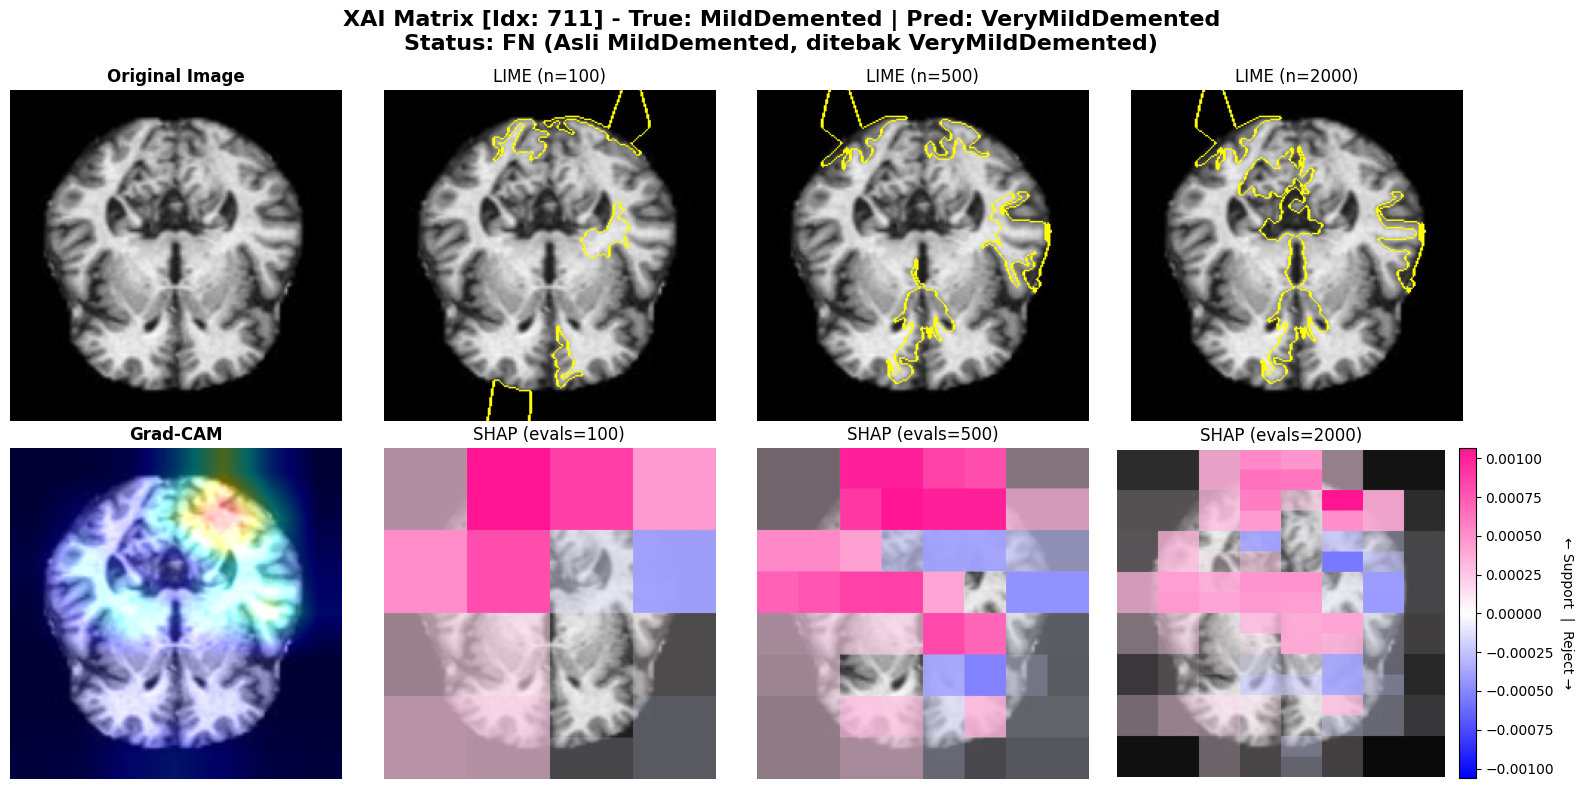

In [ ]:
# ========================================================
# PIPELINE 2: XAI EXPLAINERS & VISUALIZATION ENGINE (VGG19)
# ========================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cv2
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from lime.wrappers.scikit_image import SegmentationAlgorithm

# --- 1. CONFIGURATION & TARGET SAMPLES ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🔥 UBAH PENGATURAN DI BAWAH INI
EXECUTION_MODE = "single"           # Pilih: "single", "class", atau "all"
CUSTOM_INDEX = 709                # Berlaku jika mode "single"
CUSTOM_CLASS = "VeryMildDemented"  # Berlaku jika mode "class"

TARGET_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

# Paste hasil dari Pipeline 1 di sini:
FIXED_INDICES_DICT = {
    "MildDemented": [127, 406, 711, 604, 460, 709, 124, 366, 59, 662, 122, 944, 1110, 1069, 1009],
    "ModerateDemented": [70, 139, 209, 250, 306, 435, 476, 496, 502, 840, 929, 1133, 1136, 1215, 1216],
    "NonDemented": [1149, 430, 20, 257, 409, 421, 955, 27, 91, 794, 338, 1162, 155, 645, 689],
    "VeryMildDemented": [494, 888, 827, 988, 89, 84, 606, 1125, 1006, 364, 189, 811, 373, 79, 1233]
}


# --- 2. XAI CORE ENGINE ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

    def fwd_hook(self, module, inp, out):
        self.activations = out.detach().clone()

    def bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach().clone()

    def generate(self, x, cls):
        fwd_handle = self.target_layer.register_forward_hook(self.fwd_hook)
        bwd_handle = self.target_layer.register_full_backward_hook(self.bwd_hook)
        try:
            self.model.zero_grad()

            # 🔥 PERBAIKAN 1: Paksa tensor input untuk merekam gradien
            x.requires_grad_()

            out = self.model(x)
            score = out[:, cls]
            score.backward()

            weights = self.gradients.mean(dim=[2, 3], keepdim=True)
            cam = (weights * self.activations).sum(dim=1)
            cam = torch.relu(cam).squeeze().cpu().numpy()

            # 🔥 Mencegah error pembagian dengan 0 jika area benar-benar kosong
            if cam.max() == 0:
                cam = cv2.resize(cam, (224, 224))
                return cam

            cam = cv2.resize(cam, (224, 224))
            return (cam - cam.min()) / (cam.max() + 1e-8)
        finally:
            fwd_handle.remove()
            bwd_handle.remove()

# Inisialisasi Explainers
# 🔥 PERBAIKAN 2: Geser target ke ujung fitur (MaxPool2d) agar komputasi hook lebih stabil
gradcam = GradCAM(model, model.features[-1])
explainer_lime = lime_image.LimeImageExplainer()
segmenter_slic = SegmentationAlgorithm('slic', n_segments=100, compactness=10, sigma=1)
masker = shap.maskers.Image("blur(28,28)", (224, 224, 3))

def lime_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return torch.softmax(model(images_tensor), dim=1).cpu().numpy()

def shap_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return model(images_tensor).cpu().numpy()

explainer_shap = shap.Explainer(shap_predict, masker)

# --- 3. HELPER FUNCTIONS ---
def get_shap_overlay(img_np, sv_heatmap):
    max_val = np.max(np.abs(sv_heatmap))
    vmax = max_val if max_val > 0 else 1.0
    vmin = -vmax

    img_gray = cv2.cvtColor((img_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY) / 255.0
    img_gray_3c = np.stack([img_gray] * 3, axis=-1)
    norm_sv = (sv_heatmap - vmin) / (vmax - vmin)

    cmap = LinearSegmentedColormap.from_list("blue_white_pink", ["blue", "white", "deeppink"])
    shap_rgba = cmap(norm_sv)

    alpha_mask = np.abs(sv_heatmap) / vmax
    shap_rgba[:, :, 3] = np.clip(np.power(alpha_mask, 0.6) * 1.8, 0, 1)

    return img_gray_3c, shap_rgba, cmap, vmin, vmax

def evaluate_sample_status(gt_idx, pred_idx, target_class_idx):
    if gt_idx == target_class_idx and pred_idx == target_class_idx:
        return "TP (Tebakan Benar)"
    elif gt_idx == target_class_idx and pred_idx != target_class_idx:
        return f"FN (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"
    elif gt_idx != target_class_idx and pred_idx == target_class_idx:
        return f"FP (Asli {TARGET_NAMES[gt_idx]}, salah ditebak {TARGET_NAMES[pred_idx]})"
    else:
        if gt_idx == pred_idx:
            return f"True Negative (Benar Kelas {TARGET_NAMES[gt_idx]})"
        return f"Salah Prediksi (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"


# --- 4. VISUALIZATION ENGINE ---
# --- 4. VISUALIZATION ENGINE ---
def run_xai_matrix(idx, target_class_name=None):
    img, gt_label = dataset_obj[idx]
    img_np = unnormalize(img)
    x = img.unsqueeze(0).to(device)

    # 🔥 On-the-fly Inference
    with torch.no_grad():
        pred_label = model(x).argmax(dim=1).item()

    target_class_idx = TARGET_NAMES.index(target_class_name) if target_class_name else gt_label
    status = evaluate_sample_status(gt_label, pred_label, target_class_idx)

    print(f"\n{'='*65}")
    print(f"💡 PROCESSING INDEX : {idx}")
    print(f"GT Label        : {TARGET_NAMES[gt_label]}")
    print(f"Predicted       : {TARGET_NAMES[pred_label]}")
    print(f"Status          : {status}")
    print(f"{'='*65}")

    # 🔥 LAYOUT BARU: 2 Baris x 4 Kolom (Jauh lebih compact)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f"XAI Matrix [Idx: {idx}] - True: {TARGET_NAMES[gt_label]} | Pred: {TARGET_NAMES[pred_label]}\nStatus: {status}",
                 fontsize=16, fontweight='bold', y=0.98)

    # ==========================================
    # KOLOM 1: ORIGINAL IMAGE & GRAD-CAM
    # ==========================================
    axes[0, 0].imshow(img_np)
    axes[0, 0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')

    cam = gradcam.generate(x, pred_label)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    grad_img = np.clip((heatmap_rgb * 0.4 / 255.0) + img_np, 0, 1)

    axes[1, 0].imshow(grad_img)
    axes[1, 0].set_title("Grad-CAM", fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')

    # ==========================================
    # KOLOM 2, 3, 4 (BARIS ATAS): LIME
    # ==========================================
    print("Mengeksekusi Skenario LIME...")
    for j, n_samp in enumerate([100, 500, 2000]):
        col_idx = j + 1
        explanation = explainer_lime.explain_instance(
            img_np, lime_predict, top_labels=1, num_samples=n_samp, segmentation_fn=segmenter_slic
        )
        lime_img, mask = explanation.get_image_and_mask(
            explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
        )
        axes[0, col_idx].imshow(mark_boundaries(lime_img, mask))
        axes[0, col_idx].set_title(f"LIME (n={n_samp})", fontsize=12)
        axes[0, col_idx].axis('off')

    # ==========================================
    # KOLOM 2, 3, 4 (BARIS BAWAH): SHAP
    # ==========================================
    print("Mengeksekusi Skenario SHAP...")
    img_np_nhwc = np.expand_dims(img_np, axis=0)
    for j, evals in enumerate([100, 500, 2000]):
        col_idx = j + 1
        shap_vals = explainer_shap(img_np_nhwc, max_evals=evals, batch_size=50)
        sv_heatmap = shap_vals.values[0, ..., pred_label].sum(axis=-1)

        img_gray_3c, shap_rgba, cmap, vmin, vmax = get_shap_overlay(img_np, sv_heatmap)

        axes[1, col_idx].imshow(img_gray_3c)
        axes[1, col_idx].imshow(shap_rgba)
        axes[1, col_idx].set_title(f"SHAP (evals={evals})", fontsize=12)
        axes[1, col_idx].axis('off')

        # Tambahkan Colorbar hanya di gambar SHAP paling akhir
        if j == 2:
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
            sm.set_array([])
            cbar = fig.colorbar(sm, ax=axes[1, col_idx], orientation='vertical', fraction=0.046, pad=0.04)
            cbar.set_label('← Support  |  Reject →', rotation=270, labelpad=15, fontsize=10)

    # Rapikan Jarak
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

# --- 5. EXECUTION CONTROL ---
if EXECUTION_MODE == "single":
    run_xai_matrix(idx=CUSTOM_INDEX)

elif EXECUTION_MODE == "class":
    if CUSTOM_CLASS in FIXED_INDICES_DICT:
        indices = FIXED_INDICES_DICT[CUSTOM_CLASS]
        print(f"\nMenjalankan MATRIX XAI untuk kelas: {CUSTOM_CLASS} (Total {len(indices)} sampel)...")
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=CUSTOM_CLASS)
    else:
        print(f"❌ Error: Kelas '{CUSTOM_CLASS}' tidak valid.")
        print(f"Pilih salah satu dari: {TARGET_NAMES}")

elif EXECUTION_MODE == "all":
    total_samples = sum(len(indices) for indices in FIXED_INDICES_DICT.values())
    print(f"\nMenjalankan MATRIX XAI untuk total {total_samples} sampel terpilih...")
    for class_name, indices in FIXED_INDICES_DICT.items():
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=class_name)

else:
    print("❌ EXECUTION_MODE tidak valid. Pilih 'single', 'class', atau 'all'.")

In [ ]:
# ========================================================
# PIPELINE 2: XAI EXPLAINERS & VISUALIZATION ENGINE (VGG19)
# ========================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cv2
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from lime.wrappers.scikit_image import SegmentationAlgorithm

# --- 1. CONFIGURATION & TARGET SAMPLES ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🔥 UBAH PENGATURAN DI BAWAH INI
EXECUTION_MODE = "class"           # Pilih: "single", "class", atau "all"
CUSTOM_INDEX = 1133                # Berlaku jika mode "single"
CUSTOM_CLASS = "MildDemented"  # Berlaku jika mode "class"

TARGET_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

# Paste hasil dari Pipeline 1 di sini:
FIXED_INDICES_DICT = {
    "MildDemented": [127, 406, 711, 604, 460, 709, 124, 366, 59, 662, 122, 944, 1110, 1069, 1009],
    "ModerateDemented": [70, 139, 209, 250, 306, 435, 476, 496, 502, 840, 929, 1133, 1136, 1215, 1216],
    "NonDemented": [1149, 430, 20, 257, 409, 421, 955, 27, 91, 794, 338, 1162, 155, 645, 689],
    "VeryMildDemented": [494, 888, 827, 988, 89, 84, 606, 1125, 1006, 364, 189, 811, 373, 79, 1233]
}


# --- 2. XAI CORE ENGINE ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

    def fwd_hook(self, module, inp, out):
        self.activations = out.detach().clone()

    def bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach().clone()

    def generate(self, x, cls):
        fwd_handle = self.target_layer.register_forward_hook(self.fwd_hook)
        bwd_handle = self.target_layer.register_full_backward_hook(self.bwd_hook)
        try:
            self.model.zero_grad()

            # 🔥 PERBAIKAN 1: Paksa tensor input untuk merekam gradien
            x.requires_grad_()

            out = self.model(x)
            score = out[:, cls]
            score.backward()

            weights = self.gradients.mean(dim=[2, 3], keepdim=True)
            cam = (weights * self.activations).sum(dim=1)
            cam = torch.relu(cam).squeeze().cpu().numpy()

            # 🔥 Mencegah error pembagian dengan 0 jika area benar-benar kosong
            if cam.max() == 0:
                cam = cv2.resize(cam, (224, 224))
                return cam

            cam = cv2.resize(cam, (224, 224))
            return (cam - cam.min()) / (cam.max() + 1e-8)
        finally:
            fwd_handle.remove()
            bwd_handle.remove()

# Inisialisasi Explainers
# 🔥 PERBAIKAN 2: Geser target ke ujung fitur (MaxPool2d) agar komputasi hook lebih stabil
gradcam = GradCAM(model, model.features[-1])
explainer_lime = lime_image.LimeImageExplainer()
segmenter_slic = SegmentationAlgorithm('slic', n_segments=100, compactness=10, sigma=1)
masker = shap.maskers.Image("blur(28,28)", (224, 224, 3))

def lime_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return torch.softmax(model(images_tensor), dim=1).cpu().numpy()

def shap_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return model(images_tensor).cpu().numpy()

explainer_shap = shap.Explainer(shap_predict, masker)

# --- 3. HELPER FUNCTIONS ---
def get_shap_overlay(img_np, sv_heatmap):
    max_val = np.max(np.abs(sv_heatmap))
    vmax = max_val if max_val > 0 else 1.0
    vmin = -vmax

    img_gray = cv2.cvtColor((img_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY) / 255.0
    img_gray_3c = np.stack([img_gray] * 3, axis=-1)
    norm_sv = (sv_heatmap - vmin) / (vmax - vmin)

    cmap = LinearSegmentedColormap.from_list("blue_white_pink", ["blue", "white", "deeppink"])
    shap_rgba = cmap(norm_sv)

    alpha_mask = np.abs(sv_heatmap) / vmax
    shap_rgba[:, :, 3] = np.clip(np.power(alpha_mask, 0.6) * 1.8, 0, 1)

    return img_gray_3c, shap_rgba, cmap, vmin, vmax

def evaluate_sample_status(gt_idx, pred_idx, target_class_idx):
    if gt_idx == target_class_idx and pred_idx == target_class_idx:
        return "TP (Tebakan Benar)"
    elif gt_idx == target_class_idx and pred_idx != target_class_idx:
        return f"FN (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"
    elif gt_idx != target_class_idx and pred_idx == target_class_idx:
        return f"FP (Asli {TARGET_NAMES[gt_idx]}, salah ditebak {TARGET_NAMES[pred_idx]})"
    else:
        if gt_idx == pred_idx:
            return f"True Negative (Benar Kelas {TARGET_NAMES[gt_idx]})"
        return f"Salah Prediksi (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"


# --- 4. VISUALIZATION ENGINE ---
def run_xai_matrix(idx, target_class_name=None):
    img, gt_label = dataset_obj[idx]
    img_np = unnormalize(img)
    x = img.unsqueeze(0).to(device)

    # 🔥 On-the-fly Inference
    with torch.no_grad():
        pred_label = model(x).argmax(dim=1).item()

    target_class_idx = TARGET_NAMES.index(target_class_name) if target_class_name else gt_label
    status = evaluate_sample_status(gt_label, pred_label, target_class_idx)

    print(f"\n{'='*65}")
    print(f"💡 PROCESSING INDEX : {idx}")
    print(f"GT Label        : {TARGET_NAMES[gt_label]}")
    print(f"Predicted       : {TARGET_NAMES[pred_label]}")
    print(f"Status          : {status}")
    print(f"{'='*65}")

    fig, axes = plt.subplots(3, 3, figsize=(16, 16))
    fig.suptitle(f"XAI Matrix [Idx: {idx}] - True: {TARGET_NAMES[gt_label]} | Pred: {TARGET_NAMES[pred_label]}",
                 fontsize=18, fontweight='bold', y=0.98)

    # --- ROW 1: GRAD-CAM ---
    axes[0, 0].imshow(img_np)
    axes[0, 0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')

    cam = gradcam.generate(x, pred_label)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    grad_img = np.clip((heatmap_rgb * 0.4 / 255.0) + img_np, 0, 1)

    axes[0, 1].imshow(grad_img)
    axes[0, 1].set_title("SCN-01: Grad-CAM (Features[34])", fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')

    axes[0, 2].axis('off')
    axes[0, 2].text(0.5, 0.5, f"Status: {status}\n\nSkenario Evaluasi:\n- Baris 2: LIME (SLIC)\n- Baris 3: SHAP",
                    ha='center', va='center', fontsize=12, wrap=True)

    # --- ROW 2: LIME ---
    print("Mengeksekusi Skenario LIME...")
    for j, n_samp in enumerate([100, 500, 2000]):
        explanation = explainer_lime.explain_instance(
            img_np, lime_predict, top_labels=1, num_samples=n_samp, segmentation_fn=segmenter_slic
        )
        lime_img, mask = explanation.get_image_and_mask(
            explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
        )
        axes[1, j].imshow(mark_boundaries(lime_img, mask))
        axes[1, j].set_title(f"SCN-02{chr(65+j)}: LIME (SLIC, n={n_samp})", fontsize=12)
        axes[1, j].axis('off')

    # --- ROW 3: SHAP ---
    print("Mengeksekusi Skenario SHAP...")
    img_np_nhwc = np.expand_dims(img_np, axis=0)
    for j, evals in enumerate([100, 500, 2000]):
        shap_vals = explainer_shap(img_np_nhwc, max_evals=evals, batch_size=50)
        sv_heatmap = shap_vals.values[0, ..., pred_label].sum(axis=-1)

        img_gray_3c, shap_rgba, cmap, vmin, vmax = get_shap_overlay(img_np, sv_heatmap)

        axes[2, j].imshow(img_gray_3c)
        axes[2, j].imshow(shap_rgba)
        axes[2, j].set_title(f"SCN-03{chr(65+j)}: SHAP (evals={evals})", fontsize=12)
        axes[2, j].axis('off')

        if j == 2:
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
            sm.set_array([])
            cbar = fig.colorbar(sm, ax=axes[2, j], orientation='vertical', fraction=0.046, pad=0.04)
            cbar.set_label('← Mendukung  |  Menolak →', rotation=270, labelpad=20)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


# --- 5. EXECUTION CONTROL ---
if EXECUTION_MODE == "single":
    run_xai_matrix(idx=CUSTOM_INDEX)

elif EXECUTION_MODE == "class":
    if CUSTOM_CLASS in FIXED_INDICES_DICT:
        indices = FIXED_INDICES_DICT[CUSTOM_CLASS]
        print(f"\nMenjalankan MATRIX XAI untuk kelas: {CUSTOM_CLASS} (Total {len(indices)} sampel)...")
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=CUSTOM_CLASS)
    else:
        print(f"❌ Error: Kelas '{CUSTOM_CLASS}' tidak valid.")
        print(f"Pilih salah satu dari: {TARGET_NAMES}")

elif EXECUTION_MODE == "all":
    total_samples = sum(len(indices) for indices in FIXED_INDICES_DICT.values())
    print(f"\nMenjalankan MATRIX XAI untuk total {total_samples} sampel terpilih...")
    for class_name, indices in FIXED_INDICES_DICT.items():
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=class_name)

else:
    print("❌ EXECUTION_MODE tidak valid. Pilih 'single', 'class', atau 'all'.")

In [ ]:
# ========================================================
# PIPELINE 2: XAI EXPLAINERS & VISUALIZATION ENGINE (VGG19)
# ========================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cv2
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from lime.wrappers.scikit_image import SegmentationAlgorithm

# --- 1. CONFIGURATION & TARGET SAMPLES ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🔥 UBAH PENGATURAN DI BAWAH INI
EXECUTION_MODE = "class"           # Pilih: "single", "class", atau "all"
CUSTOM_INDEX = 1133                # Berlaku jika mode "single"
CUSTOM_CLASS = "ModerateDemented"  # Berlaku jika mode "class"

TARGET_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

# Paste hasil dari Pipeline 1 di sini:
FIXED_INDICES_DICT = {
    "MildDemented": [127, 406, 711, 604, 460, 709, 124, 366, 59, 662, 122, 944, 1110, 1069, 1009],
    "ModerateDemented": [70, 139, 209, 250, 306, 435, 476, 496, 502, 840, 929, 1133, 1136, 1215, 1216],
    "NonDemented": [1149, 430, 20, 257, 409, 421, 955, 27, 91, 794, 338, 1162, 155, 645, 689],
    "VeryMildDemented": [494, 888, 827, 988, 89, 84, 606, 1125, 1006, 364, 189, 811, 373, 79, 1233]
}


# --- 2. XAI CORE ENGINE ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

    def fwd_hook(self, module, inp, out):
        self.activations = out.detach().clone()

    def bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach().clone()

    def generate(self, x, cls):
        fwd_handle = self.target_layer.register_forward_hook(self.fwd_hook)
        bwd_handle = self.target_layer.register_full_backward_hook(self.bwd_hook)
        try:
            self.model.zero_grad()

            # 🔥 PERBAIKAN 1: Paksa tensor input untuk merekam gradien
            x.requires_grad_()

            out = self.model(x)
            score = out[:, cls]
            score.backward()

            weights = self.gradients.mean(dim=[2, 3], keepdim=True)
            cam = (weights * self.activations).sum(dim=1)
            cam = torch.relu(cam).squeeze().cpu().numpy()

            # 🔥 Mencegah error pembagian dengan 0 jika area benar-benar kosong
            if cam.max() == 0:
                cam = cv2.resize(cam, (224, 224))
                return cam

            cam = cv2.resize(cam, (224, 224))
            return (cam - cam.min()) / (cam.max() + 1e-8)
        finally:
            fwd_handle.remove()
            bwd_handle.remove()

# Inisialisasi Explainers
# 🔥 PERBAIKAN 2: Geser target ke ujung fitur (MaxPool2d) agar komputasi hook lebih stabil
gradcam = GradCAM(model, model.features[-1])
explainer_lime = lime_image.LimeImageExplainer()
segmenter_slic = SegmentationAlgorithm('slic', n_segments=100, compactness=10, sigma=1)
masker = shap.maskers.Image("blur(28,28)", (224, 224, 3))

def lime_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return torch.softmax(model(images_tensor), dim=1).cpu().numpy()

def shap_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return model(images_tensor).cpu().numpy()

explainer_shap = shap.Explainer(shap_predict, masker)

# --- 3. HELPER FUNCTIONS ---
def get_shap_overlay(img_np, sv_heatmap):
    max_val = np.max(np.abs(sv_heatmap))
    vmax = max_val if max_val > 0 else 1.0
    vmin = -vmax

    img_gray = cv2.cvtColor((img_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY) / 255.0
    img_gray_3c = np.stack([img_gray] * 3, axis=-1)
    norm_sv = (sv_heatmap - vmin) / (vmax - vmin)

    cmap = LinearSegmentedColormap.from_list("blue_white_pink", ["blue", "white", "deeppink"])
    shap_rgba = cmap(norm_sv)

    alpha_mask = np.abs(sv_heatmap) / vmax
    shap_rgba[:, :, 3] = np.clip(np.power(alpha_mask, 0.6) * 1.8, 0, 1)

    return img_gray_3c, shap_rgba, cmap, vmin, vmax

def evaluate_sample_status(gt_idx, pred_idx, target_class_idx):
    if gt_idx == target_class_idx and pred_idx == target_class_idx:
        return "TP (Tebakan Benar)"
    elif gt_idx == target_class_idx and pred_idx != target_class_idx:
        return f"FN (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"
    elif gt_idx != target_class_idx and pred_idx == target_class_idx:
        return f"FP (Asli {TARGET_NAMES[gt_idx]}, salah ditebak {TARGET_NAMES[pred_idx]})"
    else:
        if gt_idx == pred_idx:
            return f"True Negative (Benar Kelas {TARGET_NAMES[gt_idx]})"
        return f"Salah Prediksi (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"


# --- 4. VISUALIZATION ENGINE ---
def run_xai_matrix(idx, target_class_name=None):
    img, gt_label = dataset_obj[idx]
    img_np = unnormalize(img)
    x = img.unsqueeze(0).to(device)

    # 🔥 On-the-fly Inference
    with torch.no_grad():
        pred_label = model(x).argmax(dim=1).item()

    target_class_idx = TARGET_NAMES.index(target_class_name) if target_class_name else gt_label
    status = evaluate_sample_status(gt_label, pred_label, target_class_idx)

    print(f"\n{'='*65}")
    print(f"💡 PROCESSING INDEX : {idx}")
    print(f"GT Label        : {TARGET_NAMES[gt_label]}")
    print(f"Predicted       : {TARGET_NAMES[pred_label]}")
    print(f"Status          : {status}")
    print(f"{'='*65}")

    fig, axes = plt.subplots(3, 3, figsize=(16, 16))
    fig.suptitle(f"XAI Matrix [Idx: {idx}] - True: {TARGET_NAMES[gt_label]} | Pred: {TARGET_NAMES[pred_label]}",
                 fontsize=18, fontweight='bold', y=0.98)

    # --- ROW 1: GRAD-CAM ---
    axes[0, 0].imshow(img_np)
    axes[0, 0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')

    cam = gradcam.generate(x, pred_label)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    grad_img = np.clip((heatmap_rgb * 0.4 / 255.0) + img_np, 0, 1)

    axes[0, 1].imshow(grad_img)
    axes[0, 1].set_title("SCN-01: Grad-CAM (Features[34])", fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')

    axes[0, 2].axis('off')
    axes[0, 2].text(0.5, 0.5, f"Status: {status}\n\nSkenario Evaluasi:\n- Baris 2: LIME (SLIC)\n- Baris 3: SHAP",
                    ha='center', va='center', fontsize=12, wrap=True)

    # --- ROW 2: LIME ---
    print("Mengeksekusi Skenario LIME...")
    for j, n_samp in enumerate([100, 500, 2000]):
        explanation = explainer_lime.explain_instance(
            img_np, lime_predict, top_labels=1, num_samples=n_samp, segmentation_fn=segmenter_slic
        )
        lime_img, mask = explanation.get_image_and_mask(
            explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
        )
        axes[1, j].imshow(mark_boundaries(lime_img, mask))
        axes[1, j].set_title(f"SCN-02{chr(65+j)}: LIME (SLIC, n={n_samp})", fontsize=12)
        axes[1, j].axis('off')

    # --- ROW 3: SHAP ---
    print("Mengeksekusi Skenario SHAP...")
    img_np_nhwc = np.expand_dims(img_np, axis=0)
    for j, evals in enumerate([100, 500, 2000]):
        shap_vals = explainer_shap(img_np_nhwc, max_evals=evals, batch_size=50)
        sv_heatmap = shap_vals.values[0, ..., pred_label].sum(axis=-1)

        img_gray_3c, shap_rgba, cmap, vmin, vmax = get_shap_overlay(img_np, sv_heatmap)

        axes[2, j].imshow(img_gray_3c)
        axes[2, j].imshow(shap_rgba)
        axes[2, j].set_title(f"SCN-03{chr(65+j)}: SHAP (evals={evals})", fontsize=12)
        axes[2, j].axis('off')

        if j == 2:
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
            sm.set_array([])
            cbar = fig.colorbar(sm, ax=axes[2, j], orientation='vertical', fraction=0.046, pad=0.04)
            cbar.set_label('← Mendukung  |  Menolak →', rotation=270, labelpad=20)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


# --- 5. EXECUTION CONTROL ---
if EXECUTION_MODE == "single":
    run_xai_matrix(idx=CUSTOM_INDEX)

elif EXECUTION_MODE == "class":
    if CUSTOM_CLASS in FIXED_INDICES_DICT:
        indices = FIXED_INDICES_DICT[CUSTOM_CLASS]
        print(f"\nMenjalankan MATRIX XAI untuk kelas: {CUSTOM_CLASS} (Total {len(indices)} sampel)...")
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=CUSTOM_CLASS)
    else:
        print(f"❌ Error: Kelas '{CUSTOM_CLASS}' tidak valid.")
        print(f"Pilih salah satu dari: {TARGET_NAMES}")

elif EXECUTION_MODE == "all":
    total_samples = sum(len(indices) for indices in FIXED_INDICES_DICT.values())
    print(f"\nMenjalankan MATRIX XAI untuk total {total_samples} sampel terpilih...")
    for class_name, indices in FIXED_INDICES_DICT.items():
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=class_name)

else:
    print("❌ EXECUTION_MODE tidak valid. Pilih 'single', 'class', atau 'all'.")

In [ ]:
# ========================================================
# PIPELINE 2: XAI EXPLAINERS & VISUALIZATION ENGINE (VGG19)
# ========================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cv2
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from lime.wrappers.scikit_image import SegmentationAlgorithm

# --- 1. CONFIGURATION & TARGET SAMPLES ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🔥 UBAH PENGATURAN DI BAWAH INI
EXECUTION_MODE = "class"           # Pilih: "single", "class", atau "all"
CUSTOM_INDEX = 1133                # Berlaku jika mode "single"
CUSTOM_CLASS = "NonDemented"  # Berlaku jika mode "class"

TARGET_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

# Paste hasil dari Pipeline 1 di sini:
FIXED_INDICES_DICT = {
    "MildDemented": [127, 406, 711, 604, 460, 709, 124, 366, 59, 662, 122, 944, 1110, 1069, 1009],
    "ModerateDemented": [70, 139, 209, 250, 306, 435, 476, 496, 502, 840, 929, 1133, 1136, 1215, 1216],
    "NonDemented": [1149, 430, 20, 257, 409, 421, 955, 27, 91, 794, 338, 1162, 155, 645, 689],
    "VeryMildDemented": [494, 888, 827, 988, 89, 84, 606, 1125, 1006, 364, 189, 811, 373, 79, 1233]
}


# --- 2. XAI CORE ENGINE ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

    def fwd_hook(self, module, inp, out):
        self.activations = out.detach().clone()

    def bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach().clone()

    def generate(self, x, cls):
        fwd_handle = self.target_layer.register_forward_hook(self.fwd_hook)
        bwd_handle = self.target_layer.register_full_backward_hook(self.bwd_hook)
        try:
            self.model.zero_grad()

            # 🔥 PERBAIKAN 1: Paksa tensor input untuk merekam gradien
            x.requires_grad_()

            out = self.model(x)
            score = out[:, cls]
            score.backward()

            weights = self.gradients.mean(dim=[2, 3], keepdim=True)
            cam = (weights * self.activations).sum(dim=1)
            cam = torch.relu(cam).squeeze().cpu().numpy()

            # 🔥 Mencegah error pembagian dengan 0 jika area benar-benar kosong
            if cam.max() == 0:
                cam = cv2.resize(cam, (224, 224))
                return cam

            cam = cv2.resize(cam, (224, 224))
            return (cam - cam.min()) / (cam.max() + 1e-8)
        finally:
            fwd_handle.remove()
            bwd_handle.remove()

# Inisialisasi Explainers
# 🔥 PERBAIKAN 2: Geser target ke ujung fitur (MaxPool2d) agar komputasi hook lebih stabil
gradcam = GradCAM(model, model.features[-1])
explainer_lime = lime_image.LimeImageExplainer()
segmenter_slic = SegmentationAlgorithm('slic', n_segments=100, compactness=10, sigma=1)
masker = shap.maskers.Image("blur(28,28)", (224, 224, 3))

def lime_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return torch.softmax(model(images_tensor), dim=1).cpu().numpy()

def shap_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return model(images_tensor).cpu().numpy()

explainer_shap = shap.Explainer(shap_predict, masker)

# --- 3. HELPER FUNCTIONS ---
def get_shap_overlay(img_np, sv_heatmap):
    max_val = np.max(np.abs(sv_heatmap))
    vmax = max_val if max_val > 0 else 1.0
    vmin = -vmax

    img_gray = cv2.cvtColor((img_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY) / 255.0
    img_gray_3c = np.stack([img_gray] * 3, axis=-1)
    norm_sv = (sv_heatmap - vmin) / (vmax - vmin)

    cmap = LinearSegmentedColormap.from_list("blue_white_pink", ["blue", "white", "deeppink"])
    shap_rgba = cmap(norm_sv)

    alpha_mask = np.abs(sv_heatmap) / vmax
    shap_rgba[:, :, 3] = np.clip(np.power(alpha_mask, 0.6) * 1.8, 0, 1)

    return img_gray_3c, shap_rgba, cmap, vmin, vmax

def evaluate_sample_status(gt_idx, pred_idx, target_class_idx):
    if gt_idx == target_class_idx and pred_idx == target_class_idx:
        return "TP (Tebakan Benar)"
    elif gt_idx == target_class_idx and pred_idx != target_class_idx:
        return f"FN (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"
    elif gt_idx != target_class_idx and pred_idx == target_class_idx:
        return f"FP (Asli {TARGET_NAMES[gt_idx]}, salah ditebak {TARGET_NAMES[pred_idx]})"
    else:
        if gt_idx == pred_idx:
            return f"True Negative (Benar Kelas {TARGET_NAMES[gt_idx]})"
        return f"Salah Prediksi (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"


# --- 4. VISUALIZATION ENGINE ---
def run_xai_matrix(idx, target_class_name=None):
    img, gt_label = dataset_obj[idx]
    img_np = unnormalize(img)
    x = img.unsqueeze(0).to(device)

    # 🔥 On-the-fly Inference
    with torch.no_grad():
        pred_label = model(x).argmax(dim=1).item()

    target_class_idx = TARGET_NAMES.index(target_class_name) if target_class_name else gt_label
    status = evaluate_sample_status(gt_label, pred_label, target_class_idx)

    print(f"\n{'='*65}")
    print(f"💡 PROCESSING INDEX : {idx}")
    print(f"GT Label        : {TARGET_NAMES[gt_label]}")
    print(f"Predicted       : {TARGET_NAMES[pred_label]}")
    print(f"Status          : {status}")
    print(f"{'='*65}")

    fig, axes = plt.subplots(3, 3, figsize=(16, 16))
    fig.suptitle(f"XAI Matrix [Idx: {idx}] - True: {TARGET_NAMES[gt_label]} | Pred: {TARGET_NAMES[pred_label]}",
                 fontsize=18, fontweight='bold', y=0.98)

    # --- ROW 1: GRAD-CAM ---
    axes[0, 0].imshow(img_np)
    axes[0, 0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')

    cam = gradcam.generate(x, pred_label)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    grad_img = np.clip((heatmap_rgb * 0.4 / 255.0) + img_np, 0, 1)

    axes[0, 1].imshow(grad_img)
    axes[0, 1].set_title("SCN-01: Grad-CAM (Features[34])", fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')

    axes[0, 2].axis('off')
    axes[0, 2].text(0.5, 0.5, f"Status: {status}\n\nSkenario Evaluasi:\n- Baris 2: LIME (SLIC)\n- Baris 3: SHAP",
                    ha='center', va='center', fontsize=12, wrap=True)

    # --- ROW 2: LIME ---
    print("Mengeksekusi Skenario LIME...")
    for j, n_samp in enumerate([100, 500, 2000]):
        explanation = explainer_lime.explain_instance(
            img_np, lime_predict, top_labels=1, num_samples=n_samp, segmentation_fn=segmenter_slic
        )
        lime_img, mask = explanation.get_image_and_mask(
            explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
        )
        axes[1, j].imshow(mark_boundaries(lime_img, mask))
        axes[1, j].set_title(f"SCN-02{chr(65+j)}: LIME (SLIC, n={n_samp})", fontsize=12)
        axes[1, j].axis('off')

    # --- ROW 3: SHAP ---
    print("Mengeksekusi Skenario SHAP...")
    img_np_nhwc = np.expand_dims(img_np, axis=0)
    for j, evals in enumerate([100, 500, 2000]):
        shap_vals = explainer_shap(img_np_nhwc, max_evals=evals, batch_size=50)
        sv_heatmap = shap_vals.values[0, ..., pred_label].sum(axis=-1)

        img_gray_3c, shap_rgba, cmap, vmin, vmax = get_shap_overlay(img_np, sv_heatmap)

        axes[2, j].imshow(img_gray_3c)
        axes[2, j].imshow(shap_rgba)
        axes[2, j].set_title(f"SCN-03{chr(65+j)}: SHAP (evals={evals})", fontsize=12)
        axes[2, j].axis('off')

        if j == 2:
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
            sm.set_array([])
            cbar = fig.colorbar(sm, ax=axes[2, j], orientation='vertical', fraction=0.046, pad=0.04)
            cbar.set_label('← Mendukung  |  Menolak →', rotation=270, labelpad=20)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


# --- 5. EXECUTION CONTROL ---
if EXECUTION_MODE == "single":
    run_xai_matrix(idx=CUSTOM_INDEX)

elif EXECUTION_MODE == "class":
    if CUSTOM_CLASS in FIXED_INDICES_DICT:
        indices = FIXED_INDICES_DICT[CUSTOM_CLASS]
        print(f"\nMenjalankan MATRIX XAI untuk kelas: {CUSTOM_CLASS} (Total {len(indices)} sampel)...")
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=CUSTOM_CLASS)
    else:
        print(f"❌ Error: Kelas '{CUSTOM_CLASS}' tidak valid.")
        print(f"Pilih salah satu dari: {TARGET_NAMES}")

elif EXECUTION_MODE == "all":
    total_samples = sum(len(indices) for indices in FIXED_INDICES_DICT.values())
    print(f"\nMenjalankan MATRIX XAI untuk total {total_samples} sampel terpilih...")
    for class_name, indices in FIXED_INDICES_DICT.items():
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=class_name)

else:
    print("❌ EXECUTION_MODE tidak valid. Pilih 'single', 'class', atau 'all'.")

In [ ]:
# ========================================================
# PIPELINE 2: XAI EXPLAINERS & VISUALIZATION ENGINE (VGG19)
# ========================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cv2
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from lime.wrappers.scikit_image import SegmentationAlgorithm

# --- 1. CONFIGURATION & TARGET SAMPLES ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🔥 UBAH PENGATURAN DI BAWAH INI
EXECUTION_MODE = "class"           # Pilih: "single", "class", atau "all"
CUSTOM_INDEX = 1133                # Berlaku jika mode "single"
CUSTOM_CLASS = "VeryMildDemented"  # Berlaku jika mode "class"

TARGET_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

# Paste hasil dari Pipeline 1 di sini:
FIXED_INDICES_DICT = {
    "MildDemented": [127, 406, 711, 604, 460, 709, 124, 366, 59, 662, 122, 944, 1110, 1069, 1009],
    "ModerateDemented": [70, 139, 209, 250, 306, 435, 476, 496, 502, 840, 929, 1133, 1136, 1215, 1216],
    "NonDemented": [1149, 430, 20, 257, 409, 421, 955, 27, 91, 794, 338, 1162, 155, 645, 689],
    "VeryMildDemented": [494, 888, 827, 988, 89, 84, 606, 1125, 1006, 364, 189, 811, 373, 79, 1233]
}


# --- 2. XAI CORE ENGINE ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

    def fwd_hook(self, module, inp, out):
        self.activations = out.detach().clone()

    def bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach().clone()

    def generate(self, x, cls):
        fwd_handle = self.target_layer.register_forward_hook(self.fwd_hook)
        bwd_handle = self.target_layer.register_full_backward_hook(self.bwd_hook)
        try:
            self.model.zero_grad()

            # 🔥 PERBAIKAN 1: Paksa tensor input untuk merekam gradien
            x.requires_grad_()

            out = self.model(x)
            score = out[:, cls]
            score.backward()

            weights = self.gradients.mean(dim=[2, 3], keepdim=True)
            cam = (weights * self.activations).sum(dim=1)
            cam = torch.relu(cam).squeeze().cpu().numpy()

            # 🔥 Mencegah error pembagian dengan 0 jika area benar-benar kosong
            if cam.max() == 0:
                cam = cv2.resize(cam, (224, 224))
                return cam

            cam = cv2.resize(cam, (224, 224))
            return (cam - cam.min()) / (cam.max() + 1e-8)
        finally:
            fwd_handle.remove()
            bwd_handle.remove()

# Inisialisasi Explainers
# 🔥 PERBAIKAN 2: Geser target ke ujung fitur (MaxPool2d) agar komputasi hook lebih stabil
gradcam = GradCAM(model, model.features[-1])
explainer_lime = lime_image.LimeImageExplainer()
segmenter_slic = SegmentationAlgorithm('slic', n_segments=100, compactness=10, sigma=1)
masker = shap.maskers.Image("blur(28,28)", (224, 224, 3))

def lime_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return torch.softmax(model(images_tensor), dim=1).cpu().numpy()

def shap_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return model(images_tensor).cpu().numpy()

explainer_shap = shap.Explainer(shap_predict, masker)

# --- 3. HELPER FUNCTIONS ---
def get_shap_overlay(img_np, sv_heatmap):
    max_val = np.max(np.abs(sv_heatmap))
    vmax = max_val if max_val > 0 else 1.0
    vmin = -vmax

    img_gray = cv2.cvtColor((img_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY) / 255.0
    img_gray_3c = np.stack([img_gray] * 3, axis=-1)
    norm_sv = (sv_heatmap - vmin) / (vmax - vmin)

    cmap = LinearSegmentedColormap.from_list("blue_white_pink", ["blue", "white", "deeppink"])
    shap_rgba = cmap(norm_sv)

    alpha_mask = np.abs(sv_heatmap) / vmax
    shap_rgba[:, :, 3] = np.clip(np.power(alpha_mask, 0.6) * 1.8, 0, 1)

    return img_gray_3c, shap_rgba, cmap, vmin, vmax

def evaluate_sample_status(gt_idx, pred_idx, target_class_idx):
    if gt_idx == target_class_idx and pred_idx == target_class_idx:
        return "TP (Tebakan Benar)"
    elif gt_idx == target_class_idx and pred_idx != target_class_idx:
        return f"FN (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"
    elif gt_idx != target_class_idx and pred_idx == target_class_idx:
        return f"FP (Asli {TARGET_NAMES[gt_idx]}, salah ditebak {TARGET_NAMES[pred_idx]})"
    else:
        if gt_idx == pred_idx:
            return f"True Negative (Benar Kelas {TARGET_NAMES[gt_idx]})"
        return f"Salah Prediksi (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"


# --- 4. VISUALIZATION ENGINE ---
def run_xai_matrix(idx, target_class_name=None):
    img, gt_label = dataset_obj[idx]
    img_np = unnormalize(img)
    x = img.unsqueeze(0).to(device)

    # 🔥 On-the-fly Inference
    with torch.no_grad():
        pred_label = model(x).argmax(dim=1).item()

    target_class_idx = TARGET_NAMES.index(target_class_name) if target_class_name else gt_label
    status = evaluate_sample_status(gt_label, pred_label, target_class_idx)

    print(f"\n{'='*65}")
    print(f"💡 PROCESSING INDEX : {idx}")
    print(f"GT Label        : {TARGET_NAMES[gt_label]}")
    print(f"Predicted       : {TARGET_NAMES[pred_label]}")
    print(f"Status          : {status}")
    print(f"{'='*65}")

    fig, axes = plt.subplots(3, 3, figsize=(16, 16))
    fig.suptitle(f"XAI Matrix [Idx: {idx}] - True: {TARGET_NAMES[gt_label]} | Pred: {TARGET_NAMES[pred_label]}",
                 fontsize=18, fontweight='bold', y=0.98)

    # --- ROW 1: GRAD-CAM ---
    axes[0, 0].imshow(img_np)
    axes[0, 0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')

    cam = gradcam.generate(x, pred_label)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    grad_img = np.clip((heatmap_rgb * 0.4 / 255.0) + img_np, 0, 1)

    axes[0, 1].imshow(grad_img)
    axes[0, 1].set_title("SCN-01: Grad-CAM (Features[34])", fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')

    axes[0, 2].axis('off')
    axes[0, 2].text(0.5, 0.5, f"Status: {status}\n\nSkenario Evaluasi:\n- Baris 2: LIME (SLIC)\n- Baris 3: SHAP",
                    ha='center', va='center', fontsize=12, wrap=True)

    # --- ROW 2: LIME ---
    print("Mengeksekusi Skenario LIME...")
    for j, n_samp in enumerate([100, 500, 2000]):
        explanation = explainer_lime.explain_instance(
            img_np, lime_predict, top_labels=1, num_samples=n_samp, segmentation_fn=segmenter_slic
        )
        lime_img, mask = explanation.get_image_and_mask(
            explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
        )
        axes[1, j].imshow(mark_boundaries(lime_img, mask))
        axes[1, j].set_title(f"SCN-02{chr(65+j)}: LIME (SLIC, n={n_samp})", fontsize=12)
        axes[1, j].axis('off')

    # --- ROW 3: SHAP ---
    print("Mengeksekusi Skenario SHAP...")
    img_np_nhwc = np.expand_dims(img_np, axis=0)
    for j, evals in enumerate([100, 500, 2000]):
        shap_vals = explainer_shap(img_np_nhwc, max_evals=evals, batch_size=50)
        sv_heatmap = shap_vals.values[0, ..., pred_label].sum(axis=-1)

        img_gray_3c, shap_rgba, cmap, vmin, vmax = get_shap_overlay(img_np, sv_heatmap)

        axes[2, j].imshow(img_gray_3c)
        axes[2, j].imshow(shap_rgba)
        axes[2, j].set_title(f"SCN-03{chr(65+j)}: SHAP (evals={evals})", fontsize=12)
        axes[2, j].axis('off')

        if j == 2:
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
            sm.set_array([])
            cbar = fig.colorbar(sm, ax=axes[2, j], orientation='vertical', fraction=0.046, pad=0.04)
            cbar.set_label('← Mendukung  |  Menolak →', rotation=270, labelpad=20)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


# --- 5. EXECUTION CONTROL ---
if EXECUTION_MODE == "single":
    run_xai_matrix(idx=CUSTOM_INDEX)

elif EXECUTION_MODE == "class":
    if CUSTOM_CLASS in FIXED_INDICES_DICT:
        indices = FIXED_INDICES_DICT[CUSTOM_CLASS]
        print(f"\nMenjalankan MATRIX XAI untuk kelas: {CUSTOM_CLASS} (Total {len(indices)} sampel)...")
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=CUSTOM_CLASS)
    else:
        print(f"❌ Error: Kelas '{CUSTOM_CLASS}' tidak valid.")
        print(f"Pilih salah satu dari: {TARGET_NAMES}")

elif EXECUTION_MODE == "all":
    total_samples = sum(len(indices) for indices in FIXED_INDICES_DICT.values())
    print(f"\nMenjalankan MATRIX XAI untuk total {total_samples} sampel terpilih...")
    for class_name, indices in FIXED_INDICES_DICT.items():
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=class_name)

else:
    print("❌ EXECUTION_MODE tidak valid. Pilih 'single', 'class', atau 'all'.")


💡 PROCESSING INDEX : 1133
GT Label        : ModerateDemented
Predicted       : ModerateDemented
Status          : TP (Tebakan Benar)
Mengeksekusi Skenario LIME...


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

Mengeksekusi Skenario SHAP...


  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/1998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:26, 26.87s/it]               


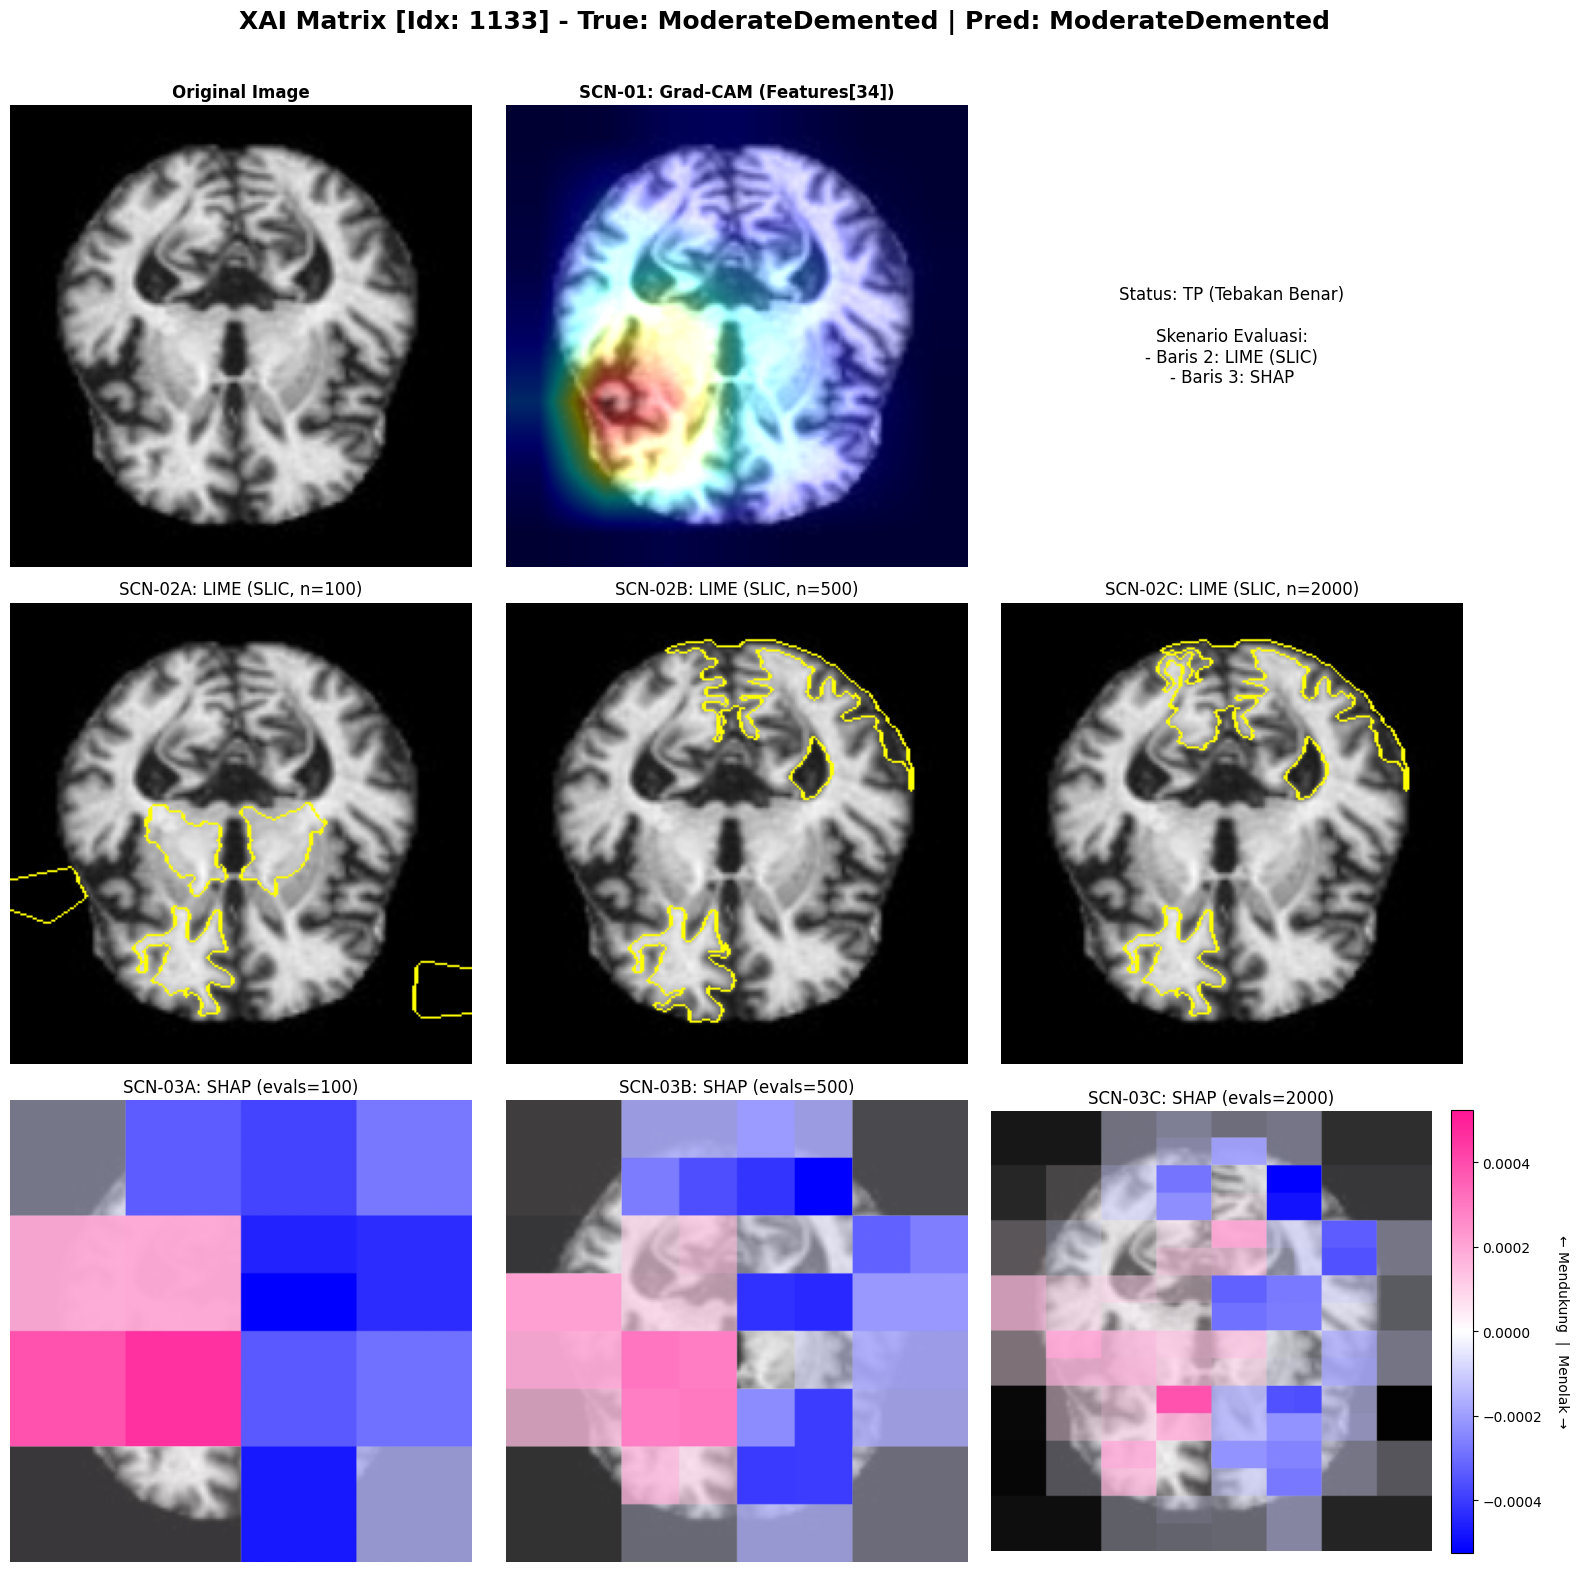

In [ ]:
# ========================================================
# PIPELINE 2: XAI EXPLAINERS & VISUALIZATION ENGINE (VGG19)
# ========================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cv2
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from lime.wrappers.scikit_image import SegmentationAlgorithm

# --- 1. CONFIGURATION & TARGET SAMPLES ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🔥 UBAH PENGATURAN DI BAWAH INI
EXECUTION_MODE = "single"           # Pilih: "single", "class", atau "all"
CUSTOM_INDEX = 1133                # Berlaku jika mode "single"
CUSTOM_CLASS = "VeryMildDemented"  # Berlaku jika mode "class"

TARGET_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

# Paste hasil dari Pipeline 1 di sini:
FIXED_INDICES_DICT = {
    "MildDemented": [127, 406, 711, 604, 460, 709, 124, 366, 59, 662, 122, 944, 1110, 1069, 1009],
    "ModerateDemented": [70, 139, 209, 250, 306, 435, 476, 496, 502, 840, 929, 1133, 1136, 1215, 1216],
    "NonDemented": [1149, 430, 20, 257, 409, 421, 955, 27, 91, 794, 338, 1162, 155, 645, 689],
    "VeryMildDemented": [494, 888, 827, 988, 89, 84, 606, 1125, 1006, 364, 189, 811, 373, 79, 1233]
}


# --- 2. XAI CORE ENGINE ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

    def fwd_hook(self, module, inp, out):
        self.activations = out.detach().clone()

    def bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach().clone()

    def generate(self, x, cls):
        fwd_handle = self.target_layer.register_forward_hook(self.fwd_hook)
        bwd_handle = self.target_layer.register_full_backward_hook(self.bwd_hook)
        try:
            self.model.zero_grad()

            # 🔥 PERBAIKAN 1: Paksa tensor input untuk merekam gradien
            x.requires_grad_()

            out = self.model(x)
            score = out[:, cls]
            score.backward()

            weights = self.gradients.mean(dim=[2, 3], keepdim=True)
            cam = (weights * self.activations).sum(dim=1)
            cam = torch.relu(cam).squeeze().cpu().numpy()

            # 🔥 Mencegah error pembagian dengan 0 jika area benar-benar kosong
            if cam.max() == 0:
                cam = cv2.resize(cam, (224, 224))
                return cam

            cam = cv2.resize(cam, (224, 224))
            return (cam - cam.min()) / (cam.max() + 1e-8)
        finally:
            fwd_handle.remove()
            bwd_handle.remove()

# Inisialisasi Explainers
# 🔥 PERBAIKAN 2: Geser target ke ujung fitur (MaxPool2d) agar komputasi hook lebih stabil
gradcam = GradCAM(model, model.features[-1])
explainer_lime = lime_image.LimeImageExplainer()
segmenter_slic = SegmentationAlgorithm('slic', n_segments=100, compactness=10, sigma=1)
masker = shap.maskers.Image("blur(28,28)", (224, 224, 3))

def lime_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return torch.softmax(model(images_tensor), dim=1).cpu().numpy()

def shap_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return model(images_tensor).cpu().numpy()

explainer_shap = shap.Explainer(shap_predict, masker)

# --- 3. HELPER FUNCTIONS ---
def get_shap_overlay(img_np, sv_heatmap):
    max_val = np.max(np.abs(sv_heatmap))
    vmax = max_val if max_val > 0 else 1.0
    vmin = -vmax

    img_gray = cv2.cvtColor((img_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY) / 255.0
    img_gray_3c = np.stack([img_gray] * 3, axis=-1)
    norm_sv = (sv_heatmap - vmin) / (vmax - vmin)

    cmap = LinearSegmentedColormap.from_list("blue_white_pink", ["blue", "white", "deeppink"])
    shap_rgba = cmap(norm_sv)

    alpha_mask = np.abs(sv_heatmap) / vmax
    shap_rgba[:, :, 3] = np.clip(np.power(alpha_mask, 0.6) * 1.8, 0, 1)

    return img_gray_3c, shap_rgba, cmap, vmin, vmax

def evaluate_sample_status(gt_idx, pred_idx, target_class_idx):
    if gt_idx == target_class_idx and pred_idx == target_class_idx:
        return "TP (Tebakan Benar)"
    elif gt_idx == target_class_idx and pred_idx != target_class_idx:
        return f"FN (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"
    elif gt_idx != target_class_idx and pred_idx == target_class_idx:
        return f"FP (Asli {TARGET_NAMES[gt_idx]}, salah ditebak {TARGET_NAMES[pred_idx]})"
    else:
        if gt_idx == pred_idx:
            return f"True Negative (Benar Kelas {TARGET_NAMES[gt_idx]})"
        return f"Salah Prediksi (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"


# --- 4. VISUALIZATION ENGINE ---
def run_xai_matrix(idx, target_class_name=None):
    img, gt_label = dataset_obj[idx]
    img_np = unnormalize(img)
    x = img.unsqueeze(0).to(device)

    # 🔥 On-the-fly Inference
    with torch.no_grad():
        pred_label = model(x).argmax(dim=1).item()

    target_class_idx = TARGET_NAMES.index(target_class_name) if target_class_name else gt_label
    status = evaluate_sample_status(gt_label, pred_label, target_class_idx)

    print(f"\n{'='*65}")
    print(f"💡 PROCESSING INDEX : {idx}")
    print(f"GT Label        : {TARGET_NAMES[gt_label]}")
    print(f"Predicted       : {TARGET_NAMES[pred_label]}")
    print(f"Status          : {status}")
    print(f"{'='*65}")

    fig, axes = plt.subplots(3, 3, figsize=(16, 16))
    fig.suptitle(f"XAI Matrix [Idx: {idx}] - True: {TARGET_NAMES[gt_label]} | Pred: {TARGET_NAMES[pred_label]}",
                 fontsize=18, fontweight='bold', y=0.98)

    # --- ROW 1: GRAD-CAM ---
    axes[0, 0].imshow(img_np)
    axes[0, 0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')

    cam = gradcam.generate(x, pred_label)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    grad_img = np.clip((heatmap_rgb * 0.4 / 255.0) + img_np, 0, 1)

    axes[0, 1].imshow(grad_img)
    axes[0, 1].set_title("SCN-01: Grad-CAM (Features[34])", fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')

    axes[0, 2].axis('off')
    axes[0, 2].text(0.5, 0.5, f"Status: {status}\n\nSkenario Evaluasi:\n- Baris 2: LIME (SLIC)\n- Baris 3: SHAP",
                    ha='center', va='center', fontsize=12, wrap=True)

    # --- ROW 2: LIME ---
    print("Mengeksekusi Skenario LIME...")
    for j, n_samp in enumerate([100, 500, 2000]):
        explanation = explainer_lime.explain_instance(
            img_np, lime_predict, top_labels=1, num_samples=n_samp, segmentation_fn=segmenter_slic
        )
        lime_img, mask = explanation.get_image_and_mask(
            explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
        )
        axes[1, j].imshow(mark_boundaries(lime_img, mask))
        axes[1, j].set_title(f"SCN-02{chr(65+j)}: LIME (SLIC, n={n_samp})", fontsize=12)
        axes[1, j].axis('off')

    # --- ROW 3: SHAP ---
    print("Mengeksekusi Skenario SHAP...")
    img_np_nhwc = np.expand_dims(img_np, axis=0)
    for j, evals in enumerate([100, 500, 2000]):
        shap_vals = explainer_shap(img_np_nhwc, max_evals=evals, batch_size=50)
        sv_heatmap = shap_vals.values[0, ..., pred_label].sum(axis=-1)

        img_gray_3c, shap_rgba, cmap, vmin, vmax = get_shap_overlay(img_np, sv_heatmap)

        axes[2, j].imshow(img_gray_3c)
        axes[2, j].imshow(shap_rgba)
        axes[2, j].set_title(f"SCN-03{chr(65+j)}: SHAP (evals={evals})", fontsize=12)
        axes[2, j].axis('off')

        if j == 2:
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
            sm.set_array([])
            cbar = fig.colorbar(sm, ax=axes[2, j], orientation='vertical', fraction=0.046, pad=0.04)
            cbar.set_label('← Mendukung  |  Menolak →', rotation=270, labelpad=20)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


# --- 5. EXECUTION CONTROL ---
if EXECUTION_MODE == "single":
    run_xai_matrix(idx=CUSTOM_INDEX)

elif EXECUTION_MODE == "class":
    if CUSTOM_CLASS in FIXED_INDICES_DICT:
        indices = FIXED_INDICES_DICT[CUSTOM_CLASS]
        print(f"\nMenjalankan MATRIX XAI untuk kelas: {CUSTOM_CLASS} (Total {len(indices)} sampel)...")
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=CUSTOM_CLASS)
    else:
        print(f"❌ Error: Kelas '{CUSTOM_CLASS}' tidak valid.")
        print(f"Pilih salah satu dari: {TARGET_NAMES}")

elif EXECUTION_MODE == "all":
    total_samples = sum(len(indices) for indices in FIXED_INDICES_DICT.values())
    print(f"\nMenjalankan MATRIX XAI untuk total {total_samples} sampel terpilih...")
    for class_name, indices in FIXED_INDICES_DICT.items():
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=class_name)

else:
    print("❌ EXECUTION_MODE tidak valid. Pilih 'single', 'class', atau 'all'.")

## INI 4 gambar doang

In [ ]:
# ========================================================
# PIPELINE 2: XAI EXPLAINERS & VISUALIZATION ENGINE (VGG19)
# ========================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cv2
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from lime.wrappers.scikit_image import SegmentationAlgorithm

# --- 1. CONFIGURATION & TARGET SAMPLES ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🔥 UBAH PENGATURAN DI BAWAH INI
EXECUTION_MODE = "single"           # Pilih: "single", "class", atau "all"
CUSTOM_INDEX = 711                # Berlaku jika mode "single"
CUSTOM_CLASS = "VeryMildDemented"  # Berlaku jika mode "class"

TARGET_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

# Paste hasil dari Pipeline 1 di sini:
FIXED_INDICES_DICT = {
    "MildDemented": [127, 406, 711, 604, 460, 709, 124, 366, 59, 662, 122, 944, 1110, 1069, 1009],
    "ModerateDemented": [70, 139, 209, 250, 306, 435, 476, 496, 502, 840, 929, 1133, 1136, 1215, 1216],
    "NonDemented": [1149, 430, 20, 257, 409, 421, 955, 27, 91, 794, 338, 1162, 155, 645, 689],
    "VeryMildDemented": [494, 888, 827, 988, 89, 84, 606, 1125, 1006, 364, 189, 811, 373, 79, 1233]
}

# --- 2. XAI CORE ENGINE ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

    def fwd_hook(self, module, inp, out):
        self.activations = out.detach().clone()

    def bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach().clone()

    def generate(self, x, cls):
        fwd_handle = self.target_layer.register_forward_hook(self.fwd_hook)
        bwd_handle = self.target_layer.register_full_backward_hook(self.bwd_hook)
        try:
            self.model.zero_grad()

            # 🔥 PERBAIKAN 1: Paksa tensor input untuk merekam gradien
            x.requires_grad_()

            out = self.model(x)
            score = out[:, cls]
            score.backward()

            weights = self.gradients.mean(dim=[2, 3], keepdim=True)
            cam = (weights * self.activations).sum(dim=1)
            cam = torch.relu(cam).squeeze().cpu().numpy()

            # 🔥 Mencegah error pembagian dengan 0 jika area benar-benar kosong
            if cam.max() == 0:
                cam = cv2.resize(cam, (224, 224))
                return cam

            cam = cv2.resize(cam, (224, 224))
            return (cam - cam.min()) / (cam.max() + 1e-8)
        finally:
            fwd_handle.remove()
            bwd_handle.remove()

# Inisialisasi Explainers
# 🔥 PERBAIKAN 2: Geser target ke ujung fitur (misalnya MaxPool2d) agar komputasi hook lebih stabil
gradcam = GradCAM(model, model.features[-1])
explainer_lime = lime_image.LimeImageExplainer()
segmenter_slic = SegmentationAlgorithm('slic', n_segments=100, compactness=10, sigma=1)
masker = shap.maskers.Image("blur(28,28)", (224, 224, 3))

def lime_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return torch.softmax(model(images_tensor), dim=1).cpu().numpy()

def shap_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return model(images_tensor).cpu().numpy()

explainer_shap = shap.Explainer(shap_predict, masker)

# --- 3. HELPER FUNCTIONS ---
def get_shap_overlay(img_np, sv_heatmap):
    max_val = np.max(np.abs(sv_heatmap))
    vmax = max_val if max_val > 0 else 1.0
    vmin = -vmax

    img_gray = cv2.cvtColor((img_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY) / 255.0
    img_gray_3c = np.stack([img_gray] * 3, axis=-1)
    norm_sv = (sv_heatmap - vmin) / (vmax - vmin)

    cmap = LinearSegmentedColormap.from_list("blue_white_pink", ["blue", "white", "deeppink"])
    shap_rgba = cmap(norm_sv)

    alpha_mask = np.abs(sv_heatmap) / vmax
    shap_rgba[:, :, 3] = np.clip(np.power(alpha_mask, 0.6) * 1.8, 0, 1)

    return img_gray_3c, shap_rgba, cmap, vmin, vmax

def evaluate_sample_status(gt_idx, pred_idx, target_class_idx):
    if gt_idx == target_class_idx and pred_idx == target_class_idx:
        return "TP (Tebakan Benar)"
    elif gt_idx == target_class_idx and pred_idx != target_class_idx:
        return f"FN (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"
    elif gt_idx != target_class_idx and pred_idx == target_class_idx:
        return f"FP (Asli {TARGET_NAMES[gt_idx]}, salah ditebak {TARGET_NAMES[pred_idx]})"
    else:
        if gt_idx == pred_idx:
            return f"True Negative (Benar Kelas {TARGET_NAMES[gt_idx]})"
        return f"Salah Prediksi (Asli {TARGET_NAMES[gt_idx]}, ditebak {TARGET_NAMES[pred_idx]})"


# --- 4. VISUALIZATION ENGINE ---
def run_xai_matrix(idx, target_class_name=None):
    img, gt_label = dataset_obj[idx]
    img_np = unnormalize(img)
    x = img.unsqueeze(0).to(device)

    # 🔥 On-the-fly Inference
    with torch.no_grad():
        pred_label = model(x).argmax(dim=1).item()

    target_class_idx = TARGET_NAMES.index(target_class_name) if target_class_name else gt_label
    status = evaluate_sample_status(gt_label, pred_label, target_class_idx)

    print(f"\n{'='*65}")
    print(f"💡 PROCESSING INDEX : {idx}")
    print(f"GT Label        : {TARGET_NAMES[gt_label]}")
    print(f"Predicted       : {TARGET_NAMES[pred_label]}")
    print(f"Status          : {status}")
    print(f"{'='*65}")

    # 🔥 PERUBAHAN: 1 baris x 4 kolom, lebih hemat ruang
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"XAI Visuals [Idx: {idx}] - True: {TARGET_NAMES[gt_label]} | Pred: {TARGET_NAMES[pred_label]}",
                 fontsize=16, fontweight='bold', y=1.05)

    # --- 1. ORIGINAL IMAGE ---
    axes[0].imshow(img_np)
    axes[0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # --- 2. GRAD-CAM ---
    cam = gradcam.generate(x, pred_label)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    grad_img = np.clip((heatmap_rgb * 0.4 / 255.0) + img_np, 0, 1)

    axes[1].imshow(grad_img)
    axes[1].set_title("Grad-CAM", fontsize=12, fontweight='bold')
    axes[1].axis('off')

    # --- 3. LIME (n=500) ---
    print("Mengeksekusi LIME (n=500)...")
    explanation = explainer_lime.explain_instance(
        img_np, lime_predict, top_labels=1, num_samples=500, segmentation_fn=segmenter_slic
    )
    lime_img, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
    )
    axes[2].imshow(mark_boundaries(lime_img, mask))
    axes[2].set_title("LIME (n=500)", fontsize=12, fontweight='bold')
    axes[2].axis('off')

    # --- 4. SHAP (evals=2000) ---
    print("Mengeksekusi SHAP (evals=2000)...")
    img_np_nhwc = np.expand_dims(img_np, axis=0)

    shap_vals = explainer_shap(img_np_nhwc, max_evals=2000, batch_size=50)
    sv_heatmap = shap_vals.values[0, ..., pred_label].sum(axis=-1)

    img_gray_3c, shap_rgba, cmap, vmin, vmax = get_shap_overlay(img_np, sv_heatmap)

    axes[3].imshow(img_gray_3c)
    axes[3].imshow(shap_rgba)
    axes[3].set_title("SHAP (evals=2000)", fontsize=12, fontweight='bold')
    axes[3].axis('off')

    # Tambahkan colorbar pada bagian SHAP
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes[3], orientation='vertical', fraction=0.046, pad=0.04)
    cbar.set_label('← Mendukung  |  Menolak →', rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()


# --- 5. EXECUTION CONTROL ---
if EXECUTION_MODE == "single":
    run_xai_matrix(idx=CUSTOM_INDEX)

elif EXECUTION_MODE == "class":
    if CUSTOM_CLASS in FIXED_INDICES_DICT:
        indices = FIXED_INDICES_DICT[CUSTOM_CLASS]
        print(f"\nMenjalankan MATRIX XAI untuk kelas: {CUSTOM_CLASS} (Total {len(indices)} sampel)...")
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=CUSTOM_CLASS)
    else:
        print(f"❌ Error: Kelas '{CUSTOM_CLASS}' tidak valid.")
        print(f"Pilih salah satu dari: {TARGET_NAMES}")

elif EXECUTION_MODE == "all":
    total_samples = sum(len(indices) for indices in FIXED_INDICES_DICT.values())
    print(f"\nMenjalankan MATRIX XAI untuk total {total_samples} sampel terpilih...")
    for class_name, indices in FIXED_INDICES_DICT.items():
        for idx in indices:
            run_xai_matrix(idx=idx, target_class_name=class_name)

else:
    print("❌ EXECUTION_MODE tidak valid. Pilih 'single', 'class', atau 'all'.")

## PIPELINE 3

In [ ]:
# ========================================================
# PIPELINE 3: QUANTITATIVE EVALUATION ENGINE (VGG19)
# ========================================================
import torch
import numpy as np
import time
import cv2
from sklearn.metrics import auc
import pandas as pd

# --- 1. CONFIGURATION ---
# Pastikan model, device, dataset_obj, gradcam, explainer_lime, explainer_shap
# sudah terinisialisasi dan berjalan dari sel/Pipeline sebelumnya.

EXECUTION_MODE = "single"          # Pilih: "single", "class", atau "all"
CUSTOM_INDEX = 1133                # Berlaku jika mode "single"
CUSTOM_CLASS = "VeryMildDemented"  # Berlaku jika mode "class"

# --- 2. METRICS CALCULATOR FUNCTIONS ---
def calculate_sparsity(heatmap, threshold=0.2):
    """Menghitung rasio piksel yang tidak relevan (mendekati 0)"""
    norm_heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    sparse_pixels = np.sum(norm_heatmap < threshold)
    total_pixels = heatmap.size
    return sparse_pixels / total_pixels

def calculate_deletion_insertion(model, img_tensor, heatmap, target_class, step=0.1):
    """Menghitung metrik Deletion (AUC) dan Insertion (AUC)"""
    device = img_tensor.device
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap_flat = heatmap.flatten()

    # 🔥 FIX: Tambahkan .copy() untuk menghilangkan negative stride NumPy
    sorted_indices = np.argsort(heatmap_flat)[::-1].copy()

    total_pixels = len(heatmap_flat)
    steps = np.arange(0, 1.0 + step, step)

    del_scores, ins_scores = [], []
    baseline_img = torch.zeros_like(img_tensor)

    with torch.no_grad():
        for s in steps:
            num_pixels = int(s * total_pixels)
            mask_indices = sorted_indices[:num_pixels]

            # Deletion
            del_img = img_tensor.clone().view(3, -1)
            del_img[:, mask_indices] = 0
            del_img = del_img.view(1, 3, 224, 224)
            del_out = torch.softmax(model(del_img), dim=1)
            del_scores.append(del_out[0, target_class].item())

            # Insertion
            ins_img = baseline_img.clone().view(3, -1)
            ins_img[:, mask_indices] = img_tensor.view(3, -1)[:, mask_indices]
            ins_img = ins_img.view(1, 3, 224, 224)
            ins_out = torch.softmax(model(ins_img), dim=1)
            ins_scores.append(ins_out[0, target_class].item())

    return auc(steps, del_scores), auc(steps, ins_scores)

def calculate_robustness(method_func, img_tensor, original_heatmap, noise_level=0.02):
    """Menghitung stabilitas penjelasan terhadap noise kecil (Skor 0-1)"""
    noise = torch.randn_like(img_tensor) * noise_level
    noisy_img = torch.clamp(img_tensor + noise, 0, 1)

    noisy_heatmap = method_func(noisy_img)

    orig_norm = (original_heatmap - original_heatmap.min()) / (original_heatmap.max() - original_heatmap.min() + 1e-8)
    noisy_norm = (noisy_heatmap - noisy_heatmap.min()) / (noisy_heatmap.max() - noisy_heatmap.min() + 1e-8)

    mse = np.mean((orig_norm - noisy_norm) ** 2)
    return 1.0 - np.clip(mse, 0, 1)

# --- 3. XAI WRAPPERS ---
def get_gradcam_heatmap(img_t, target_label):
    img_t.requires_grad_()
    return gradcam.generate(img_t, target_label)

def get_lime_heatmap(img_np, target_label, num_samples):
    explanation = explainer_lime.explain_instance(
        img_np, lime_predict, top_labels=1, num_samples=num_samples, segmentation_fn=segmenter_slic
    )
    dict_heatmap = dict(explanation.local_exp[explanation.top_labels[0]])
    heatmap = np.zeros(explanation.segments.shape)
    for seg_val, weight in dict_heatmap.items():
        heatmap[explanation.segments == seg_val] = weight
    return cv2.resize(heatmap, (224, 224))

def get_shap_heatmap(img_np, target_label, evals):
    img_nhwc = np.expand_dims(img_np, axis=0)
    shap_vals = explainer_shap(img_nhwc, max_evals=evals, batch_size=50)
    sv_heatmap = shap_vals.values[0, ..., target_label].sum(axis=-1)
    return cv2.resize(sv_heatmap, (224, 224))

# --- 4. CORE EVALUATION ENGINE ---
def run_quantitative_eval(idx):
    print(f"\n[{idx}] Mengekstrak Metrik XAI...")
    img, gt_label = dataset_obj[idx]
    img_np = unnormalize(img)
    x = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred_label = model(x).argmax(dim=1).item()

    results = []

    # helper for append
    def append_res(scn_name, del_s, ins_s, rob_s, spa_s, cost_s):
        results.append({
            "Skenario": scn_name, "Deletion (↓)": del_s, "Insertion (↑)": ins_s,
            "Robustness (↑)": rob_s, "Sparsity (↑)": spa_s, "Cost (Sec) (↓)": cost_s
        })

    # --- SCN-01: Grad-CAM ---
    t0 = time.time()
    hm_gc = get_gradcam_heatmap(x, pred_label)
    cost_gc = time.time() - t0
    del_gc, ins_gc = calculate_deletion_insertion(model, x[0], hm_gc, pred_label)
    rob_gc = calculate_robustness(lambda t: get_gradcam_heatmap(t.unsqueeze(0), pred_label), x[0], hm_gc)
    append_res("SCN-01: Grad-CAM", del_gc, ins_gc, rob_gc, calculate_sparsity(hm_gc), cost_gc)

    # --- SCN-02: LIME ---
    for n in [100, 500, 2000]:
        t0 = time.time()
        hm_lm = get_lime_heatmap(img_np, pred_label, num_samples=n)
        cost_lm = time.time() - t0
        del_lm, ins_lm = calculate_deletion_insertion(model, x[0], hm_lm, pred_label)
        rob_lm = calculate_robustness(lambda t: get_lime_heatmap(unnormalize(t.cpu()), pred_label, num_samples=n), x[0].cpu(), hm_lm)
        append_res(f"SCN-02: LIME (n={n})", del_lm, ins_lm, rob_lm, calculate_sparsity(hm_lm), cost_lm)

    # --- SCN-03: SHAP ---
    for ev in [100, 500, 2000]:
        t0 = time.time()
        hm_sh = get_shap_heatmap(img_np, pred_label, evals=ev)
        cost_sh = time.time() - t0
        del_sh, ins_sh = calculate_deletion_insertion(model, x[0], hm_sh, pred_label)
        rob_sh = calculate_robustness(lambda t: get_shap_heatmap(unnormalize(t.cpu()), pred_label, evals=ev), x[0].cpu(), hm_sh)
        append_res(f"SCN-03: SHAP (e={ev})", del_sh, ins_sh, rob_sh, calculate_sparsity(hm_sh), cost_sh)

    return pd.DataFrame(results)

# --- 5. EXECUTION HANDLER ---
all_dfs = []

if EXECUTION_MODE == "single":
    df = run_quantitative_eval(CUSTOM_INDEX)
    print(f"\n=== HASIL EVALUASI INDEX: {CUSTOM_INDEX} ===")
    print(df.to_string(index=False))

elif EXECUTION_MODE == "class":
    if CUSTOM_CLASS in FIXED_INDICES_DICT:
        indices = FIXED_INDICES_DICT[CUSTOM_CLASS]
        print(f"\nMemulai Evaluasi Kuantitatif untuk {len(indices)} sampel di kelas {CUSTOM_CLASS}...")
        for idx in indices:
            df = run_quantitative_eval(idx)
            all_dfs.append(df)

        final_df = pd.concat(all_dfs).groupby("Skenario", as_index=False).mean()
        print(f"\n=== RATA-RATA EVALUASI KELAS: {CUSTOM_CLASS} ===")
        print(final_df.to_string(index=False))
    else:
        print("❌ Kelas tidak valid.")

elif EXECUTION_MODE == "all":
    print("\nMemulai Evaluasi Kuantitatif untuk SELURUH sampel...")
    for cls_name, indices in FIXED_INDICES_DICT.items():
        for idx in indices:
            df = run_quantitative_eval(idx)
            all_dfs.append(df)

    final_df = pd.concat(all_dfs).groupby("Skenario", as_index=False).mean()
    print("\n=== RATA-RATA EVALUASI SELURUH KELAS ===")
    print(final_df.to_string(index=False))


[1133] Mengekstrak Metrik XAI...


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/1998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:23, 23.69s/it]               


  0%|          | 0/1998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:23, 23.60s/it]               


=== HASIL EVALUASI INDEX: 1133 ===
             Skenario  Deletion (↓)  Insertion (↑)  Robustness (↑)  Sparsity (↑)  Cost (Sec) (↓)
     SCN-01: Grad-CAM      0.085613       0.957127        0.919512      0.677714        0.051599
 SCN-02: LIME (n=100)      0.682810       0.203709        0.864975      0.022162        2.253995
 SCN-02: LIME (n=500)      0.148292       0.260031        0.876341      0.028161        9.098509
SCN-02: LIME (n=2000)      0.177599       0.172084        0.904392      0.015944       27.697151
 SCN-03: SHAP (e=100)      0.081289       0.893301        0.788948      0.375000        1.219688
 SCN-03: SHAP (e=500)      0.066487       0.875326        0.865917      0.125000        6.149250
SCN-03: SHAP (e=2000)      0.067785       0.867262        0.849112      0.031250       23.695180


In [ ]:
# ========================================================
# PIPELINE 3: QUANTITATIVE EVALUATION ENGINE (VGG19)
# ========================================================
import torch
import numpy as np
import time
import cv2
from sklearn.metrics import auc
import pandas as pd
import os

# --- 1. CONFIGURATION ---
# Pastikan model, device, dataset_obj, gradcam, explainer_lime, explainer_shap
# sudah terinisialisasi dan berjalan dari sel/Pipeline sebelumnya.

EXECUTION_MODE = "class"          # Pilih: "single", "class", atau "all"
CUSTOM_INDEX = 1133                # Berlaku jika mode "single"
CUSTOM_CLASS = "MildDemented"  # Berlaku jika mode "class"

# --- 2. METRICS CALCULATOR FUNCTIONS ---
def calculate_sparsity(heatmap, threshold=0.2):
    """Menghitung rasio piksel yang tidak relevan (mendekati 0)"""
    norm_heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    sparse_pixels = np.sum(norm_heatmap < threshold)
    total_pixels = heatmap.size
    return sparse_pixels / total_pixels

def calculate_deletion_insertion(model, img_tensor, heatmap, target_class, step=0.1):
    """Menghitung metrik Deletion (AUC) dan Insertion (AUC)"""
    device = img_tensor.device
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap_flat = heatmap.flatten()

    # 🔥 FIX: Tambahkan .copy() untuk menghilangkan negative stride NumPy
    sorted_indices = np.argsort(heatmap_flat)[::-1].copy()

    total_pixels = len(heatmap_flat)
    steps = np.arange(0, 1.0 + step, step)

    del_scores, ins_scores = [], []
    baseline_img = torch.zeros_like(img_tensor)

    with torch.no_grad():
        for s in steps:
            num_pixels = int(s * total_pixels)
            mask_indices = sorted_indices[:num_pixels]

            # Deletion
            del_img = img_tensor.clone().view(3, -1)
            del_img[:, mask_indices] = 0
            del_img = del_img.view(1, 3, 224, 224)
            del_out = torch.softmax(model(del_img), dim=1)
            del_scores.append(del_out[0, target_class].item())

            # Insertion
            ins_img = baseline_img.clone().view(3, -1)
            ins_img[:, mask_indices] = img_tensor.view(3, -1)[:, mask_indices]
            ins_img = ins_img.view(1, 3, 224, 224)
            ins_out = torch.softmax(model(ins_img), dim=1)
            ins_scores.append(ins_out[0, target_class].item())

    return auc(steps, del_scores), auc(steps, ins_scores)

def calculate_robustness(method_func, img_tensor, original_heatmap, noise_level=0.02):
    """Menghitung stabilitas penjelasan terhadap noise kecil (Skor 0-1)"""
    noise = torch.randn_like(img_tensor) * noise_level
    noisy_img = torch.clamp(img_tensor + noise, 0, 1)

    noisy_heatmap = method_func(noisy_img)

    orig_norm = (original_heatmap - original_heatmap.min()) / (original_heatmap.max() - original_heatmap.min() + 1e-8)
    noisy_norm = (noisy_heatmap - noisy_heatmap.min()) / (noisy_heatmap.max() - noisy_heatmap.min() + 1e-8)

    mse = np.mean((orig_norm - noisy_norm) ** 2)
    return 1.0 - np.clip(mse, 0, 1)

# --- 3. XAI WRAPPERS ---
def get_gradcam_heatmap(img_t, target_label):
    img_t.requires_grad_()
    return gradcam.generate(img_t, target_label)

def get_lime_heatmap(img_np, target_label, num_samples):
    explanation = explainer_lime.explain_instance(
        img_np, lime_predict, top_labels=1, num_samples=num_samples, segmentation_fn=segmenter_slic
    )
    dict_heatmap = dict(explanation.local_exp[explanation.top_labels[0]])
    heatmap = np.zeros(explanation.segments.shape)
    for seg_val, weight in dict_heatmap.items():
        heatmap[explanation.segments == seg_val] = weight
    return cv2.resize(heatmap, (224, 224))

def get_shap_heatmap(img_np, target_label, evals):
    img_nhwc = np.expand_dims(img_np, axis=0)
    shap_vals = explainer_shap(img_nhwc, max_evals=evals, batch_size=50)
    sv_heatmap = shap_vals.values[0, ..., target_label].sum(axis=-1)
    return cv2.resize(sv_heatmap, (224, 224))

# --- 4. CORE EVALUATION ENGINE ---
def run_quantitative_eval(idx, class_name):
    print(f"\n[{idx}] Mengekstrak Metrik XAI (Kelas: {class_name})...")
    img, gt_label = dataset_obj[idx]
    img_np = unnormalize(img)
    x = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred_label = model(x).argmax(dim=1).item()

    results = []

    # helper for append (tambahkan kolom Index dan Kelas agar mudah dilacak di CSV)
    def append_res(scn_name, del_s, ins_s, rob_s, spa_s, cost_s):
        results.append({
            "Index": idx,
            "Kelas": class_name,
            "Skenario": scn_name,
            "Deletion (↓)": del_s,
            "Insertion (↑)": ins_s,
            "Robustness (↑)": rob_s,
            "Sparsity (↑)": spa_s,
            "Cost (Sec) (↓)": cost_s
        })

    # --- SCN-01: Grad-CAM ---
    t0 = time.time()
    hm_gc = get_gradcam_heatmap(x, pred_label)
    cost_gc = time.time() - t0
    del_gc, ins_gc = calculate_deletion_insertion(model, x[0], hm_gc, pred_label)
    rob_gc = calculate_robustness(lambda t: get_gradcam_heatmap(t.unsqueeze(0), pred_label), x[0], hm_gc)
    append_res("SCN-01: Grad-CAM", del_gc, ins_gc, rob_gc, calculate_sparsity(hm_gc), cost_gc)

    # --- SCN-02: LIME ---
    for n in [100, 500, 2000]:
        t0 = time.time()
        hm_lm = get_lime_heatmap(img_np, pred_label, num_samples=n)
        cost_lm = time.time() - t0
        del_lm, ins_lm = calculate_deletion_insertion(model, x[0], hm_lm, pred_label)
        rob_lm = calculate_robustness(lambda t: get_lime_heatmap(unnormalize(t.cpu()), pred_label, num_samples=n), x[0].cpu(), hm_lm)
        append_res(f"SCN-02: LIME (n={n})", del_lm, ins_lm, rob_lm, calculate_sparsity(hm_lm), cost_lm)

    # --- SCN-03: SHAP ---
    for ev in [100, 500, 2000]:
        t0 = time.time()
        hm_sh = get_shap_heatmap(img_np, pred_label, evals=ev)
        cost_sh = time.time() - t0
        del_sh, ins_sh = calculate_deletion_insertion(model, x[0], hm_sh, pred_label)
        rob_sh = calculate_robustness(lambda t: get_shap_heatmap(unnormalize(t.cpu()), pred_label, evals=ev), x[0].cpu(), hm_sh)
        append_res(f"SCN-03: SHAP (e={ev})", del_sh, ins_sh, rob_sh, calculate_sparsity(hm_sh), cost_sh)

    return pd.DataFrame(results)

# --- 5. EXECUTION HANDLER & CSV MANAGER ---
CSV_FILENAME = "xai_metrics_history.csv"

def save_and_summarize(new_df):
    """Menyimpan data baru ke CSV dan menghitung rata-rata global dari file"""
    file_exists = os.path.isfile(CSV_FILENAME)

    # Append ke CSV (jika file belum ada, otomatis buat header)
    new_df.to_csv(CSV_FILENAME, mode='a', header=not file_exists, index=False)
    print(f"\n✅ Data berhasil ditambahkan ke '{CSV_FILENAME}'")

    # Baca ulang seluruh isi CSV untuk menghitung rata-rata global sejauh ini
    full_df = pd.read_csv(CSV_FILENAME)
    total_images = full_df['Index'].nunique()

    # Kelompokkan berdasarkan skenario dan hitung rata-rata kolom numerik
    global_avg = full_df.groupby("Skenario", as_index=False).mean(numeric_only=True)

    # Buang kolom Index yang ikut ter-rata-rata (karena tidak relevan)
    if 'Index' in global_avg.columns:
        global_avg = global_avg.drop(columns=['Index'])

    print(f"\n{'='*70}")
    print(f"📊 RATA-RATA GLOBAL SAAT INI (Berdasarkan {total_images} gambar di CSV)")
    print(f"{'='*70}")
    print(global_avg.to_string(index=False))
    print(f"{'='*70}\n")


# --- EKSEKUSI ---
all_dfs = []

if EXECUTION_MODE == "single":
    cls_name = "Unknown"
    for c, indices in FIXED_INDICES_DICT.items():
        if CUSTOM_INDEX in indices: cls_name = c

    df = run_quantitative_eval(CUSTOM_INDEX, cls_name)
    save_and_summarize(df)

elif EXECUTION_MODE == "class":
    if CUSTOM_CLASS in FIXED_INDICES_DICT:
        indices = FIXED_INDICES_DICT[CUSTOM_CLASS]
        print(f"\nMemulai Evaluasi Kuantitatif untuk {len(indices)} sampel di kelas {CUSTOM_CLASS}...")
        for idx in indices:
            df = run_quantitative_eval(idx, CUSTOM_CLASS)
            all_dfs.append(df)

        final_df = pd.concat(all_dfs, ignore_index=True)
        save_and_summarize(final_df)
    else:
        print("❌ Kelas tidak valid.")

elif EXECUTION_MODE == "all":
    print("\nMemulai Evaluasi Kuantitatif untuk SELURUH sampel...")
    for cls_name, indices in FIXED_INDICES_DICT.items():
        for idx in indices:
            df = run_quantitative_eval(idx, cls_name)
            all_dfs.append(df)

    final_df = pd.concat(all_dfs, ignore_index=True)
    save_and_summarize(final_df)


Memulai Evaluasi Kuantitatif untuk 15 sampel di kelas MildDemented...

[127] Mengekstrak Metrik XAI (Kelas: MildDemented)...


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/1998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:27, 27.85s/it]               


  0%|          | 0/1998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:27, 27.82s/it]               


✅ Data berhasil ditambahkan ke 'xai_metrics_history.csv'

📊 RATA-RATA GLOBAL SAAT INI (Berdasarkan 15 gambar di CSV)
             Skenario  Deletion (↓)  Insertion (↑)  Robustness (↑)  Sparsity (↑)  Cost (Sec) (↓)
     SCN-01: Grad-CAM      0.338262       0.756424        0.930062      0.655085        0.030376
 SCN-02: LIME (n=100)      0.473361       0.445064        0.899075      0.120103        1.917547
SCN-02: LIME (n=2000)      0.381080       0.445765        0.915313      0.085798       32.438540
 SCN-02: LIME (n=500)      0.402859       0.453019        0.901697      0.083586        8.363789
 SCN-03: SHAP (e=100)      0.401017       0.620905        0.930935      0.102083        1.451492
SCN-03: SHAP (e=2000)      0.232212       0.629416        0.925006      0.050000       27.855969
 SCN-03: SHAP (e=500)      0.287244       0.617342        0.939667      0.079167        6.986414



## PIPELINE 3 (Standalone)

In [ ]:
# ========================================================
# PIPELINE 3: QUANTITATIVE EVALUATION ENGINE (VGG19) - STANDALONE
# ========================================================
import torch
import numpy as np
import time
import cv2
from sklearn.metrics import auc
import pandas as pd
import os
import shap
from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm

# --- 1. CONFIGURATION & DEPENDENCIES ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EXECUTION_MODE = "class"          # Pilih: "single", "class", atau "all"
CUSTOM_INDEX = 1133                # Berlaku jika mode "single"
CUSTOM_CLASS = "ModerateDemented"      # Berlaku jika mode "class"

TARGET_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

FIXED_INDICES_DICT = {
    "MildDemented": [127, 406, 711, 604, 460, 709, 124, 366, 59, 662, 122, 944, 1110, 1069, 1009],
    "ModerateDemented": [70, 139, 209, 250, 306, 435, 476, 496, 502, 840, 929, 1133, 1136, 1215, 1216],
    "NonDemented": [1149, 430, 20, 257, 409, 421, 955, 27, 91, 794, 338, 1162, 155, 645, 689],
    "VeryMildDemented": [494, 888, 827, 988, 89, 84, 606, 1125, 1006, 364, 189, 811, 373, 79, 1233]
}

# --- 2. INITIALIZE EXPLAINERS (Standalone) ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

    def fwd_hook(self, module, inp, out):
        self.activations = out.detach().clone()

    def bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach().clone()

    def generate(self, x, cls):
        fwd_handle = self.target_layer.register_forward_hook(self.fwd_hook)
        bwd_handle = self.target_layer.register_full_backward_hook(self.bwd_hook)
        try:
            self.model.zero_grad()
            x.requires_grad_()
            out = self.model(x)
            score = out[:, cls]
            score.backward()
            weights = self.gradients.mean(dim=[2, 3], keepdim=True)
            cam = (weights * self.activations).sum(dim=1)
            cam = torch.relu(cam).squeeze().cpu().numpy()

            if cam.max() == 0:
                return cv2.resize(cam, (224, 224))
            cam = cv2.resize(cam, (224, 224))
            return (cam - cam.min()) / (cam.max() + 1e-8)
        finally:
            fwd_handle.remove()
            bwd_handle.remove()

# Inisialisasi engine
gradcam = GradCAM(model, model.features[-1])
explainer_lime = lime_image.LimeImageExplainer()
segmenter_slic = SegmentationAlgorithm('slic', n_segments=100, compactness=10, sigma=1)
masker = shap.maskers.Image("blur(28,28)", (224, 224, 3))

def lime_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return torch.softmax(model(images_tensor), dim=1).cpu().numpy()

def shap_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return model(images_tensor).cpu().numpy()

explainer_shap = shap.Explainer(shap_predict, masker)


# --- 3. METRICS CALCULATOR FUNCTIONS ---
def calculate_sparsity(heatmap, threshold=0.2):
    """Menghitung rasio piksel yang tidak relevan (mendekati 0)"""
    norm_heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    sparse_pixels = np.sum(norm_heatmap < threshold)
    total_pixels = heatmap.size
    return sparse_pixels / total_pixels

def calculate_deletion_insertion(model, img_tensor, heatmap, target_class, step=0.1):
    """Menghitung metrik Deletion (AUC) dan Insertion (AUC)"""
    device = img_tensor.device
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap_flat = heatmap.flatten()

    # Mencegah negative stride NumPy
    sorted_indices = np.argsort(heatmap_flat)[::-1].copy()

    total_pixels = len(heatmap_flat)
    steps = np.arange(0, 1.0 + step, step)

    del_scores, ins_scores = [], []
    baseline_img = torch.zeros_like(img_tensor)

    with torch.no_grad():
        for s in steps:
            num_pixels = int(s * total_pixels)
            mask_indices = sorted_indices[:num_pixels]

            # Deletion
            del_img = img_tensor.clone().view(3, -1)
            del_img[:, mask_indices] = 0
            del_img = del_img.view(1, 3, 224, 224)
            del_out = torch.softmax(model(del_img), dim=1)
            del_scores.append(del_out[0, target_class].item())

            # Insertion
            ins_img = baseline_img.clone().view(3, -1)
            ins_img[:, mask_indices] = img_tensor.view(3, -1)[:, mask_indices]
            ins_img = ins_img.view(1, 3, 224, 224)
            ins_out = torch.softmax(model(ins_img), dim=1)
            ins_scores.append(ins_out[0, target_class].item())

    return auc(steps, del_scores), auc(steps, ins_scores)

def calculate_robustness(method_func, img_tensor, original_heatmap, noise_level=0.02):
    """Menghitung stabilitas penjelasan terhadap noise kecil (Skor 0-1)"""
    noise = torch.randn_like(img_tensor) * noise_level
    noisy_img = torch.clamp(img_tensor + noise, 0, 1)

    noisy_heatmap = method_func(noisy_img)

    orig_norm = (original_heatmap - original_heatmap.min()) / (original_heatmap.max() - original_heatmap.min() + 1e-8)
    noisy_norm = (noisy_heatmap - noisy_heatmap.min()) / (noisy_heatmap.max() - noisy_heatmap.min() + 1e-8)

    mse = np.mean((orig_norm - noisy_norm) ** 2)
    return 1.0 - np.clip(mse, 0, 1)

# --- 4. XAI WRAPPERS ---
def get_gradcam_heatmap(img_t, target_label):
    img_t.requires_grad_()
    return gradcam.generate(img_t, target_label)

def get_lime_heatmap(img_np, target_label, num_samples):
    explanation = explainer_lime.explain_instance(
        img_np, lime_predict, top_labels=1, num_samples=num_samples, segmentation_fn=segmenter_slic
    )
    dict_heatmap = dict(explanation.local_exp[explanation.top_labels[0]])
    heatmap = np.zeros(explanation.segments.shape)
    for seg_val, weight in dict_heatmap.items():
        heatmap[explanation.segments == seg_val] = weight
    return cv2.resize(heatmap, (224, 224))

def get_shap_heatmap(img_np, target_label, evals):
    img_nhwc = np.expand_dims(img_np, axis=0)
    shap_vals = explainer_shap(img_nhwc, max_evals=evals, batch_size=50)
    sv_heatmap = shap_vals.values[0, ..., target_label].sum(axis=-1)
    return cv2.resize(sv_heatmap, (224, 224))

# --- 5. CORE EVALUATION ENGINE ---
def run_quantitative_eval(idx, class_name):
    print(f"\n[{idx}] Mengekstrak Metrik XAI (Kelas: {class_name})...")
    img, gt_label = dataset_obj[idx]
    img_np = unnormalize(img)
    x = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred_label = model(x).argmax(dim=1).item()

    results = []

    def append_res(scn_name, del_s, ins_s, rob_s, spa_s, cost_s):
        results.append({
            "Index": idx,
            "Kelas": class_name,
            "Skenario": scn_name,
            "Deletion (↓)": del_s,
            "Insertion (↑)": ins_s,
            "Robustness (↑)": rob_s,
            "Sparsity (↑)": spa_s,
            "Cost (Sec) (↓)": cost_s
        })

    # --- SCN-01: Grad-CAM ---
    t0 = time.time()
    hm_gc = get_gradcam_heatmap(x, pred_label)
    cost_gc = time.time() - t0
    del_gc, ins_gc = calculate_deletion_insertion(model, x[0], hm_gc, pred_label)
    rob_gc = calculate_robustness(lambda t: get_gradcam_heatmap(t.unsqueeze(0), pred_label), x[0], hm_gc)
    append_res("SCN-01: Grad-CAM", del_gc, ins_gc, rob_gc, calculate_sparsity(hm_gc), cost_gc)

    # --- SCN-02: LIME ---
    for n in [100, 500, 2000]:
        t0 = time.time()
        hm_lm = get_lime_heatmap(img_np, pred_label, num_samples=n)
        cost_lm = time.time() - t0
        del_lm, ins_lm = calculate_deletion_insertion(model, x[0], hm_lm, pred_label)
        rob_lm = calculate_robustness(lambda t: get_lime_heatmap(unnormalize(t.cpu()), pred_label, num_samples=n), x[0].cpu(), hm_lm)
        append_res(f"SCN-02: LIME (n={n})", del_lm, ins_lm, rob_lm, calculate_sparsity(hm_lm), cost_lm)

    # --- SCN-03: SHAP ---
    for ev in [100, 500, 2000]:
        t0 = time.time()
        hm_sh = get_shap_heatmap(img_np, pred_label, evals=ev)
        cost_sh = time.time() - t0
        del_sh, ins_sh = calculate_deletion_insertion(model, x[0], hm_sh, pred_label)
        rob_sh = calculate_robustness(lambda t: get_shap_heatmap(unnormalize(t.cpu()), pred_label, evals=ev), x[0].cpu(), hm_sh)
        append_res(f"SCN-03: SHAP (e={ev})", del_sh, ins_sh, rob_sh, calculate_sparsity(hm_sh), cost_sh)

    return pd.DataFrame(results)

# --- 6. EXECUTION HANDLER & CSV MANAGER ---
CSV_FILENAME = "xai_metrics_history.csv"

def save_and_summarize(new_df):
    """Menyimpan data baru ke CSV dan menghitung rata-rata global dari file"""
    file_exists = os.path.isfile(CSV_FILENAME)

    new_df.to_csv(CSV_FILENAME, mode='a', header=not file_exists, index=False)
    print(f"\n✅ Data berhasil ditambahkan ke '{CSV_FILENAME}'")

    full_df = pd.read_csv(CSV_FILENAME)
    total_images = full_df['Index'].nunique()

    global_avg = full_df.groupby("Skenario", as_index=False).mean(numeric_only=True)

    if 'Index' in global_avg.columns:
        global_avg = global_avg.drop(columns=['Index'])

    print(f"\n{'='*70}")
    print(f"📊 RATA-RATA GLOBAL SAAT INI (Berdasarkan {total_images} gambar di CSV)")
    print(f"{'='*70}")
    print(global_avg.to_string(index=False))
    print(f"{'='*70}\n")


# --- EKSEKUSI ---
all_dfs = []

if EXECUTION_MODE == "single":
    cls_name = "Unknown"
    for c, indices in FIXED_INDICES_DICT.items():
        if CUSTOM_INDEX in indices: cls_name = c

    df = run_quantitative_eval(CUSTOM_INDEX, cls_name)
    save_and_summarize(df)

elif EXECUTION_MODE == "class":
    if CUSTOM_CLASS in FIXED_INDICES_DICT:
        indices = FIXED_INDICES_DICT[CUSTOM_CLASS]
        print(f"\nMemulai Evaluasi Kuantitatif untuk {len(indices)} sampel di kelas {CUSTOM_CLASS}...")
        for idx in indices:
            df = run_quantitative_eval(idx, CUSTOM_CLASS)
            all_dfs.append(df)

        final_df = pd.concat(all_dfs, ignore_index=True)
        save_and_summarize(final_df)
    else:
        print("❌ Kelas tidak valid.")

elif EXECUTION_MODE == "all":
    print("\nMemulai Evaluasi Kuantitatif untuk SELURUH sampel...")
    for cls_name, indices in FIXED_INDICES_DICT.items():
        for idx in indices:
            df = run_quantitative_eval(idx, cls_name)
            all_dfs.append(df)

    final_df = pd.concat(all_dfs, ignore_index=True)
    save_and_summarize(final_df)


Memulai Evaluasi Kuantitatif untuk 15 sampel di kelas ModerateDemented...

[70] Mengekstrak Metrik XAI (Kelas: ModerateDemented)...


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/1998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:24, 24.16s/it]               


  0%|          | 0/1998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:24, 24.39s/it]               


✅ Data berhasil ditambahkan ke 'xai_metrics_history.csv'

📊 RATA-RATA GLOBAL SAAT INI (Berdasarkan 30 gambar di CSV)
             Skenario  Deletion (↓)  Insertion (↑)  Robustness (↑)  Sparsity (↑)  Cost (Sec) (↓)
     SCN-01: Grad-CAM      0.204887       0.837596        0.924223      0.664770        0.037258
 SCN-02: LIME (n=100)      0.359211       0.367364        0.903434      0.106770        1.775373
SCN-02: LIME (n=2000)      0.278564       0.390265        0.910566      0.086487       30.833826
 SCN-02: LIME (n=500)      0.338848       0.381295        0.906444      0.083333        7.956022
 SCN-03: SHAP (e=100)      0.281478       0.740701        0.895288      0.132292        1.448954
SCN-03: SHAP (e=2000)      0.180565       0.687198        0.934954      0.037760       25.817078
 SCN-03: SHAP (e=500)      0.221990       0.723920        0.936323      0.064583        6.453473



In [ ]:
# ========================================================
# PIPELINE 3: QUANTITATIVE EVALUATION ENGINE (VGG19) - STANDALONE
# ========================================================
import torch
import numpy as np
import time
import cv2
from sklearn.metrics import auc
import pandas as pd
import os
import shap
from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm

# --- 1. CONFIGURATION & DEPENDENCIES ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EXECUTION_MODE = "class"          # Pilih: "single", "class", atau "all"
CUSTOM_INDEX = 1133                # Berlaku jika mode "single"
CUSTOM_CLASS = "NonDemented"      # Berlaku jika mode "class"

TARGET_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

FIXED_INDICES_DICT = {
    "MildDemented": [127, 406, 711, 604, 460, 709, 124, 366, 59, 662, 122, 944, 1110, 1069, 1009],
    "ModerateDemented": [70, 139, 209, 250, 306, 435, 476, 496, 502, 840, 929, 1133, 1136, 1215, 1216],
    "NonDemented": [1149, 430, 20, 257, 409, 421, 955, 27, 91, 794, 338, 1162, 155, 645, 689],
    "VeryMildDemented": [494, 888, 827, 988, 89, 84, 606, 1125, 1006, 364, 189, 811, 373, 79, 1233]
}

# --- 2. INITIALIZE EXPLAINERS (Standalone) ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

    def fwd_hook(self, module, inp, out):
        self.activations = out.detach().clone()

    def bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach().clone()

    def generate(self, x, cls):
        fwd_handle = self.target_layer.register_forward_hook(self.fwd_hook)
        bwd_handle = self.target_layer.register_full_backward_hook(self.bwd_hook)
        try:
            self.model.zero_grad()
            x.requires_grad_()
            out = self.model(x)
            score = out[:, cls]
            score.backward()
            weights = self.gradients.mean(dim=[2, 3], keepdim=True)
            cam = (weights * self.activations).sum(dim=1)
            cam = torch.relu(cam).squeeze().cpu().numpy()

            if cam.max() == 0:
                return cv2.resize(cam, (224, 224))
            cam = cv2.resize(cam, (224, 224))
            return (cam - cam.min()) / (cam.max() + 1e-8)
        finally:
            fwd_handle.remove()
            bwd_handle.remove()

# Inisialisasi engine
gradcam = GradCAM(model, model.features[-1])
explainer_lime = lime_image.LimeImageExplainer()
segmenter_slic = SegmentationAlgorithm('slic', n_segments=100, compactness=10, sigma=1)
masker = shap.maskers.Image("blur(28,28)", (224, 224, 3))

def lime_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return torch.softmax(model(images_tensor), dim=1).cpu().numpy()

def shap_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return model(images_tensor).cpu().numpy()

explainer_shap = shap.Explainer(shap_predict, masker)


# --- 3. METRICS CALCULATOR FUNCTIONS ---
def calculate_sparsity(heatmap, threshold=0.2):
    """Menghitung rasio piksel yang tidak relevan (mendekati 0)"""
    norm_heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    sparse_pixels = np.sum(norm_heatmap < threshold)
    total_pixels = heatmap.size
    return sparse_pixels / total_pixels

def calculate_deletion_insertion(model, img_tensor, heatmap, target_class, step=0.1):
    """Menghitung metrik Deletion (AUC) dan Insertion (AUC)"""
    device = img_tensor.device
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap_flat = heatmap.flatten()

    # Mencegah negative stride NumPy
    sorted_indices = np.argsort(heatmap_flat)[::-1].copy()

    total_pixels = len(heatmap_flat)
    steps = np.arange(0, 1.0 + step, step)

    del_scores, ins_scores = [], []
    baseline_img = torch.zeros_like(img_tensor)

    with torch.no_grad():
        for s in steps:
            num_pixels = int(s * total_pixels)
            mask_indices = sorted_indices[:num_pixels]

            # Deletion
            del_img = img_tensor.clone().view(3, -1)
            del_img[:, mask_indices] = 0
            del_img = del_img.view(1, 3, 224, 224)
            del_out = torch.softmax(model(del_img), dim=1)
            del_scores.append(del_out[0, target_class].item())

            # Insertion
            ins_img = baseline_img.clone().view(3, -1)
            ins_img[:, mask_indices] = img_tensor.view(3, -1)[:, mask_indices]
            ins_img = ins_img.view(1, 3, 224, 224)
            ins_out = torch.softmax(model(ins_img), dim=1)
            ins_scores.append(ins_out[0, target_class].item())

    return auc(steps, del_scores), auc(steps, ins_scores)

def calculate_robustness(method_func, img_tensor, original_heatmap, noise_level=0.02):
    """Menghitung stabilitas penjelasan terhadap noise kecil (Skor 0-1)"""
    noise = torch.randn_like(img_tensor) * noise_level
    noisy_img = torch.clamp(img_tensor + noise, 0, 1)

    noisy_heatmap = method_func(noisy_img)

    orig_norm = (original_heatmap - original_heatmap.min()) / (original_heatmap.max() - original_heatmap.min() + 1e-8)
    noisy_norm = (noisy_heatmap - noisy_heatmap.min()) / (noisy_heatmap.max() - noisy_heatmap.min() + 1e-8)

    mse = np.mean((orig_norm - noisy_norm) ** 2)
    return 1.0 - np.clip(mse, 0, 1)

# --- 4. XAI WRAPPERS ---
def get_gradcam_heatmap(img_t, target_label):
    img_t.requires_grad_()
    return gradcam.generate(img_t, target_label)

def get_lime_heatmap(img_np, target_label, num_samples):
    explanation = explainer_lime.explain_instance(
        img_np, lime_predict, top_labels=1, num_samples=num_samples, segmentation_fn=segmenter_slic
    )
    dict_heatmap = dict(explanation.local_exp[explanation.top_labels[0]])
    heatmap = np.zeros(explanation.segments.shape)
    for seg_val, weight in dict_heatmap.items():
        heatmap[explanation.segments == seg_val] = weight
    return cv2.resize(heatmap, (224, 224))

def get_shap_heatmap(img_np, target_label, evals):
    img_nhwc = np.expand_dims(img_np, axis=0)
    shap_vals = explainer_shap(img_nhwc, max_evals=evals, batch_size=50)
    sv_heatmap = shap_vals.values[0, ..., target_label].sum(axis=-1)
    return cv2.resize(sv_heatmap, (224, 224))

# --- 5. CORE EVALUATION ENGINE ---
def run_quantitative_eval(idx, class_name):
    print(f"\n[{idx}] Mengekstrak Metrik XAI (Kelas: {class_name})...")
    img, gt_label = dataset_obj[idx]
    img_np = unnormalize(img)
    x = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred_label = model(x).argmax(dim=1).item()

    results = []

    def append_res(scn_name, del_s, ins_s, rob_s, spa_s, cost_s):
        results.append({
            "Index": idx,
            "Kelas": class_name,
            "Skenario": scn_name,
            "Deletion (↓)": del_s,
            "Insertion (↑)": ins_s,
            "Robustness (↑)": rob_s,
            "Sparsity (↑)": spa_s,
            "Cost (Sec) (↓)": cost_s
        })

    # --- SCN-01: Grad-CAM ---
    t0 = time.time()
    hm_gc = get_gradcam_heatmap(x, pred_label)
    cost_gc = time.time() - t0
    del_gc, ins_gc = calculate_deletion_insertion(model, x[0], hm_gc, pred_label)
    rob_gc = calculate_robustness(lambda t: get_gradcam_heatmap(t.unsqueeze(0), pred_label), x[0], hm_gc)
    append_res("SCN-01: Grad-CAM", del_gc, ins_gc, rob_gc, calculate_sparsity(hm_gc), cost_gc)

    # --- SCN-02: LIME ---
    for n in [100, 500, 2000]:
        t0 = time.time()
        hm_lm = get_lime_heatmap(img_np, pred_label, num_samples=n)
        cost_lm = time.time() - t0
        del_lm, ins_lm = calculate_deletion_insertion(model, x[0], hm_lm, pred_label)
        rob_lm = calculate_robustness(lambda t: get_lime_heatmap(unnormalize(t.cpu()), pred_label, num_samples=n), x[0].cpu(), hm_lm)
        append_res(f"SCN-02: LIME (n={n})", del_lm, ins_lm, rob_lm, calculate_sparsity(hm_lm), cost_lm)

    # --- SCN-03: SHAP ---
    for ev in [100, 500, 2000]:
        t0 = time.time()
        hm_sh = get_shap_heatmap(img_np, pred_label, evals=ev)
        cost_sh = time.time() - t0
        del_sh, ins_sh = calculate_deletion_insertion(model, x[0], hm_sh, pred_label)
        rob_sh = calculate_robustness(lambda t: get_shap_heatmap(unnormalize(t.cpu()), pred_label, evals=ev), x[0].cpu(), hm_sh)
        append_res(f"SCN-03: SHAP (e={ev})", del_sh, ins_sh, rob_sh, calculate_sparsity(hm_sh), cost_sh)

    return pd.DataFrame(results)

# --- 6. EXECUTION HANDLER & CSV MANAGER ---
CSV_FILENAME = "xai_metrics_history.csv"

def save_and_summarize(new_df):
    """Menyimpan data baru ke CSV dan menghitung rata-rata global dari file"""
    file_exists = os.path.isfile(CSV_FILENAME)

    new_df.to_csv(CSV_FILENAME, mode='a', header=not file_exists, index=False)
    print(f"\n✅ Data berhasil ditambahkan ke '{CSV_FILENAME}'")

    full_df = pd.read_csv(CSV_FILENAME)
    total_images = full_df['Index'].nunique()

    global_avg = full_df.groupby("Skenario", as_index=False).mean(numeric_only=True)

    if 'Index' in global_avg.columns:
        global_avg = global_avg.drop(columns=['Index'])

    print(f"\n{'='*70}")
    print(f"📊 RATA-RATA GLOBAL SAAT INI (Berdasarkan {total_images} gambar di CSV)")
    print(f"{'='*70}")
    print(global_avg.to_string(index=False))
    print(f"{'='*70}\n")


# --- EKSEKUSI ---
all_dfs = []

if EXECUTION_MODE == "single":
    cls_name = "Unknown"
    for c, indices in FIXED_INDICES_DICT.items():
        if CUSTOM_INDEX in indices: cls_name = c

    df = run_quantitative_eval(CUSTOM_INDEX, cls_name)
    save_and_summarize(df)

elif EXECUTION_MODE == "class":
    if CUSTOM_CLASS in FIXED_INDICES_DICT:
        indices = FIXED_INDICES_DICT[CUSTOM_CLASS]
        print(f"\nMemulai Evaluasi Kuantitatif untuk {len(indices)} sampel di kelas {CUSTOM_CLASS}...")
        for idx in indices:
            df = run_quantitative_eval(idx, CUSTOM_CLASS)
            all_dfs.append(df)

        final_df = pd.concat(all_dfs, ignore_index=True)
        save_and_summarize(final_df)
    else:
        print("❌ Kelas tidak valid.")

elif EXECUTION_MODE == "all":
    print("\nMemulai Evaluasi Kuantitatif untuk SELURUH sampel...")
    for cls_name, indices in FIXED_INDICES_DICT.items():
        for idx in indices:
            df = run_quantitative_eval(idx, cls_name)
            all_dfs.append(df)

    final_df = pd.concat(all_dfs, ignore_index=True)
    save_and_summarize(final_df)


Memulai Evaluasi Kuantitatif untuk 15 sampel di kelas NonDemented...

[1149] Mengekstrak Metrik XAI (Kelas: NonDemented)...


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/1998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:24, 24.04s/it]               


  0%|          | 0/1998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:24, 24.16s/it]               


✅ Data berhasil ditambahkan ke 'xai_metrics_history.csv'

📊 RATA-RATA GLOBAL SAAT INI (Berdasarkan 45 gambar di CSV)
             Skenario  Deletion (↓)  Insertion (↑)  Robustness (↑)  Sparsity (↑)  Cost (Sec) (↓)
     SCN-01: Grad-CAM      0.263458       0.797087        0.916430      0.673364        0.034543
 SCN-02: LIME (n=100)      0.407969       0.387506        0.900153      0.097926        1.746791
SCN-02: LIME (n=2000)      0.353389       0.421265        0.908376      0.091919       30.440087
 SCN-02: LIME (n=500)      0.382689       0.427852        0.898049      0.088406        7.831625
 SCN-03: SHAP (e=100)      0.268488       0.744056        0.908225      0.149306        1.390122
SCN-03: SHAP (e=2000)      0.172182       0.717536        0.944662      0.061632       25.339928
 SCN-03: SHAP (e=500)      0.208458       0.747643        0.937092      0.081944        6.324426



In [ ]:
# ========================================================
# PIPELINE 3: QUANTITATIVE EVALUATION ENGINE (VGG19) - STANDALONE
# ========================================================
import torch
import numpy as np
import time
import cv2
from sklearn.metrics import auc
import pandas as pd
import os
import shap
from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm

# --- 1. CONFIGURATION & DEPENDENCIES ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EXECUTION_MODE = "class"          # Pilih: "single", "class", atau "all"
CUSTOM_INDEX = 1133                # Berlaku jika mode "single"
CUSTOM_CLASS = "VeryMildDemented"      # Berlaku jika mode "class"

TARGET_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

FIXED_INDICES_DICT = {
    "MildDemented": [127, 406, 711, 604, 460, 709, 124, 366, 59, 662, 122, 944, 1110, 1069, 1009],
    "ModerateDemented": [70, 139, 209, 250, 306, 435, 476, 496, 502, 840, 929, 1133, 1136, 1215, 1216],
    "NonDemented": [1149, 430, 20, 257, 409, 421, 955, 27, 91, 794, 338, 1162, 155, 645, 689],
    "VeryMildDemented": [494, 888, 827, 988, 89, 84, 606, 1125, 1006, 364, 189, 811, 373, 79, 1233]
}

# --- 2. INITIALIZE EXPLAINERS (Standalone) ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

    def fwd_hook(self, module, inp, out):
        self.activations = out.detach().clone()

    def bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach().clone()

    def generate(self, x, cls):
        fwd_handle = self.target_layer.register_forward_hook(self.fwd_hook)
        bwd_handle = self.target_layer.register_full_backward_hook(self.bwd_hook)
        try:
            self.model.zero_grad()
            x.requires_grad_()
            out = self.model(x)
            score = out[:, cls]
            score.backward()
            weights = self.gradients.mean(dim=[2, 3], keepdim=True)
            cam = (weights * self.activations).sum(dim=1)
            cam = torch.relu(cam).squeeze().cpu().numpy()

            if cam.max() == 0:
                return cv2.resize(cam, (224, 224))
            cam = cv2.resize(cam, (224, 224))
            return (cam - cam.min()) / (cam.max() + 1e-8)
        finally:
            fwd_handle.remove()
            bwd_handle.remove()

# Inisialisasi engine
gradcam = GradCAM(model, model.features[-1])
explainer_lime = lime_image.LimeImageExplainer()
segmenter_slic = SegmentationAlgorithm('slic', n_segments=100, compactness=10, sigma=1)
masker = shap.maskers.Image("blur(28,28)", (224, 224, 3))

def lime_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return torch.softmax(model(images_tensor), dim=1).cpu().numpy()

def shap_predict(images):
    images_tensor = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        return model(images_tensor).cpu().numpy()

explainer_shap = shap.Explainer(shap_predict, masker)


# --- 3. METRICS CALCULATOR FUNCTIONS ---
def calculate_sparsity(heatmap, threshold=0.2):
    """Menghitung rasio piksel yang tidak relevan (mendekati 0)"""
    norm_heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    sparse_pixels = np.sum(norm_heatmap < threshold)
    total_pixels = heatmap.size
    return sparse_pixels / total_pixels

def calculate_deletion_insertion(model, img_tensor, heatmap, target_class, step=0.1):
    """Menghitung metrik Deletion (AUC) dan Insertion (AUC)"""
    device = img_tensor.device
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap_flat = heatmap.flatten()

    # Mencegah negative stride NumPy
    sorted_indices = np.argsort(heatmap_flat)[::-1].copy()

    total_pixels = len(heatmap_flat)
    steps = np.arange(0, 1.0 + step, step)

    del_scores, ins_scores = [], []
    baseline_img = torch.zeros_like(img_tensor)

    with torch.no_grad():
        for s in steps:
            num_pixels = int(s * total_pixels)
            mask_indices = sorted_indices[:num_pixels]

            # Deletion
            del_img = img_tensor.clone().view(3, -1)
            del_img[:, mask_indices] = 0
            del_img = del_img.view(1, 3, 224, 224)
            del_out = torch.softmax(model(del_img), dim=1)
            del_scores.append(del_out[0, target_class].item())

            # Insertion
            ins_img = baseline_img.clone().view(3, -1)
            ins_img[:, mask_indices] = img_tensor.view(3, -1)[:, mask_indices]
            ins_img = ins_img.view(1, 3, 224, 224)
            ins_out = torch.softmax(model(ins_img), dim=1)
            ins_scores.append(ins_out[0, target_class].item())

    return auc(steps, del_scores), auc(steps, ins_scores)

def calculate_robustness(method_func, img_tensor, original_heatmap, noise_level=0.02):
    """Menghitung stabilitas penjelasan terhadap noise kecil (Skor 0-1)"""
    noise = torch.randn_like(img_tensor) * noise_level
    noisy_img = torch.clamp(img_tensor + noise, 0, 1)

    noisy_heatmap = method_func(noisy_img)

    orig_norm = (original_heatmap - original_heatmap.min()) / (original_heatmap.max() - original_heatmap.min() + 1e-8)
    noisy_norm = (noisy_heatmap - noisy_heatmap.min()) / (noisy_heatmap.max() - noisy_heatmap.min() + 1e-8)

    mse = np.mean((orig_norm - noisy_norm) ** 2)
    return 1.0 - np.clip(mse, 0, 1)

# --- 4. XAI WRAPPERS ---
def get_gradcam_heatmap(img_t, target_label):
    img_t.requires_grad_()
    return gradcam.generate(img_t, target_label)

def get_lime_heatmap(img_np, target_label, num_samples):
    explanation = explainer_lime.explain_instance(
        img_np, lime_predict, top_labels=1, num_samples=num_samples, segmentation_fn=segmenter_slic
    )
    dict_heatmap = dict(explanation.local_exp[explanation.top_labels[0]])
    heatmap = np.zeros(explanation.segments.shape)
    for seg_val, weight in dict_heatmap.items():
        heatmap[explanation.segments == seg_val] = weight
    return cv2.resize(heatmap, (224, 224))

def get_shap_heatmap(img_np, target_label, evals):
    img_nhwc = np.expand_dims(img_np, axis=0)
    shap_vals = explainer_shap(img_nhwc, max_evals=evals, batch_size=50)
    sv_heatmap = shap_vals.values[0, ..., target_label].sum(axis=-1)
    return cv2.resize(sv_heatmap, (224, 224))

# --- 5. CORE EVALUATION ENGINE ---
def run_quantitative_eval(idx, class_name):
    print(f"\n[{idx}] Mengekstrak Metrik XAI (Kelas: {class_name})...")
    img, gt_label = dataset_obj[idx]
    img_np = unnormalize(img)
    x = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred_label = model(x).argmax(dim=1).item()

    results = []

    def append_res(scn_name, del_s, ins_s, rob_s, spa_s, cost_s):
        results.append({
            "Index": idx,
            "Kelas": class_name,
            "Skenario": scn_name,
            "Deletion (↓)": del_s,
            "Insertion (↑)": ins_s,
            "Robustness (↑)": rob_s,
            "Sparsity (↑)": spa_s,
            "Cost (Sec) (↓)": cost_s
        })

    # --- SCN-01: Grad-CAM ---
    t0 = time.time()
    hm_gc = get_gradcam_heatmap(x, pred_label)
    cost_gc = time.time() - t0
    del_gc, ins_gc = calculate_deletion_insertion(model, x[0], hm_gc, pred_label)
    rob_gc = calculate_robustness(lambda t: get_gradcam_heatmap(t.unsqueeze(0), pred_label), x[0], hm_gc)
    append_res("SCN-01: Grad-CAM", del_gc, ins_gc, rob_gc, calculate_sparsity(hm_gc), cost_gc)

    # --- SCN-02: LIME ---
    for n in [100, 500, 2000]:
        t0 = time.time()
        hm_lm = get_lime_heatmap(img_np, pred_label, num_samples=n)
        cost_lm = time.time() - t0
        del_lm, ins_lm = calculate_deletion_insertion(model, x[0], hm_lm, pred_label)
        rob_lm = calculate_robustness(lambda t: get_lime_heatmap(unnormalize(t.cpu()), pred_label, num_samples=n), x[0].cpu(), hm_lm)
        append_res(f"SCN-02: LIME (n={n})", del_lm, ins_lm, rob_lm, calculate_sparsity(hm_lm), cost_lm)

    # --- SCN-03: SHAP ---
    for ev in [100, 500, 2000]:
        t0 = time.time()
        hm_sh = get_shap_heatmap(img_np, pred_label, evals=ev)
        cost_sh = time.time() - t0
        del_sh, ins_sh = calculate_deletion_insertion(model, x[0], hm_sh, pred_label)
        rob_sh = calculate_robustness(lambda t: get_shap_heatmap(unnormalize(t.cpu()), pred_label, evals=ev), x[0].cpu(), hm_sh)
        append_res(f"SCN-03: SHAP (e={ev})", del_sh, ins_sh, rob_sh, calculate_sparsity(hm_sh), cost_sh)

    return pd.DataFrame(results)

# --- 6. EXECUTION HANDLER & CSV MANAGER ---
CSV_FILENAME = "xai_metrics_history.csv"

def save_and_summarize(new_df):
    """Menyimpan data baru ke CSV dan menghitung rata-rata global dari file"""
    file_exists = os.path.isfile(CSV_FILENAME)

    new_df.to_csv(CSV_FILENAME, mode='a', header=not file_exists, index=False)
    print(f"\n✅ Data berhasil ditambahkan ke '{CSV_FILENAME}'")

    full_df = pd.read_csv(CSV_FILENAME)
    total_images = full_df['Index'].nunique()

    global_avg = full_df.groupby("Skenario", as_index=False).mean(numeric_only=True)

    if 'Index' in global_avg.columns:
        global_avg = global_avg.drop(columns=['Index'])

    print(f"\n{'='*70}")
    print(f"📊 RATA-RATA GLOBAL SAAT INI (Berdasarkan {total_images} gambar di CSV)")
    print(f"{'='*70}")
    print(global_avg.to_string(index=False))
    print(f"{'='*70}\n")


# --- EKSEKUSI ---
all_dfs = []

if EXECUTION_MODE == "single":
    cls_name = "Unknown"
    for c, indices in FIXED_INDICES_DICT.items():
        if CUSTOM_INDEX in indices: cls_name = c

    df = run_quantitative_eval(CUSTOM_INDEX, cls_name)
    save_and_summarize(df)

elif EXECUTION_MODE == "class":
    if CUSTOM_CLASS in FIXED_INDICES_DICT:
        indices = FIXED_INDICES_DICT[CUSTOM_CLASS]
        print(f"\nMemulai Evaluasi Kuantitatif untuk {len(indices)} sampel di kelas {CUSTOM_CLASS}...")
        for idx in indices:
            df = run_quantitative_eval(idx, CUSTOM_CLASS)
            all_dfs.append(df)

        final_df = pd.concat(all_dfs, ignore_index=True)
        save_and_summarize(final_df)
    else:
        print("❌ Kelas tidak valid.")

elif EXECUTION_MODE == "all":
    print("\nMemulai Evaluasi Kuantitatif untuk SELURUH sampel...")
    for cls_name, indices in FIXED_INDICES_DICT.items():
        for idx in indices:
            df = run_quantitative_eval(idx, cls_name)
            all_dfs.append(df)

    final_df = pd.concat(all_dfs, ignore_index=True)
    save_and_summarize(final_df)


Memulai Evaluasi Kuantitatif untuk 15 sampel di kelas VeryMildDemented...

[494] Mengekstrak Metrik XAI (Kelas: VeryMildDemented)...


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

PartitionExplainer explainer: 2it [00:23, 23.86s/it]               



[373] Mengekstrak Metrik XAI (Kelas: VeryMildDemented)...


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]